# SST 

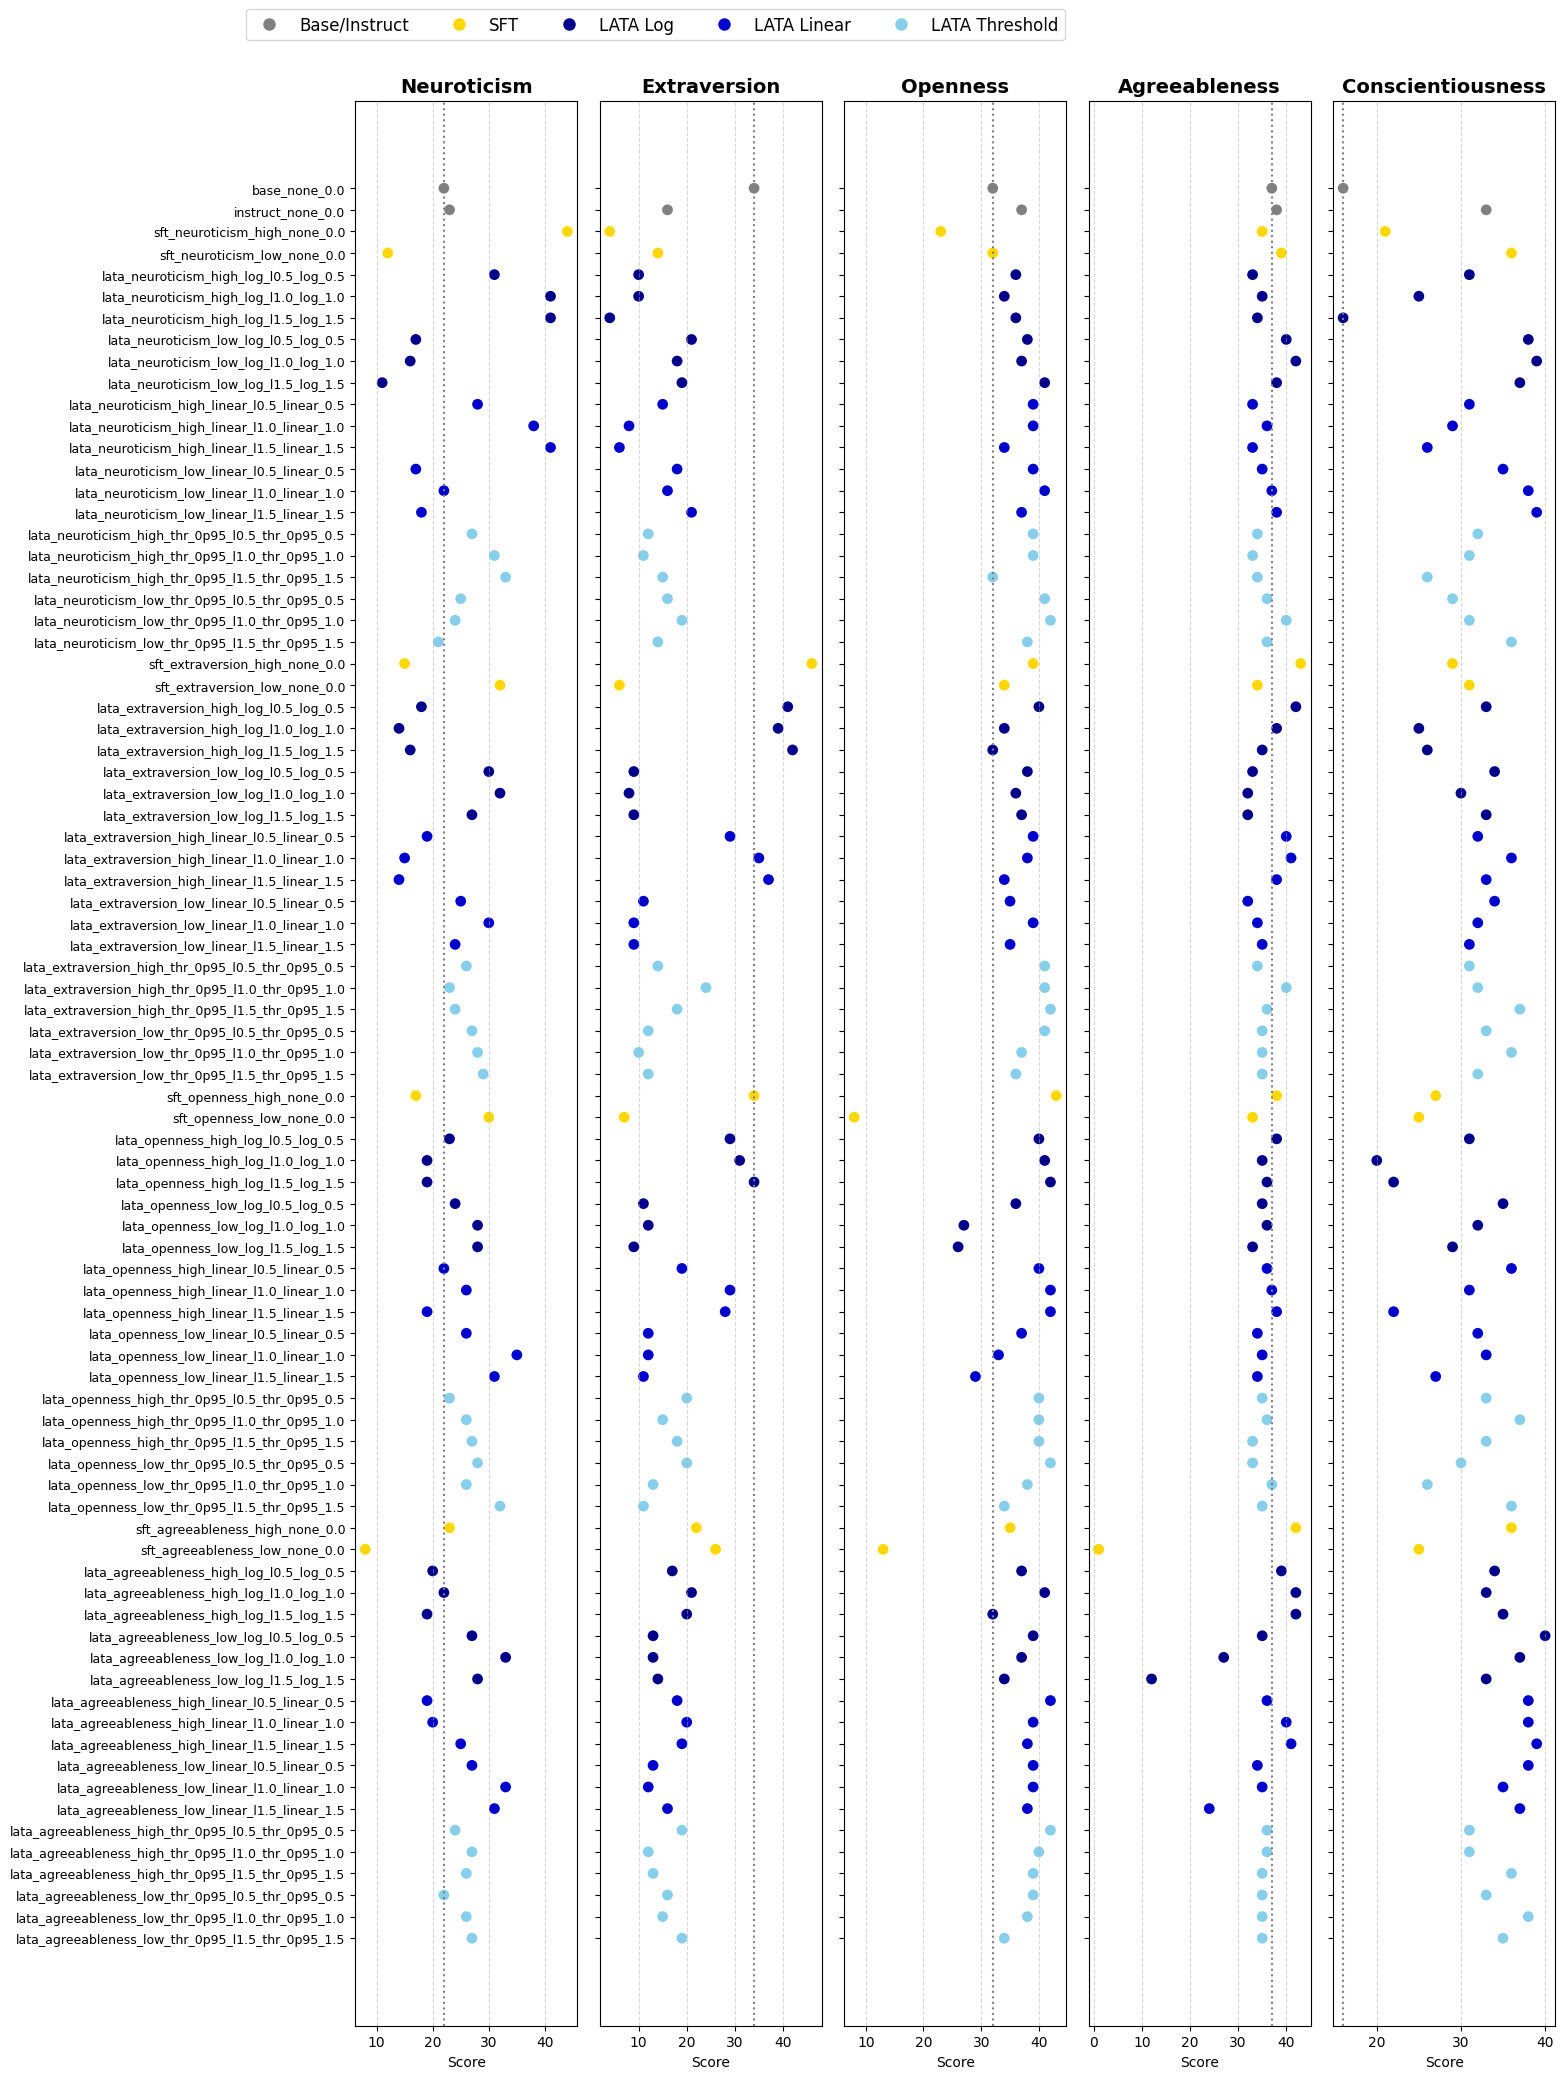

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 1. Load Data
df = pd.read_csv('Results_0802/sst_qwen3_235B_text_per_question_scores.csv')

# 2. Logic for Sorting and Grouping
# We define a custom sort key to group models logically on the Y-axis:
# Order: Controls (Base/Instruct) -> Neuroticism Models -> Extraversion -> Openness -> Agreeableness -> Conscientiousness
traits_order = ['neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness']
trait_map = {t: i for i, t in enumerate(traits_order)}

def get_sort_key(name):
    if name == 'subject': return (99, 99, name) # Skip header
    # 1. Primary Group (Trait or Control)
    if name.startswith('base') or name.startswith('instruct'):
        primary = -1 
    else:
        parts = name.split('_')
        target = parts[1].lower() if len(parts) > 1 else 'z_other'
        primary = trait_map.get(target, 99)
        
    # 2. Method Group (for secondary sorting)
    if 'sft' in name: sec = 0
    elif 'log' in name: sec = 1
    elif 'linear' in name: sec = 2
    elif 'thr' in name: sec = 3
    else: sec = 4
    
    return (primary, sec, name)

# Apply Sorting
# Sort Ascending=False puts the largest values (Conscientiousness) at the top of the DataFrame index 0?
# Actually, let's sort so Base (-1) is at the top. 
# In a plot, Y=0 is bottom. So we want Base to have the highest index if we plot index on Y.
# Let's sort Descending (Consc -> Base). 
# Then plotting row i at y=i puts Base (last) at Top? No, Base (last) is at bottom y=0?
# Let's just sort it and reverse if needed.
df['sort_key'] = df.iloc[:, 0].apply(get_sort_key)
df_sorted = df.sort_values(by='sort_key', ascending=False) # Groups: Consc -> ... -> Base
df_sorted = df_sorted[df_sorted.iloc[:,0] != 'subject'] # Remove header row

# 3. Setup Plot
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 25), sharey=True)
colors_map = {
    'Control': 'grey', 'SFT': '#FFD700', 
    'LATA Log': 'darkblue', 'LATA Linear': 'mediumblue', 'LATA Threshold': 'skyblue'
}

# Helper to get color
def get_color(name):
    if name.startswith('base') or name.startswith('instruct'): return colors_map['Control']
    if 'sft' in name: return colors_map['SFT']
    if 'log' in name: return colors_map['LATA Log']
    if 'linear' in name: return colors_map['LATA Linear']
    if 'thr' in name: return colors_map['LATA Threshold']
    return 'black'

y_labels = df_sorted.iloc[:, 0].values
y_pos = range(len(df_sorted))
model_colors = [get_color(n) for n in y_labels]

# 4. Generate Subplots
for i, trait in enumerate(traits_order):
    ax = axes[i]
    scores = df_sorted[trait].astype(float).values
    
    ax.scatter(scores, y_pos, c=model_colors, s=60, alpha=1.0, edgecolors='none')
    
    ax.set_title(trait.capitalize(), fontsize=14, fontweight='bold')
    ax.set_xlabel('Score')
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)
    
    # Reference Line (Base Model Score)
    base_val = df[df.iloc[:,0] == 'base_none_0.0'][trait].astype(float).values
    if len(base_val) > 0:
        ax.axvline(x=base_val[0], color='grey', linestyle=':', linewidth=1.5)

# Formatting
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(y_labels, fontsize=9)
plt.subplots_adjust(left=0.35, right=0.95, wspace=0.1) # Extra margin for names

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Base/Instruct', markerfacecolor='grey', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='SFT', markerfacecolor='#FFD700', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='LATA Log', markerfacecolor='darkblue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='LATA Linear', markerfacecolor='mediumblue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='LATA Threshold', markerfacecolor='skyblue', markersize=10)
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.92), ncol=5, fontsize=12)

plt.savefig('forest_plot_full_names.png')

In [ ]:
path = 'Results_0802/sst_qwen3_235B_text_per_question_scores.csv'

df=pd.read_csv(path)
df.co

Index(['Unnamed: 0', 'subject', 'neuroticism', 'extraversion', 'openness',
       'agreeableness', 'conscientiousness'],
      dtype='str')

In [12]:
import pandas as pd
import itertools

# Load data
responses_df = pd.read_csv('Results_0802/sst_qwen3_235B_text_per_question_responses.csv')
scores_df = pd.read_csv('Results_0802/sst_qwen3_235B_text_per_question_scores.csv')

# Get Base model data
base_model_name = 'base_none_0.0'
base_responses = responses_df[responses_df.iloc[:,0] == base_model_name].iloc[0]
base_scores = scores_df[scores_df.iloc[:,0] == base_model_name].iloc[0]

# Define standard mapping (0-4)
# Check response values first
print("Unique responses:", base_responses.unique())

map_forward = {
    'Strongly Disagree': 0, 'Disagree': 1, 'Neutral': 2, 'Agree': 3, 'Strongly Agree': 4
}
map_reverse = {
    'Strongly Disagree': 4, 'Disagree': 3, 'Neutral': 2, 'Agree': 1, 'Strongly Agree': 0
}

# Traits and their standard item indices (1-based -> 0-based for python)
# NEO-FFI usually has 60 items, 12 per trait.
# N: 0, 5, 10...
# E: 1, 6, 11...
# O: 2, 7, 12...
# A: 3, 8, 13...
# C: 4, 9, 14...
traits = ['neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness']
trait_indices = {
    'neuroticism': [i for i in range(0, 60, 5)],
    'extraversion': [i for i in range(1, 60, 5)],
    'openness': [i for i in range(2, 60, 5)],
    'agreeableness': [i for i in range(3, 60, 5)],
    'conscientiousness': [i for i in range(4, 60, 5)]
}

inferred_key = {}

for trait in traits:
    target_score = base_scores[trait]
    indices = trait_indices[trait]
    
    # Get response strings for these items
    # The columns are question_1 ... question_60.
    # index 0 -> question_1
    item_responses = [base_responses[f'question_{i+1}'] for i in indices]
    
    # Try to find the reverse coding pattern
    # We need to determine for each of the 12 items if it is Forward or Reverse
    # brute force 2^12 is okay
    
    found = False
    for pattern in itertools.product([0, 1], repeat=12):
        # 0 = Forward, 1 = Reverse
        current_sum = 0
        for i, is_reverse in enumerate(pattern):
            resp_str = item_responses[i]
            if is_reverse:
                val = map_reverse.get(resp_str, 2) # default to neutral if missing
            else:
                val = map_forward.get(resp_str, 2)
            current_sum += val
            
        if current_sum == target_score:
            inferred_key[trait] = pattern
            found = True
            break
            
    if not found:
        print(f"Could not infer key for {trait}. Target: {target_score}")
    else:
        print(f"Inferred key for {trait}: {inferred_key[trait]}")

print("Inference Complete")

Unique responses: <StringArray>
[    'base_none_0.0', 'Strongly Disagree',           'Neutral',
          'Disagree',             'Agree',    'Strongly Agree']
Length: 6, dtype: str
Inferred key for neuroticism: (0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0)
Inferred key for extraversion: (0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)
Inferred key for openness: (0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0)
Inferred key for agreeableness: (0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1)
Inferred key for conscientiousness: (0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0)
Inference Complete


In [13]:
# Refine key inference with multiple models
models_to_check = ['base_none_0.0', 'instruct_none_0.0', 'sft_neuroticism_high_none_0.0', 'sft_extraversion_high_none_0.0']
# Ensure these models exist in both DFs
common_models = list(set(models_to_check) & set(responses_df.iloc[:,0]) & set(scores_df.iloc[:,0]))

refined_key = {}

for trait in traits:
    indices = trait_indices[trait]
    
    # Candidate patterns: initially all 2^12
    # We filter them down model by model
    # To save memory, we can just process the first model to get candidates, then filter
    
    # Get first model data
    m1 = common_models[0]
    resp1 = responses_df[responses_df.iloc[:,0] == m1].iloc[0]
    score1 = scores_df[scores_df.iloc[:,0] == m1].iloc[0][trait]
    
    candidates = []
    
    # 1. Generate initial candidates from first model
    resps_m1 = [resp1[f'question_{i+1}'] for i in indices]
    
    for pattern in itertools.product([0, 1], repeat=12):
        s = 0
        for i, is_rev in enumerate(pattern):
            val = map_reverse[resps_m1[i]] if is_rev else map_forward[resps_m1[i]]
            s += val
        if s == score1:
            candidates.append(pattern)
            
    print(f"{trait}: Initial candidates from {m1}: {len(candidates)}")
    
    # 2. Filter with subsequent models
    for m in common_models[1:]:
        if not candidates: break
        
        resp_m = responses_df[responses_df.iloc[:,0] == m].iloc[0]
        score_m = scores_df[scores_df.iloc[:,0] == m].iloc[0][trait]
        resps = [resp_m[f'question_{i+1}'] for i in indices]
        
        new_candidates = []
        for pat in candidates:
            s = 0
            for i, is_rev in enumerate(pat):
                val = map_reverse[resps[i]] if is_rev else map_forward[resps[i]]
                s += val
            if s == score_m:
                new_candidates.append(pat)
        candidates = new_candidates
        print(f"  After {m}: {len(candidates)} candidates")
        
    if len(candidates) == 1:
        refined_key[trait] = candidates[0]
    elif len(candidates) > 1:
        print(f"Warning: Multiple keys found for {trait}. Using first.")
        refined_key[trait] = candidates[0]
    else:
        print(f"Error: No consistent key found for {trait}.")

print("Final Key:", refined_key)

neuroticism: Initial candidates from sft_extraversion_high_none_0.0: 126
  After base_none_0.0: 22 candidates
  After sft_neuroticism_high_none_0.0: 1 candidates
  After instruct_none_0.0: 1 candidates
extraversion: Initial candidates from sft_extraversion_high_none_0.0: 1
  After base_none_0.0: 1 candidates
  After sft_neuroticism_high_none_0.0: 1 candidates
  After instruct_none_0.0: 1 candidates
openness: Initial candidates from sft_extraversion_high_none_0.0: 7
  After base_none_0.0: 2 candidates
  After sft_neuroticism_high_none_0.0: 1 candidates
  After instruct_none_0.0: 1 candidates
agreeableness: Initial candidates from sft_extraversion_high_none_0.0: 1
  After base_none_0.0: 1 candidates
  After sft_neuroticism_high_none_0.0: 1 candidates
  After instruct_none_0.0: 1 candidates
conscientiousness: Initial candidates from sft_extraversion_high_none_0.0: 288
  After base_none_0.0: 4 candidates
  After sft_neuroticism_high_none_0.0: 2 candidates
  After instruct_none_0.0: 2 candi

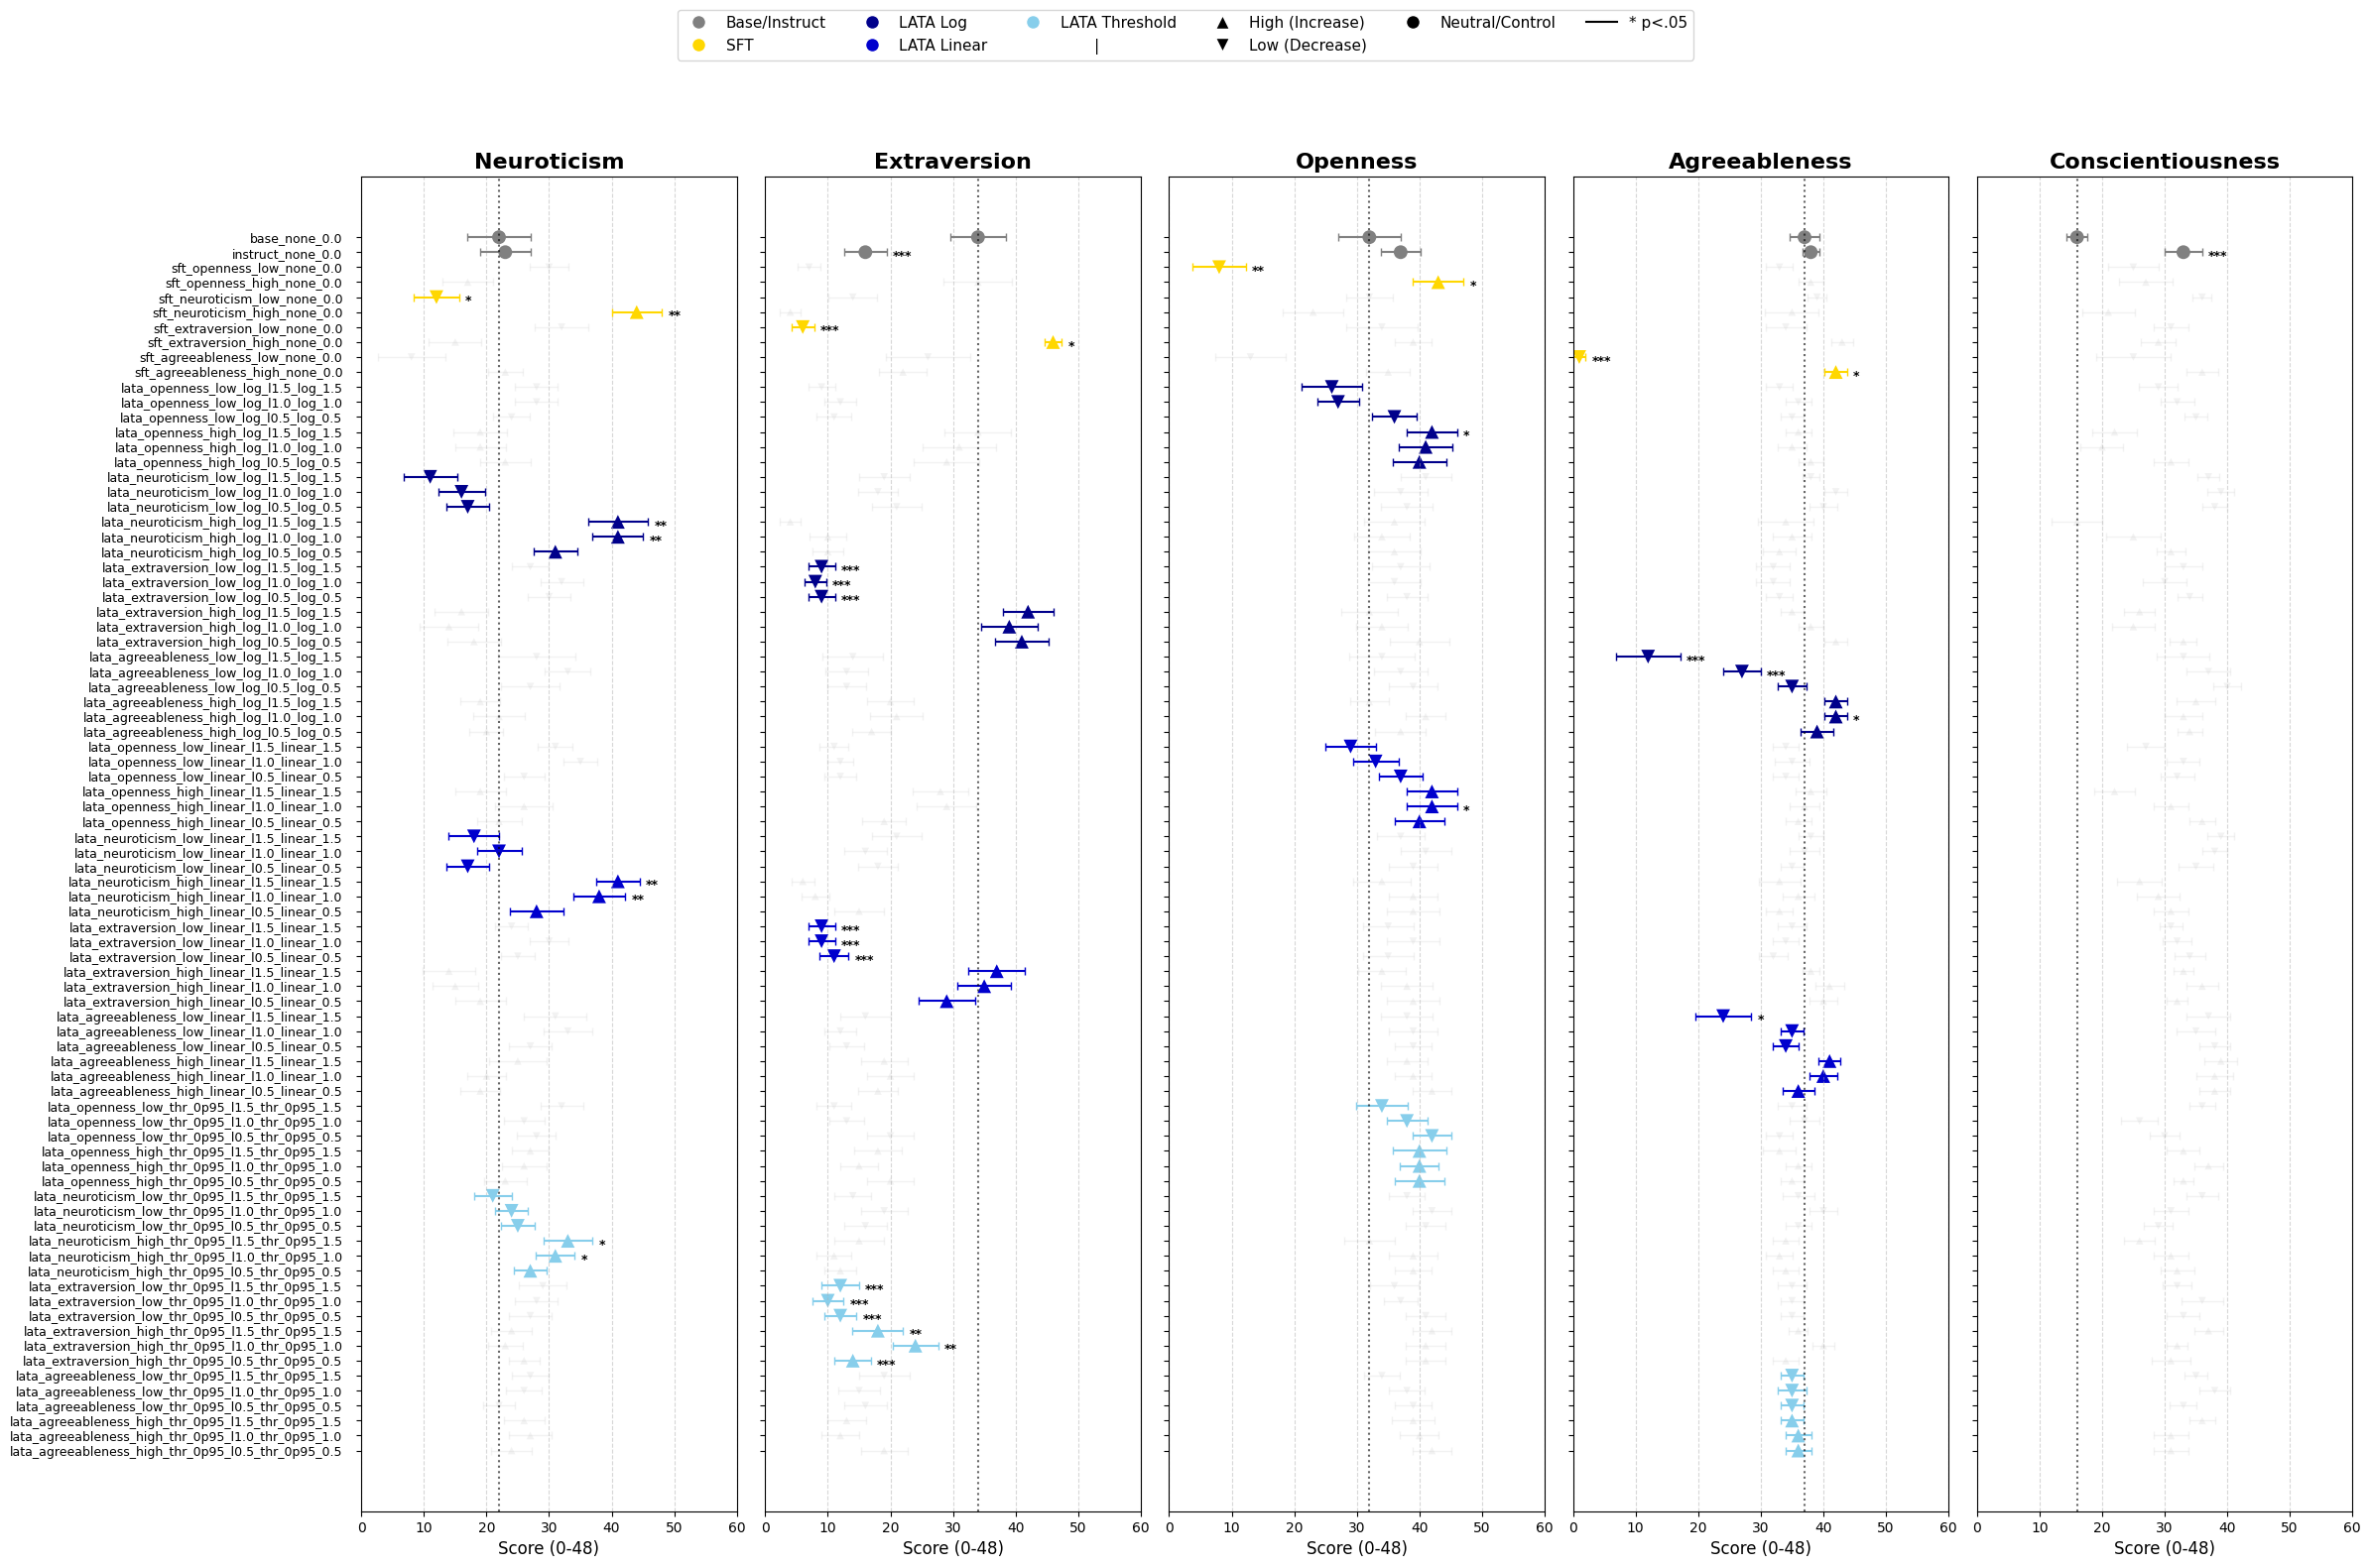

In [16]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 1. Load Data & Prepare Keys (Assumed loaded from previous steps)
# refined_key, map_forward, map_reverse, trait_indices are assumed to exist
# If starting fresh, ensure you run the key inference step from the previous turn first.

# 2. Calculate Stats, Significance, and Assign Markers
model_stats = []
base_row = responses_df[responses_df.iloc[:,0] == 'base_none_0.0'].iloc[0]
base_item_scores = {t: get_trait_item_scores(base_row, t, refined_key[t]) for t in traits}

for idx, row in responses_df.iterrows():
    model_name = row.iloc[0]
    if model_name == 'subject': continue
    
    for trait in traits:
        item_scores = get_trait_item_scores(row, trait, refined_key[trait])
        mean_score = np.sum(item_scores)
        sd = np.std(item_scores, ddof=1)
        se_total = (sd / np.sqrt(len(item_scores))) * 12
        
        # Significance
        if np.allclose(item_scores, base_item_scores[trait]):
            p_val = 1.0
        else:
            _, p_val = stats.ttest_rel(item_scores, base_item_scores[trait])
            
        # Highlight Logic
        is_highlight = False
        if model_name.startswith('base') or model_name.startswith('instruct'):
            is_highlight = True
        elif trait in model_name: 
            is_highlight = True
            
        # Marker Logic (High vs Low)
        if 'high' in model_name:
            marker = '^' # Up Triangle
        elif 'low' in model_name:
            marker = 'v' # Down Triangle
        else:
            marker = 'o' # Circle (Base/Instruct)

        model_stats.append({
            'Model': model_name, 'Trait': trait, 'Score': mean_score, 
            'Error': se_total, 'P_Val': p_val, 'Highlight': is_highlight,
            'Marker': marker, 'Color_Cat': get_model_type_color(model_name)
        })

stats_df = pd.DataFrame(model_stats)

# 3. Plotting
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(24, 16), sharey=True)

# Sort Models (Same as before: Base at Top)
def master_sort(name):
    score = 0
    if name.startswith('base'): score += 1000
    elif name.startswith('instruct'): score += 900
    elif 'sft' in name: score += 800
    elif 'log' in name: score += 700
    elif 'linear' in name: score += 600
    elif 'thr' in name: score += 500
    return (score, name)

unique_models = stats_df['Model'].unique()
sorted_models = sorted(unique_models, key=master_sort) # Ascending
model_map = {m: i for i, m in enumerate(sorted_models)}

palette = {
    'Base': 'grey', 'Instruct': 'grey',
    'SFT': '#FFD700', 
    'LATA Log': 'darkblue', 'LATA Linear': 'mediumblue', 'LATA Threshold': 'skyblue',
    'Other': 'lightgrey'
}

for i, trait in enumerate(traits):
    ax = axes[i]
    subset = stats_df[stats_df['Trait'] == trait]
    
    for _, row in subset.iterrows():
        y = model_map[row['Model']]
        x = row['Score']
        err = row['Error']
        p_val = row['P_Val']
        is_hlt = row['Highlight']
        marker = row['Marker']
        
        # Style logic
        if is_hlt:
            color = palette[row['Color_Cat']]
            alpha = 1.0
            size = 100 # Slightly larger for shape visibility
            lw = 1.5
            sig_txt = ''
            if p_val < 0.001: sig_txt = '***'
            elif p_val < 0.01: sig_txt = '**'
            elif p_val < 0.05: sig_txt = '*'
        else:
            color = 'silver'
            alpha = 0.2
            size = 30
            lw = 1.0
            sig_txt = ''
            
        # Plot Error Bar
        ax.errorbar(x, y, xerr=err, fmt='none', ecolor=color, alpha=alpha, elinewidth=lw, capsize=3)
        
        # Plot Symbol
        ax.scatter(x, y, marker=marker, c=color, s=size, alpha=alpha, edgecolors='none')
        
        # Plot Significance
        if sig_txt:
            ax.text(x + err + 1.0, y - 0.25, sig_txt, fontsize=9, color='black', fontweight='bold', va='center')

    # Formatting
    ax.set_title(trait.capitalize(), fontsize=16, fontweight='bold')
    ax.set_xlabel('Score (0-48)', fontsize=12)
    ax.set_xlim(0, 60)
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)
    
    # Base Reference
    base_score = subset[subset['Model'] == 'base_none_0.0']['Score'].values[0]
    ax.axvline(x=base_score, color='black', linestyle=':', alpha=0.6, linewidth=1.5)

# Axis Labels
axes[0].set_yticks(range(len(sorted_models)))
axes[0].set_yticklabels(sorted_models, fontsize=9)
axes[0].tick_params(axis='y', pad=10)

plt.tight_layout()
plt.subplots_adjust(top=0.88)

# Custom Legend with Symbols
legend_elements = [
    # Colors
    Line2D([0], [0], marker='o', color='w', label='Base/Instruct', markerfacecolor='grey', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='SFT', markerfacecolor='#FFD700', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='LATA Log', markerfacecolor='darkblue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='LATA Linear', markerfacecolor='mediumblue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='LATA Threshold', markerfacecolor='skyblue', markersize=10),
    # Spacing
    Line2D([0], [0], marker='', color='w', label='       |       ', markersize=0),
    # Symbols
    Line2D([0], [0], marker='^', color='w', label='High (Increase)', markerfacecolor='black', markersize=10),
    Line2D([0], [0], marker='v', color='w', label='Low (Decrease)', markerfacecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Neutral/Control', markerfacecolor='black', markersize=10),
    # Significance
    Line2D([0], [0], marker='', color='black', label='* p<.05', markersize=0)
]

fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.99), ncol=6, fontsize=11)

plt.savefig('forest_plot_symbols.png')
plt.show()

# Multi trait 

N - high 
E - Low

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D

# # 1. Load Data
# df = pd.read_csv('Results_exp/addition/sst_gpt_5_mini_text_per_question_responses.csv')

# # 2. Logic for Sorting and Grouping
# # We define a custom sort key to group models logically on the Y-axis:
# # Order: Controls (Base/Instruct) -> Neuroticism Models -> Extraversion -> Openness -> Agreeableness -> Conscientiousness
# traits_order = ['neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness']
# trait_map = {t: i for i, t in enumerate(traits_order)}

# def get_sort_key(name):
#     if name == 'subject': return (99, 99, name) # Skip header
#     # 1. Primary Group (Trait or Control)
#     if name.startswith('base') or name.startswith('instruct'):
#         primary = -1 
#     else:
#         parts = name.split('_')
#         target = parts[1].lower() if len(parts) > 1 else 'z_other'
#         primary = trait_map.get(target, 99)
        
#     # 2. Method Group (for secondary sorting)
#     if 'sft' in name: sec = 0
#     elif 'log' in name: sec = 1
#     elif 'linear' in name: sec = 2
#     elif 'thr' in name: sec = 3
#     else: sec = 4
    
#     return (primary, sec, name)

# # Apply Sorting
# # Sort Ascending=False puts the largest values (Conscientiousness) at the top of the DataFrame index 0?
# # Actually, let's sort so Base (-1) is at the top. 
# # In a plot, Y=0 is bottom. So we want Base to have the highest index if we plot index on Y.
# # Let's sort Descending (Consc -> Base). 
# # Then plotting row i at y=i puts Base (last) at Top? No, Base (last) is at bottom y=0?
# # Let's just sort it and reverse if needed.
# df['sort_key'] = df.iloc[:, 0].apply(get_sort_key)
# df_sorted = df.sort_values(by='sort_key', ascending=False) # Groups: Consc -> ... -> Base
# df_sorted = df_sorted[df_sorted.iloc[:,0] != 'subject'] # Remove header row

# # 3. Setup Plot
# fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 25), sharey=True)
# colors_map = {
#     'Control': 'grey', 'SFT': '#FFD700', 
#     'LATA Log': 'darkblue', 'LATA Linear': 'mediumblue', 'LATA Threshold': 'skyblue'
# }

# # Helper to get color
# def get_color(name):
#     if name.startswith('base') or name.startswith('instruct'): return colors_map['Control']
#     if 'sft' in name: return colors_map['SFT']
#     if 'log' in name: return colors_map['LATA Log']
#     if 'linear' in name: return colors_map['LATA Linear']
#     if 'thr' in name: return colors_map['LATA Threshold']
#     return 'black'

# y_labels = df_sorted.iloc[:, 0].values
# y_pos = range(len(df_sorted))
# model_colors = [get_color(n) for n in y_labels]

# # 4. Generate Subplots
# for i, trait in enumerate(traits_order):
#     ax = axes[i]
#     scores = df_sorted[trait].astype(float).values
    
#     ax.scatter(scores, y_pos, c=model_colors, s=60, alpha=1.0, edgecolors='none')
    
#     ax.set_title(trait.capitalize(), fontsize=14, fontweight='bold')
#     ax.set_xlabel('Score')
#     ax.grid(True, axis='x', linestyle='--', alpha=0.5)
    
#     # Reference Line (Base Model Score)
#     base_val = df[df.iloc[:,0] == 'base_none_0.0'][trait].astype(float).values
#     if len(base_val) > 0:
#         ax.axvline(x=base_val[0], color='grey', linestyle=':', linewidth=1.5)

# # Formatting
# axes[0].set_yticks(y_pos)
# axes[0].set_yticklabels(y_labels, fontsize=9)
# plt.subplots_adjust(left=0.35, right=0.95, wspace=0.1) # Extra margin for names

# # Legend
# legend_elements = [
#     Line2D([0], [0], marker='o', color='w', label='Base/Instruct', markerfacecolor='grey', markersize=10),
#     Line2D([0], [0], marker='o', color='w', label='SFT', markerfacecolor='#FFD700', markersize=10),
#     Line2D([0], [0], marker='o', color='w', label='LATA Log', markerfacecolor='darkblue', markersize=10),
#     Line2D([0], [0], marker='o', color='w', label='LATA Linear', markerfacecolor='mediumblue', markersize=10),
#     Line2D([0], [0], marker='o', color='w', label='LATA Threshold', markerfacecolor='skyblue', markersize=10)
# ]
# fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.92), ncol=5, fontsize=12)

# plt.savefig('Results_exp/addition/forest_plot_full_names.png')

Saved: /Users/christophhau/Desktop/Masterarbeit/LATA/Results_exp/addition/sst_gpt_5_plot_exp1_two_dimensions.png


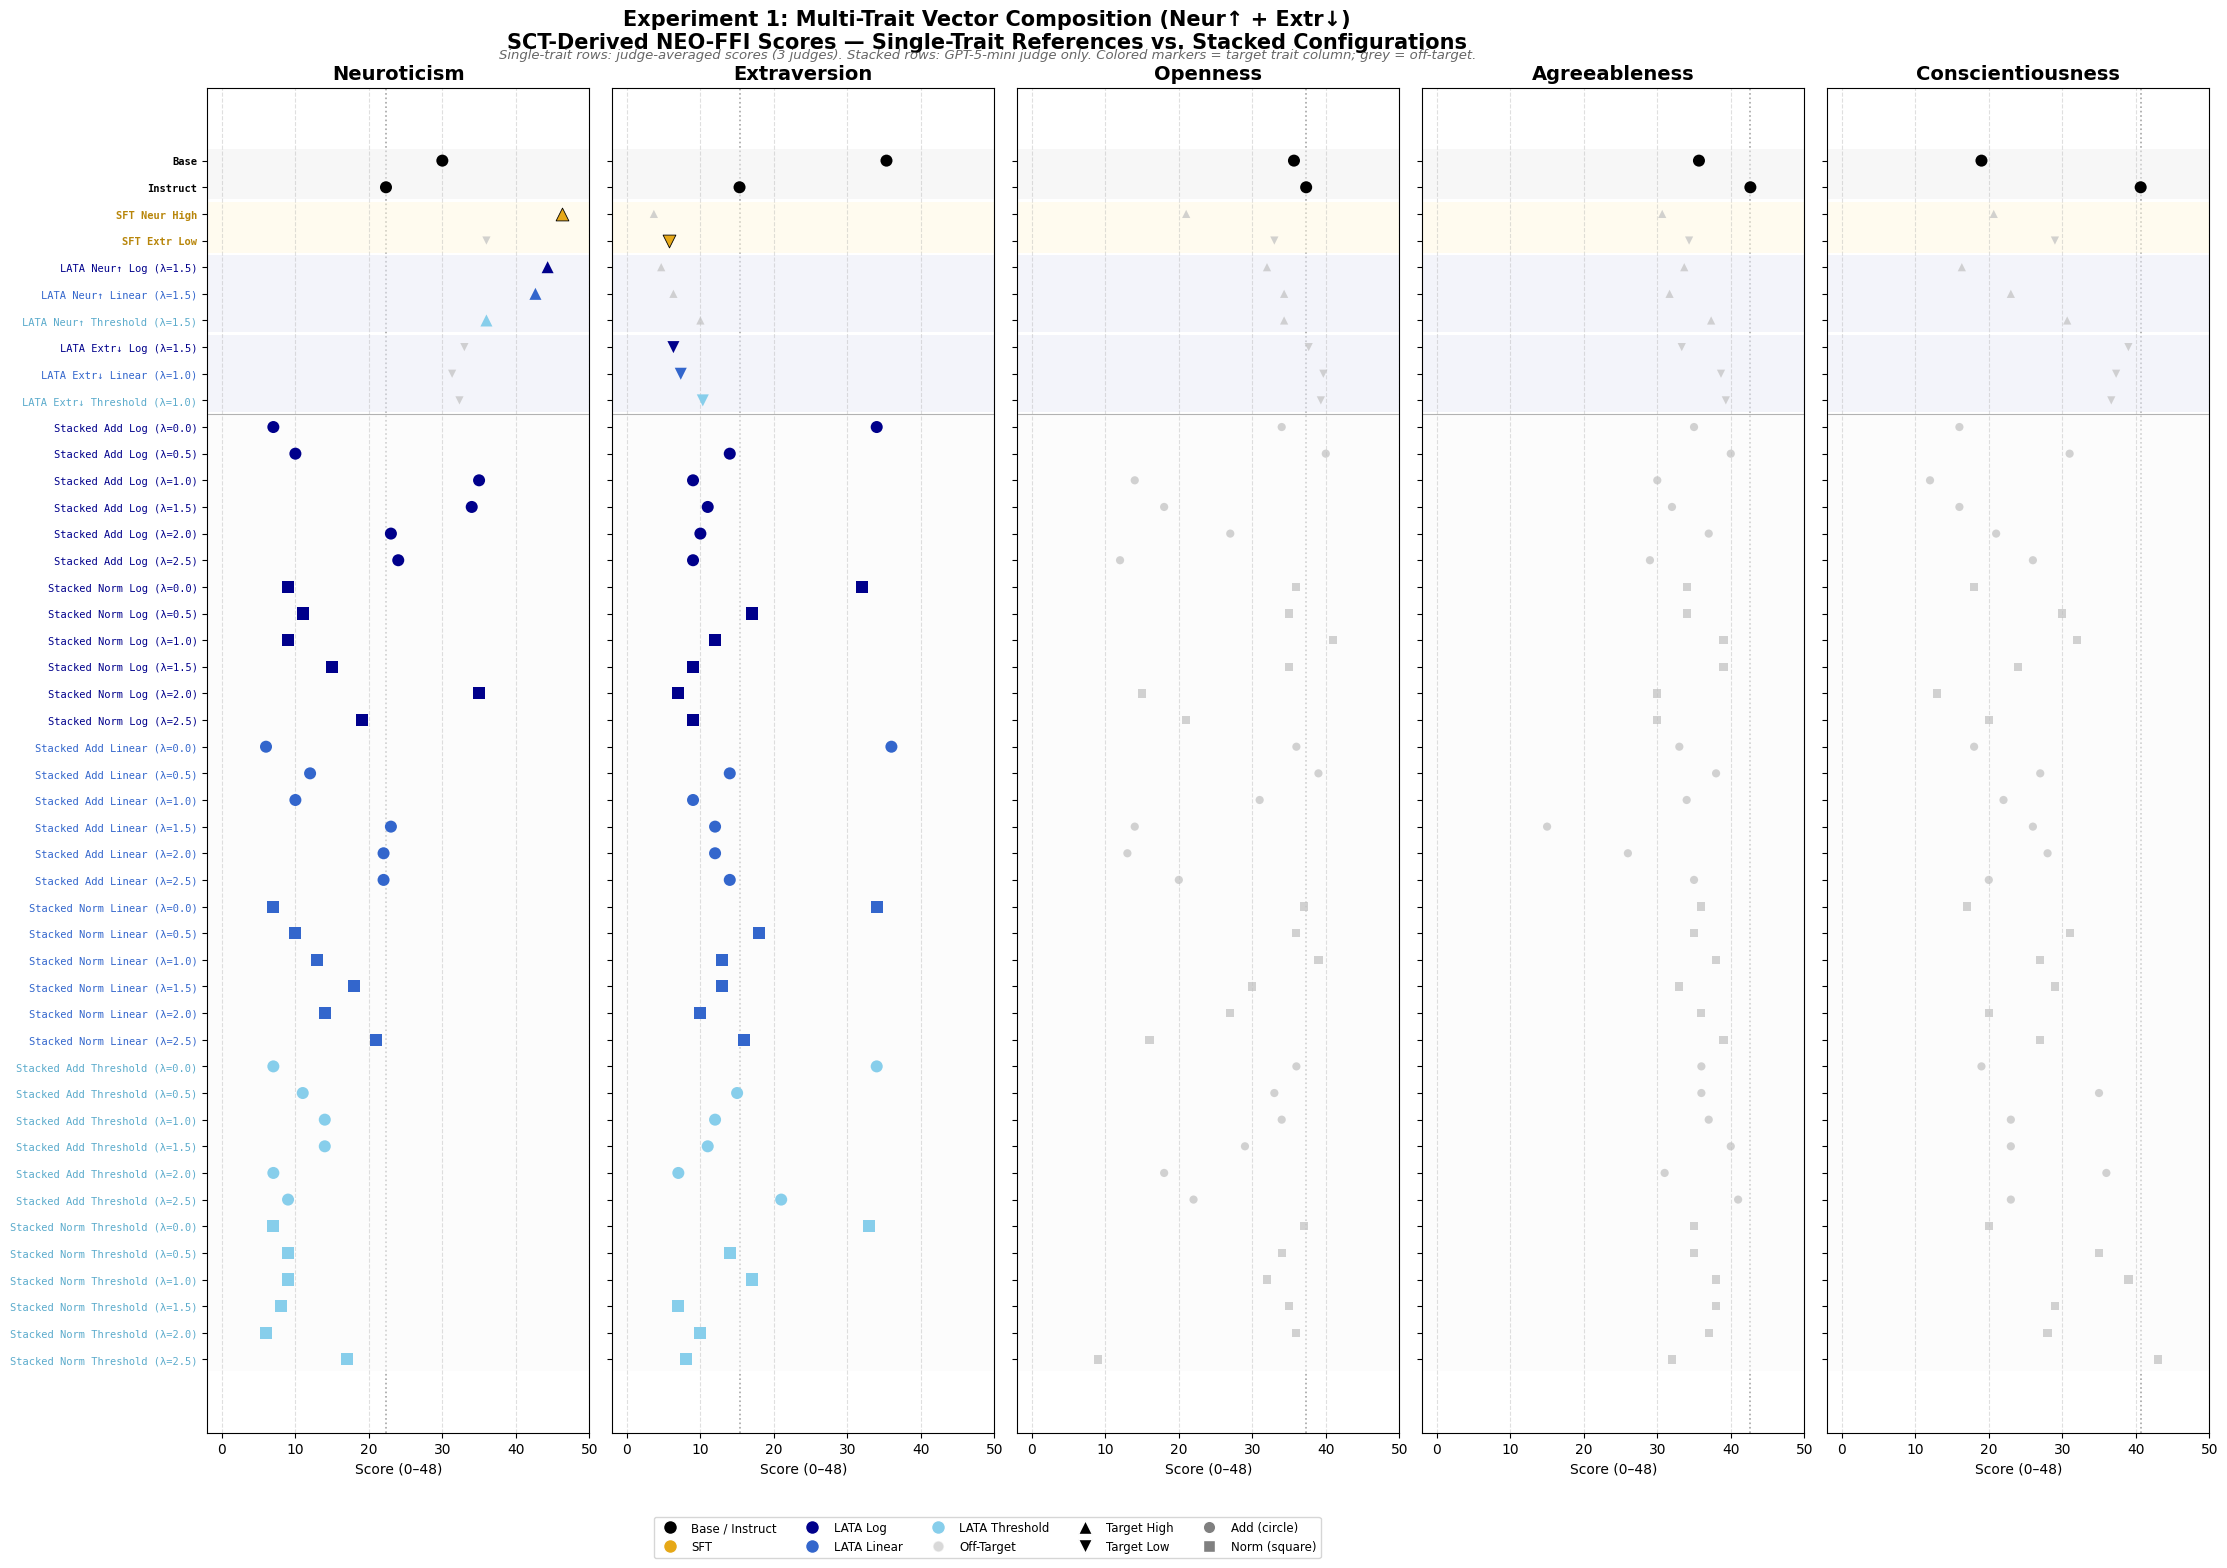

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import re

# ==========================================
# CONFIGURATION
# ==========================================
INPUT_CSV = "/Users/christophhau/Desktop/Masterarbeit/LATA/Results_exp/addition/sst_gpt_5_mini_text_per_question_scores.csv"
stacked = pd.read_csv(INPUT_CSV)

avg = pd.read_csv('/Users/christophhau/Desktop/Masterarbeit/LATA/Results_SCT/sst_average_judge_scores.csv')
OUTPUT_PNG = "/Users/christophhau/Desktop/Masterarbeit/LATA/Results_exp/addition/sst_gpt_5_plot_exp1_two_dimensions.png"


traits = ['neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness']

# ==========================================
# 2. BUILD THE ROW TABLE (ordered top-to-bottom as displayed)
#    Each row: label, scores dict, group, color_type, marker, target_traits
# ==========================================

rows = []

def add_row(label, scores, group, color_type, marker='o', target_traits=None):
    """target_traits: set of trait names that are 'on-target' for this model."""
    rows.append({
        'label': label,
        'scores': {t: scores[t] for t in traits},
        'group': group,
        'color_type': color_type,
        'marker': marker,
        'target_traits': target_traits or set(),
    })

def get_avg_row(model_pattern):
    """Get a row from the averaged judge CSV by partial match."""
    match = avg[avg['Model'].str.contains(model_pattern, regex=False)]
    if len(match) == 0:
        raise ValueError(f"No match for '{model_pattern}'")
    return match.iloc[0]

def get_stacked_row(model_pattern):
    """Get a row from the stacked CSV by partial match."""
    match = stacked[stacked['Model'].str.contains(model_pattern, regex=False)]
    if len(match) == 0:
        raise ValueError(f"No match for '{model_pattern}'")
    return match.iloc[0]

# ----- GROUP 1: BASELINES -----
r = get_avg_row('base_none')
add_row('Base', r, 'baseline', 'base', 'o', set())

r = get_avg_row('instruct_none')
add_row('Instruct', r, 'baseline', 'instruct', 'o', set())

# ----- GROUP 2: SFT (Neur high, Extr low) -----
r = get_avg_row('sft_neuroticism_high')
add_row('SFT Neur High', r, 'sft', 'sft', '^', {'neuroticism'})

r = get_avg_row('sft_extraversion_low')
add_row('SFT Extr Low', r, 'sft', 'sft', 'v', {'extraversion'})

# ----- GROUP 3: SINGLE-TRAIT LATA Neuroticism High (best λ per strategy) -----
r = get_avg_row('lata_neuroticism_high_log_l1.5')
add_row('LATA Neur↑ Log (λ=1.5)', r, 'lata_neur', 'log', '^', {'neuroticism'})

r = get_avg_row('lata_neuroticism_high_linear_l1.5')
add_row('LATA Neur↑ Linear (λ=1.5)', r, 'lata_neur', 'linear', '^', {'neuroticism'})

r = get_avg_row('lata_neuroticism_high_thr_0p95_l1.5')
add_row('LATA Neur↑ Threshold (λ=1.5)', r, 'lata_neur', 'threshold', '^', {'neuroticism'})

# ----- GROUP 4: SINGLE-TRAIT LATA Extraversion Low (best λ per strategy) -----
r = get_avg_row('lata_extraversion_low_log_l1.5')
add_row('LATA Extr↓ Log (λ=1.5)', r, 'lata_extr', 'log', 'v', {'extraversion'})

r = get_avg_row('lata_extraversion_low_linear_l1.0')
add_row('LATA Extr↓ Linear (λ=1.0)', r, 'lata_extr', 'linear', 'v', {'extraversion'})

r = get_avg_row('lata_extraversion_low_thr_0p95_l1.0')
add_row('LATA Extr↓ Threshold (λ=1.0)', r, 'lata_extr', 'threshold', 'v', {'extraversion'})

# ----- SEPARATOR -----
rows.append({'label': '___SEPARATOR___', 'scores': None, 'group': 'sep', 
             'color_type': None, 'marker': None, 'target_traits': None})

# ----- GROUP 5: STACKED (Neur↑ + Extr↓ combined) -----
# Order: log {add, norm} x lambdas, then linear, then threshold
stacked_target_traits = {'neuroticism', 'extraversion'}

def parse_stacked_model(model_name):
    """Parse stacked model name to get strategy, addition mode, lambda."""
    info = {}
    if '_log_' in model_name: info['strategy'] = 'log'
    elif '_linear_' in model_name: info['strategy'] = 'linear'
    elif '_TH_' in model_name: info['strategy'] = 'threshold'
    m = re.search(r'_L(\d+\.?\d*)_', model_name)
    info['lam'] = float(m.group(1)) if m else 0.0
    if '_Normalized_' in model_name: info['mode'] = 'norm'
    elif '_Addition_' in model_name: info['mode'] = 'add'
    return info

# Build structured list of stacked configs
stacked_configs = []
for _, sr in stacked.iterrows():
    model = sr['Model']
    if 'Base_Control' in model or 'Instruct_Baseline' in model:
        continue
    info = parse_stacked_model(model)
    stacked_configs.append({**info, 'model': model, 'scores': sr})

# Sort: strategy (log, linear, threshold) -> mode (add, norm) -> lambda
strat_ord = {'log': 0, 'linear': 1, 'threshold': 2}
mode_ord = {'add': 0, 'norm': 1}
stacked_configs.sort(key=lambda x: (strat_ord.get(x['strategy'], 9), 
                                      mode_ord.get(x['mode'], 9), 
                                      x['lam']))

strategy_names = {'log': 'Log', 'linear': 'Linear', 'threshold': 'Threshold'}
mode_names = {'add': 'Add', 'norm': 'Norm'}

for sc in stacked_configs:
    sname = strategy_names[sc['strategy']]
    mname = mode_names[sc['mode']]
    lam = sc['lam']
    label = f"Stacked {mname} {sname} (λ={lam:.1f})"
    
    color_type = sc['strategy']
    marker = 'o' if sc['mode'] == 'add' else 's'
    
    add_row(label, sc['scores'], 'stacked', color_type, marker, stacked_target_traits)

# ==========================================
# 3. COMPUTE Y-POSITIONS (bottom = 0, top = N)
# ==========================================
# Reverse rows so first entry appears at top
rows_display = rows[::-1]

y_positions = []
y_labels = []
separator_y = None
y = 0
for row in rows_display:
    if row['label'] == '___SEPARATOR___':
        separator_y = y - 0.5  # between previous and next
        continue
    y_positions.append(y)
    y_labels.append(row['label'])
    y += 1

# Also reverse the actual data rows (excluding separator)
data_rows = [r for r in rows_display if r['label'] != '___SEPARATOR___']

# ==========================================
# 4. COLOR & MARKER CONFIG
# ==========================================
palette = {
    'base': 'black',
    'instruct': 'black',
    'sft': '#E6A817',     # Gold
    'log': '#00008B',     # Dark blue
    'linear': '#3366CC',  # Medium blue
    'threshold': '#87CEEB', # Sky blue
}

# ==========================================
# 5. PLOT
# ==========================================
n_traits = len(traits)
fig_height = max(10, len(data_rows) * 0.34)
fig, axes = plt.subplots(nrows=1, ncols=n_traits, figsize=(26, fig_height), sharey=True)

fig.suptitle(
    'Experiment 1: Multi-Trait Vector Composition (Neur↑ + Extr↓)\n'
    'SCT-Derived NEO-FFI Scores — Single-Trait References vs. Stacked Configurations',
    fontsize=15, fontweight='bold', y=0.98
)
fig.text(
    0.5, 0.955,
    'Single-trait rows: judge-averaged scores (3 judges). '
    'Stacked rows: GPT-5-mini judge only. '
    'Colored markers = target trait column; grey = off-target.',
    ha='center', va='top', fontsize=9.5, style='italic', color='0.4'
)

for col_idx, trait in enumerate(traits):
    ax = axes[col_idx]
    
    # Get instruct baseline for vertical reference line
    instruct_row = [r for r in data_rows if r['color_type'] == 'instruct'][0]
    instruct_val = instruct_row['scores'][trait]
    ax.axvline(x=instruct_val, color='grey', linestyle=':', linewidth=1.2, alpha=0.7, zorder=0)
    
    for i, row in enumerate(data_rows):
        y = y_positions[i]
        x = row['scores'][trait]
        
        is_target = trait in row['target_traits']
        # Baselines are always colored
        is_baseline = row['color_type'] in ('base', 'instruct')
        
        if is_target or is_baseline:
            color = palette[row['color_type']]
            alpha = 1.0
            size = 85 if row['color_type'] == 'sft' else 75
            edge = 'black' if row['color_type'] == 'sft' else 'none'
            ew = 0.6 if row['color_type'] == 'sft' else 0
        else:
            color = 'silver'
            alpha = 0.7
            size = 35
            edge = 'none'
            ew = 0
        
        ax.scatter(x, y, c=color, marker=row['marker'], s=size,
                   alpha=alpha, zorder=3, edgecolors=edge, linewidths=ew)
    
    # Horizontal separator line
    if separator_y is not None:
        ax.axhline(y=separator_y, color='grey', linewidth=0.8, linestyle='-', alpha=0.6, zorder=1)
    
    ax.set_title(trait.capitalize(), fontsize=14, fontweight='bold')
    ax.set_xlabel('Score (0–48)', fontsize=10)
    ax.set_xlim(-2, 50)
    ax.grid(True, axis='x', linestyle='--', alpha=0.4, zorder=0)

# Y-axis labels with color-coding
axes[0].set_yticks(y_positions)
axes[0].set_yticklabels(y_labels, fontsize=7.5, fontfamily='monospace')

# Color the y-tick labels by group
for i, row in enumerate(data_rows):
    tick = axes[0].get_yticklabels()[i]
    ct = row['color_type']
    if ct in ('base', 'instruct'):
        tick.set_color('black')
        tick.set_fontweight('bold')
    elif ct == 'sft':
        tick.set_color('#B8860B')
        tick.set_fontweight('bold')
    elif ct == 'log':
        tick.set_color('#00008B')
    elif ct == 'linear':
        tick.set_color('#3366CC')
    elif ct == 'threshold':
        tick.set_color('#5BABCC')

# --- Group background shading ---
group_ranges = {}
for i, row in enumerate(data_rows):
    g = row['group']
    if g not in group_ranges:
        group_ranges[g] = [y_positions[i], y_positions[i]]
    else:
        group_ranges[g][0] = min(group_ranges[g][0], y_positions[i])
        group_ranges[g][1] = max(group_ranges[g][1], y_positions[i])

# Alternate light background shading for groups
shade_colors = {
    'baseline': '#f0f0f0',
    'sft': '#fff8e1',
    'lata_neur': '#e8eaf6',
    'lata_extr': '#e8eaf6',
    'stacked': '#fafafa',
}

for col_idx in range(n_traits):
    ax = axes[col_idx]
    for group_name, (ymin, ymax) in group_ranges.items():
        if group_name == 'sep':
            continue
        sc = shade_colors.get(group_name, 'white')
        ax.axhspan(ymin - 0.45, ymax + 0.45, facecolor=sc, alpha=0.5, zorder=0)

# ==========================================
# 6. LEGEND
# ==========================================
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Base / Instruct',
           markerfacecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='SFT',
           markerfacecolor='#E6A817', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='LATA Log',
           markerfacecolor='#00008B', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='LATA Linear',
           markerfacecolor='#3366CC', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='LATA Threshold',
           markerfacecolor='#87CEEB', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Off-Target',
           markerfacecolor='silver', markersize=8, alpha=0.6),
    Line2D([0], [0], marker='^', color='w', label='Target High',
           markerfacecolor='black', markersize=10),
    Line2D([0], [0], marker='v', color='w', label='Target Low',
           markerfacecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Add (circle)',
           markerfacecolor='grey', markersize=9),
    Line2D([0], [0], marker='s', color='w', label='Norm (square)',
           markerfacecolor='grey', markersize=9),
]

fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.02),
           ncol=5, fontsize=8.5, frameon=True)

plt.subplots_adjust(left=0.20, right=0.97, top=0.93, bottom=0.07, wspace=0.06)

plt.savefig(OUTPUT_PNG, dpi=250, bbox_inches='tight')
print(f"Saved: {OUTPUT_PNG}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# ==========================================
# CONFIGURATION
# ==========================================
INPUT_CSV = "Results_exp/negation/sst_gpt_5_mini_text_per_question_responses.csv"
OUTPUT_PNG = "Results_exp/negation/forest_plot_exp2_cancellation.png"

# Nullification band: shade the ±threshold region around 50%
NULLIFICATION_THRESHOLD = 10.0

# ==========================================
# 1. Load Data
# ==========================================
df = pd.read_csv(INPUT_CSV)
df.columns = df.columns.str.strip()
print(df.columns.tolist()) 

# All traits we evaluate
personality_arr = [
    "Agreeableness", "Conscientiousness", "Extraversion",
    "Neuroticism", "Openness"
]

# ==========================================
# 2. Build Y-axis Label & Sort Key
# ==========================================

def short_trait(trait):
    abbrev = {
        'Agreeableness': 'Agre', 'Conscientiousness': 'Cons',
        'Extraversion': 'Extr', 'Neuroticism': 'Neur',
        'Openness': 'Open'
    }
    return abbrev.get(trait, trait[:4])

def make_label(row):
    t = short_trait(row['Cancelled_Trait'])
    return f"{t}↑↓ | {row['Strategy']} | L{row['Lambda']} | {row['Addition_Mode']}"

model_info = df.drop_duplicates(subset='Model').copy()
model_info['Label'] = model_info.apply(make_label, axis=1)

# Sort: strategy -> addition -> lambda
strategy_order = {'linear': 0, 'log': 1, 'threshold': 2}
addition_order = {'add': 0, 'norm': 1}

def parse_lambda(val):
    try:
        return float(val)
    except (ValueError, TypeError):
        return 0.0

model_info['strat_ord'] = model_info['Strategy'].map(strategy_order).fillna(99)
model_info['add_ord'] = model_info['Addition_Mode'].map(addition_order).fillna(99)
model_info['lam_num'] = model_info['Lambda'].apply(parse_lambda)

model_info = model_info.sort_values(
    by=['strat_ord', 'add_ord', 'lam_num'],
    ascending=[True, True, True]
).reset_index(drop=True)

ordered_models = model_info['Model'].tolist()[::-1]
ordered_labels = model_info['Label'].tolist()[::-1]
y_pos = list(range(len(ordered_models)))
model_to_y = {m: i for i, m in enumerate(ordered_models)}

# ==========================================
# 3. Color Mapping
# ==========================================
colors_map = {
    'log': 'darkblue',
    'linear': 'mediumblue',
    'threshold': 'skyblue',
}
marker_map = {
    'add': 'o',
    'norm': 's',
}

def get_color(model_name):
    row = model_info[model_info['Model'] == model_name]
    if row.empty:
        return 'black'
    return colors_map.get(row.iloc[0]['Strategy'], 'black')

def get_marker(model_name):
    row = model_info[model_info['Model'] == model_name]
    if row.empty:
        return 'o'
    return marker_map.get(row.iloc[0]['Addition_Mode'], 'o')

# ==========================================
# 4. Generate Forest Plot
# ==========================================
n_traits = len(personality_arr)
fig, axes = plt.subplots(nrows=1, ncols=n_traits, figsize=(28, max(8, len(ordered_models) * 0.4)), sharey=True)

fig.suptitle('Experiment 2: Same Dimension Stacked (High + Low) — Cancellation Test\nHigh Response % per Evaluated Trait (green band = nullification zone)',
             fontsize=16, fontweight='bold', y=0.98)

for col_idx, trait in enumerate(personality_arr):
    ax = axes[col_idx]
    trait_df = df[df['Evaluated_Trait'] == trait]

    # Draw nullification band around 50%
    ax.axvspan(50 - NULLIFICATION_THRESHOLD, 50 + NULLIFICATION_THRESHOLD,
               color='green', alpha=0.08, zorder=0)
    ax.axvline(x=50, color='green', linestyle='-', linewidth=1.5, alpha=0.5, zorder=1)

    for _, row in trait_df.iterrows():
        model = row['Model']
        if model not in model_to_y:
            continue
        y = model_to_y[model]
        x = row['High_Responses_Pct']
        color = get_color(model)
        marker = get_marker(model)

        is_cancelled = row['Is_Cancelled_Trait']
        edge = 'red' if is_cancelled else 'none'
        size = 90 if is_cancelled else 50

        ax.scatter(x, y, c=color, marker=marker, s=size,
                   edgecolors=edge, linewidths=1.5 if is_cancelled else 0, alpha=0.9, zorder=3)

    ax.set_title(trait, fontsize=11, fontweight='bold')
    ax.set_xlabel('High Response %', fontsize=9)
    ax.set_xlim(-5, 105)
    ax.grid(True, axis='x', linestyle='--', alpha=0.4)

# Y-axis labels
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(ordered_labels, fontsize=8, fontfamily='monospace')

# ==========================================
# 5. Legend
# ==========================================
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Log', markerfacecolor='darkblue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Linear', markerfacecolor='mediumblue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Threshold', markerfacecolor='skyblue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Add (circle)', markerfacecolor='grey', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Norm (square)', markerfacecolor='grey', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Cancelled Trait', markerfacecolor='white',
           markersize=10, markeredgecolor='red', markeredgewidth=2),
    Line2D([0], [0], color='green', linestyle='-', linewidth=2, alpha=0.5,
           label=f'Nullification Zone (±{NULLIFICATION_THRESHOLD:.0f}%)'),
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.94),
           ncol=4, fontsize=11, frameon=True)

plt.subplots_adjust(left=0.22, right=0.97, top=0.86, bottom=0.05, wspace=0.08)
plt.savefig(OUTPUT_PNG, dpi=200, bbox_inches='tight')
print(f"Saved: {OUTPUT_PNG}")
plt.show()

['Unnamed: 0', 'question_1', 'question_2', 'question_3', 'question_4', 'question_5', 'question_6', 'question_7', 'question_8', 'question_9', 'question_10', 'question_11', 'question_12', 'question_13', 'question_14', 'question_15', 'question_16', 'question_17', 'question_18', 'question_19', 'question_20', 'question_21', 'question_22', 'question_23', 'question_24', 'question_25', 'question_26', 'question_27', 'question_28', 'question_29', 'question_30', 'question_31', 'question_32', 'question_33', 'question_34', 'question_35', 'question_36', 'question_37', 'question_38', 'question_39', 'question_40', 'question_41', 'question_42', 'question_43', 'question_44', 'question_45', 'question_46', 'question_47', 'question_48', 'question_49', 'question_50', 'question_51', 'question_52', 'question_53', 'question_54', 'question_55', 'question_56', 'question_57', 'question_58', 'question_59', 'question_60', 'subject']


KeyError: Index(['Model'], dtype='str')

# Final SQ 

In [ ]:
path_fp = '/Users/christophhau/Desktop/Masterarbeit/LATA/final_profiles_all.csv'

df = pd.read_csv(path_fp)
import os

OUTPUT_DIR = "/Users/christophhau/Desktop/Masterarbeit/LATA/Results_sq"
os.makedirs(OUTPUT_DIR, exist_ok=True)

=== BASELINES ===
model_name  Extraversion  Neuroticism  Agreeableness  Conscientiousness  Openness
      Base      2.863095     3.269841          3.075           3.097222  2.966667
  Instruct      2.966667     3.000000          3.200           3.266667  3.266667

=== SFT: 10 models ===
trait_targeted     level
Agreeableness      high     1
                   low      1
Conscientiousness  high     1
                   low      1
Extraversion       high     1
                   low      1
Neuroticism        high     1
                   low      1
Openness           high     1
                   low      1
Name: count, dtype: int64

=== LatA: 150 models ===
  Traits: ['Agreeableness', 'Conscientiousness', 'Extraversion', 'Neuroticism', 'Openness']
  Levels: ['high', 'low']
  Methods: ['Linear', 'Log', 'Threshold']
  Lambdas: [np.float64(0.0), np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5)]

=== TOTAL: 162 models ===
  Baselines: 2
  SFT:       10
  L

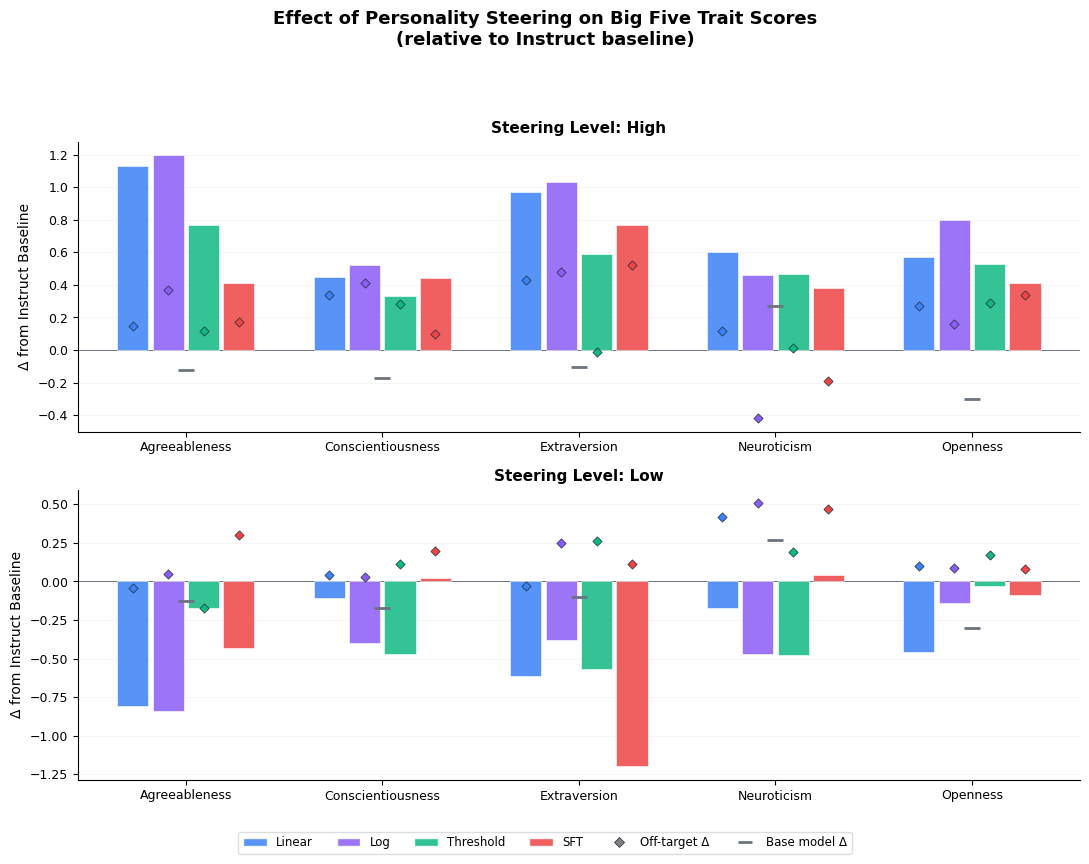

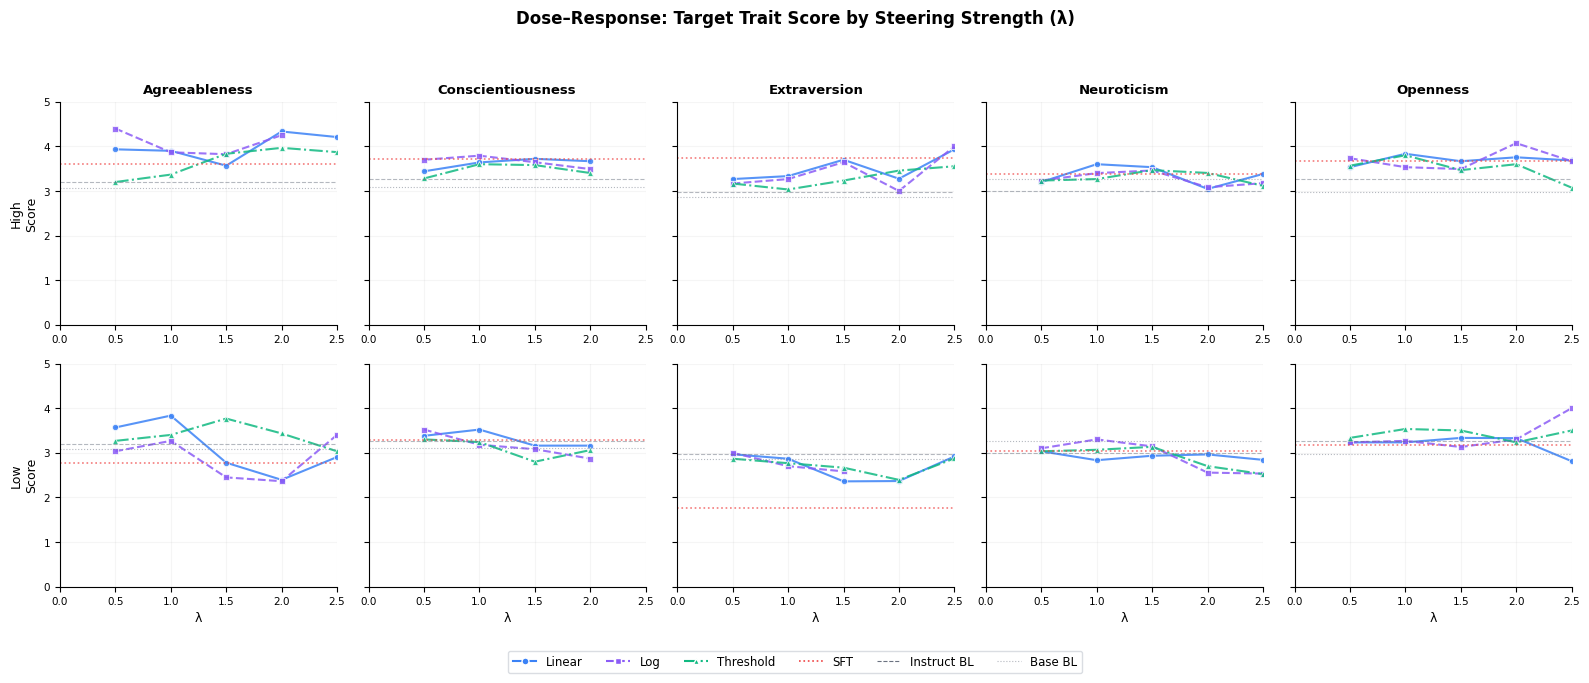

In [10]:
"""
Analysis of Big Five personality steering results.

Data structure (162 models total):
  - 2 Baselines: meta-llama/Llama-3.1-8B (base), meta-llama/Llama-3.1-8B-Instruct (instruct)
  - 10 SFT: 5 traits × 2 levels (high/low)
  - 150 LatA: 5 traits × 2 levels × 3 strategies (linear/log/threshold) × 5 lambda values

Outputs:
  - APA-style LaTeX table (booktabs)
  - Figure 1: Bar chart comparing methods (target Δ + off-target Δ)
  - Figure 2: Dose-response curves across lambda values
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker
import warnings
import shutil

warnings.filterwarnings('ignore')

# =============================================================================
# 1. LOAD DATA
# =============================================================================
BIG5 = ['Extraversion', 'Neuroticism', 'Agreeableness', 'Conscientiousness', 'Openness']
TRAITS_ORDER = ['Agreeableness', 'Conscientiousness', 'Extraversion', 'Neuroticism', 'Openness']

TRAIT_MAP = {
    'agreeableness': 'Agreeableness', 'conscientiousness': 'Conscientiousness',
    'extraversion': 'Extraversion', 'neuroticism': 'Neuroticism', 'openness': 'Openness'
}
METHOD_MAP = {'linear': 'Linear', 'log': 'Log', 'thr_0p95': 'Threshold'}

# =============================================================================
# 2. PARSE INTO CATEGORIES
# =============================================================================

# --- Baselines ---
baseline_base = df[df['model'] == 'meta-llama/Llama-3.1-8B'].iloc[0]
baseline_instruct = df[df['model'] == 'meta-llama/Llama-3.1-8B-Instruct'].iloc[0]

baselines = pd.DataFrame({
    'model_type': ['Baseline', 'Baseline'],
    'model_name': ['Base', 'Instruct'],
    'trait_targeted': [None, None],
    'level': [None, None],
    'method': [None, None],
    'lam': [np.nan, np.nan],
})
for t in BIG5:
    baselines[t] = [baseline_base[t], baseline_instruct[t]]

print("=== BASELINES ===")
print(baselines[['model_name'] + BIG5].to_string(index=False))

# --- SFT ---
sft_mask = df['model'].str.startswith('sft_')
sft_df = df[sft_mask].copy()
sft_parts = sft_df['model'].str.extract(r'^sft_(\w+)_(high|low)$')
sft_parsed = pd.DataFrame({
    'model_type': 'SFT',
    'model_name': sft_df['model'].values,
    'trait_targeted': sft_parts[0].values,
    'level': sft_parts[1].values,
    'method': 'SFT',
    'lam': np.nan,
})
for t in BIG5:
    sft_parsed[t] = sft_df[t].values
sft_parsed['trait_targeted'] = sft_parsed['trait_targeted'].map(TRAIT_MAP)

print(f"\n=== SFT: {len(sft_parsed)} models ===")
print(sft_parsed[['trait_targeted', 'level']].value_counts().sort_index())

# --- LatA ---
lata_mask = ~sft_mask & ~df['model'].isin(['meta-llama/Llama-3.1-8B', 'meta-llama/Llama-3.1-8B-Instruct'])
lata_df = df[lata_mask].copy()
lata_parts = lata_df['model'].str.extract(r'^(\w+)_(high|low)_lata_(linear|log|thr_0p95)_L([\d.]+)$')
lata_parsed = pd.DataFrame({
    'model_type': 'LatA',
    'model_name': lata_df['model'].values,
    'trait_targeted': lata_parts[0].values,
    'level': lata_parts[1].values,
    'method': lata_parts[2].values,
    'lam': lata_parts[3].astype(float).values,
})
for t in BIG5:
    lata_parsed[t] = lata_df[t].values
lata_parsed['trait_targeted'] = lata_parsed['trait_targeted'].map(TRAIT_MAP)
lata_parsed['method'] = lata_parsed['method'].map(METHOD_MAP)

print(f"\n=== LatA: {len(lata_parsed)} models ===")
print(f"  Traits: {sorted(lata_parsed['trait_targeted'].unique())}")
print(f"  Levels: {sorted(lata_parsed['level'].unique())}")
print(f"  Methods: {sorted(lata_parsed['method'].unique())}")
print(f"  Lambdas: {sorted(lata_parsed['lam'].unique())}")

# --- Combine all ---
all_data = pd.concat([baselines, sft_parsed, lata_parsed], ignore_index=True)
print(f"\n=== TOTAL: {len(all_data)} models ===")
print(f"  Baselines: {len(baselines)}")
print(f"  SFT:       {len(sft_parsed)}")
print(f"  LatA:      {len(lata_parsed)}")

# =============================================================================
# 3. REFERENCE BASELINE (use Instruct as primary baseline)
# =============================================================================
bl = baseline_instruct[BIG5]
print(f"\nReference baseline (Instruct): {bl.round(2).to_dict()}")

# =============================================================================
# 4. BUILD TABLE: Best lambda per (trait, level, method) + SFT comparison
# =============================================================================
METHODS_ORDER = ['Linear', 'Log', 'Threshold', 'SFT']

rows_table = []
for trait in TRAITS_ORDER:
    for level in ['high', 'low']:
        for method in METHODS_ORDER:
            if method == 'SFT':
                subset = sft_parsed[(sft_parsed['trait_targeted'] == trait) &
                                    (sft_parsed['level'] == level)]
            else:
                subset = lata_parsed[(lata_parsed['trait_targeted'] == trait) &
                                     (lata_parsed['level'] == level) &
                                     (lata_parsed['method'] == method)]
                # Exclude L=0.0 (those are essentially baselines)
                subset = subset[subset['lam'] > 0]

            subset = subset.dropna(subset=[trait])
            if len(subset) == 0:
                continue

            # Best = most extreme in the intended direction
            best_idx = subset[trait].idxmax() if level == 'high' else subset[trait].idxmin()
            best = subset.loc[best_idx]

            target_score = best[trait]
            off_targets = [best[t] for t in BIG5 if t != trait]
            off_target_mean = np.nanmean(off_targets)
            bl_off = np.mean([bl[t] for t in BIG5 if t != trait])

            rows_table.append({
                'Trait': trait,
                'Level': level.capitalize(),
                'Method': method,
                'Best_lambda': f"{best['lam']:.1f}" if method != 'SFT' else '—',
                'Target': round(target_score, 2),
                'BL_Target': round(bl[trait], 2),
                'Delta_Target': round(target_score - bl[trait], 2),
                'OffTarget_Mean': round(off_target_mean, 2),
                'BL_OffTarget': round(bl_off, 2),
                'Delta_OffTarget': round(off_target_mean - bl_off, 2),
            })

table_df = pd.DataFrame(rows_table)

print("\n=== FULL TABLE ===")
print(table_df[['Trait', 'Level', 'Method', 'Best_lambda', 'Target',
                'Delta_Target', 'Delta_OffTarget']].to_string(index=False))

# =============================================================================
# 5. LATEX TABLE (APA / booktabs)
# =============================================================================
# Requires: \usepackage{booktabs, threeparttable}

tex = []
tex.append(r"\begin{table}[htbp]")
tex.append(r"\begin{threeparttable}")
tex.append(r"\caption{Personality Trait Modification: Target and Off-Target Effects Across Steering Methods}")
tex.append(r"\label{tab:trait_effects}")
tex.append(r"\centering")
tex.append(r"\small")
tex.append(r"\begin{tabular}{llllrrr}")
tex.append(r"\toprule")
tex.append(r"Trait & Level & Method & $\lambda$ & Target & $\Delta$Target & $\Delta$Off-Target \\")
tex.append(r"\midrule")

prev_trait = None
for _, row in table_df.iterrows():
    trait_disp = row['Trait'] if row['Trait'] != prev_trait else ''
    if row['Trait'] != prev_trait and prev_trait is not None:
        tex.append(r"\addlinespace")
    prev_trait = row['Trait']
    tex.append(
        f"  {trait_disp} & {row['Level']} & {row['Method']} & "
        f"{row['Best_lambda']} & {row['Target']:.2f} & "
        f"{row['Delta_Target']:+.2f} & {row['Delta_OffTarget']:+.2f} \\\\"
    )

tex.append(r"\addlinespace")
tex.append(r"\multicolumn{4}{l}{\textit{Baselines}} \\")
for name, bl_row in [('Base (Llama-3.1-8B)', baseline_base), ('Instruct (Llama-3.1-8B-Instruct)', baseline_instruct)]:
    scores = " & ".join([f"{bl_row[t]:.2f}" for t in ['Extraversion', 'Neuroticism', 'Agreeableness']])
    tex.append(f"  \\multicolumn{{4}}{{l}}{{{name}}} & \\multicolumn{{3}}{{l}}"
               f"{{E={bl_row['Extraversion']:.2f}, N={bl_row['Neuroticism']:.2f}, "
               f"A={bl_row['Agreeableness']:.2f}, C={bl_row['Conscientiousness']:.2f}, "
               f"O={bl_row['Openness']:.2f}}} \\\\")

tex.append(r"\bottomrule")
tex.append(r"\end{tabular}")
tex.append(r"\begin{tablenotes}")
tex.append(r"\small")
tex.append(r"\item \textit{Note.} Scores are on a 1--5 Likert scale. For each "
           r"trait $\times$ level $\times$ method combination, the steering "
           r"strength $\lambda$ producing the most extreme target score is reported. "
           r"$\Delta$Target = change from the Instruct baseline. "
           r"$\Delta$Off-Target = mean change across the four non-targeted Big Five "
           r"dimensions. SFT = supervised fine-tuning. LatA methods: Linear, Log, "
           r"Threshold (thr\_0p95). Baseline profiles: Base = meta-llama/Llama-3.1-8B; "
           r"Instruct = meta-llama/Llama-3.1-8B-Instruct.")
tex.append(r"\end{tablenotes}")
tex.append(r"\end{threeparttable}")
tex.append(r"\end{table}")

latex_code = "\n".join(tex)
latex_path = os.path.join(OUTPUT_DIR, "table_apa.tex")
with open(latex_path, 'w') as f:
    f.write(latex_code)
print("\n=== LATEX TABLE WRITTEN ===")

# =============================================================================
# 6. FIGURE 1: Grouped bar chart — Target Δ & Off-Target Δ by method
# =============================================================================
COLORS = {'Linear': '#3B82F6', 'Log': '#8B5CF6', 'Threshold': '#10B981', 'SFT': '#EF4444'}

fig, axes = plt.subplots(2, 1, figsize=(11, 8.5))
fig.patch.set_facecolor('white')

for panel, level in enumerate(['High', 'Low']):
    ax = axes[panel]
    sub = table_df[table_df['Level'] == level]
    x = np.arange(len(TRAITS_ORDER))
    w = 0.18
    offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * w

    for mi, method in enumerate(METHODS_ORDER):
        mdata = sub[sub['Method'] == method]
        dt = [mdata.loc[mdata['Trait'] == t, 'Delta_Target'].values[0]
              if len(mdata[mdata['Trait'] == t]) > 0 else 0 for t in TRAITS_ORDER]
        dot = [mdata.loc[mdata['Trait'] == t, 'Delta_OffTarget'].values[0]
               if len(mdata[mdata['Trait'] == t]) > 0 else 0 for t in TRAITS_ORDER]

        ax.bar(x + offsets[mi], dt, w * 0.88, label=method if panel == 0 else '',
               color=COLORS[method], alpha=0.85, edgecolor='white', lw=0.5, zorder=3)
        ax.scatter(x + offsets[mi], dot, marker='D', s=22, color=COLORS[method],
                   edgecolors='#1F2937', linewidths=0.5, zorder=4)

    # Baseline markers
    for ti, trait in enumerate(TRAITS_ORDER):
        base_delta = baseline_base[trait] - bl[trait]
        ax.plot(ti, base_delta, marker='_', ms=12, mew=2, color='#6B7280', zorder=5)

    ax.axhline(0, color='#6B7280', lw=0.7, zorder=2)
    ax.set_xticks(x)
    ax.set_xticklabels(TRAITS_ORDER, fontsize=9.5)
    ax.set_ylabel('Δ from Instruct Baseline', fontsize=10)
    ax.set_title(f'Steering Level: {level}', fontsize=11, fontweight='bold', pad=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.15, lw=0.5)
    ax.tick_params(labelsize=9)
    ax.set_xlim(-0.55, len(TRAITS_ORDER) - 0.45)

handles = [plt.Rectangle((0, 0), 1, 1, fc=COLORS[m], alpha=0.85, ec='white') for m in METHODS_ORDER]
handles.append(Line2D([0], [0], marker='D', color='gray', mfc='gray', ms=5, ls='None',
                       mec='#1F2937', mew=0.5))
handles.append(Line2D([0], [0], marker='_', color='#6B7280', ms=10, mew=2, ls='None'))
labels = METHODS_ORDER + ['Off-target Δ', 'Base model Δ']
fig.legend(handles, labels, loc='lower center', ncol=6, fontsize=8.5,
           frameon=True, edgecolor='#D1D5DB', bbox_to_anchor=(0.5, -0.01))
fig.suptitle('Effect of Personality Steering on Big Five Trait Scores\n'
             '(relative to Instruct baseline)', fontsize=13, fontweight='bold', y=0.99)
plt.tight_layout(rect=[0, 0.04, 1, 0.94])
fig2.savefig(os.path.join(OUTPUT_DIR, "fig_effects.png"),
             dpi=300, bbox_inches='tight', facecolor='white')

fig2.savefig(os.path.join(OUTPUT_DIR, "fig_effects.pdf"),
             dpi=300, bbox_inches='tight', facecolor='white')

print("\n=== FIG 1 SAVED ===")

# =============================================================================
# 7. FIGURE 2: Dose-response curves (all 3 methods, faceted by trait)
# =============================================================================
fig2, axes2 = plt.subplots(2, 5, figsize=(16, 6.5), sharey=True)
fig2.patch.set_facecolor('white')

METHOD_STYLES = {
    'Linear':    {'color': '#3B82F6', 'marker': 'o', 'ls': '-'},
    'Log':       {'color': '#8B5CF6', 'marker': 's', 'ls': '--'},
    'Threshold': {'color': '#10B981', 'marker': '^', 'ls': '-.'},
}

for row_idx, level in enumerate(['high', 'low']):
    for col_idx, trait in enumerate(TRAITS_ORDER):
        ax = axes2[row_idx, col_idx]

        for method, style in METHOD_STYLES.items():
            sub = lata_parsed[(lata_parsed['trait_targeted'] == trait) &
                              (lata_parsed['level'] == level) &
                              (lata_parsed['method'] == method) &
                              (lata_parsed['lam'] > 0)].dropna(subset=[trait]).sort_values('lam')
            if len(sub) == 0:
                continue
            ax.plot(sub['lam'], sub[trait], marker=style['marker'], color=style['color'],
                    ls=style['ls'], ms=4.5, lw=1.5, alpha=0.85, mec='white', mew=0.6,
                    label=method if (row_idx == 0 and col_idx == 0) else '')

        # SFT reference
        sft_row = sft_parsed[(sft_parsed['trait_targeted'] == trait) &
                             (sft_parsed['level'] == level)]
        if len(sft_row) > 0:
            sft_val = sft_row[trait].values[0]
            ax.axhline(sft_val, color='#EF4444', lw=1.2, ls=':', alpha=0.7,
                       label='SFT' if (row_idx == 0 and col_idx == 0) else '')

        # Baselines
        ax.axhline(bl[trait], color='#6B7280', lw=0.8, ls='--', alpha=0.5)
        ax.axhline(baseline_base[trait], color='#6B7280', lw=0.8, ls=':', alpha=0.5)

        if row_idx == 0:
            ax.set_title(trait, fontsize=9.5, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(f'{"High" if level == "high" else "Low"}\nScore', fontsize=9)
        if row_idx == 1:
            ax.set_xlabel('λ', fontsize=9)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params( labelsize=7.5)
        ax.set_ylim(0.0, 5.0)
        ax.set_xlim(0.0, 2.5)
        ax.grid(alpha=0.12)

# Legend
leg_handles = [Line2D([0], [0], color=s['color'], marker=s['marker'], ls=s['ls'],
                       ms=5, mec='white', lw=1.5) for s in METHOD_STYLES.values()]
leg_handles.append(Line2D([0], [0], color='#EF4444', ls=':', lw=1.2))
leg_handles.append(Line2D([0], [0], color='#6B7280', ls='--', lw=0.8))
leg_handles.append(Line2D([0], [0], color='#6B7280', ls=':', lw=0.8, alpha=0.5))
leg_labels = list(METHOD_STYLES.keys()) + ['SFT', 'Instruct BL', 'Base BL']
fig2.legend(leg_handles, leg_labels, loc='lower center', ncol=6, fontsize=8.5,
            frameon=True, edgecolor='#D1D5DB', bbox_to_anchor=(0.5, -0.02))

fig2.suptitle('Dose–Response: Target Trait Score by Steering Strength (λ)',
              fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout(rect=[0, 0.04, 1, 0.97])
fig2.savefig(os.path.join(OUTPUT_DIR, "fig_dose.png"),
             dpi=300, bbox_inches='tight', facecolor='white')

fig2.savefig(os.path.join(OUTPUT_DIR, "fig_dose.pdf"),
             dpi=300, bbox_inches='tight', facecolor='white')

print("=== FIG 2 SAVED ===")

# =============================================================================
# 8. COPY OUTPUTS
# =============================================================================


print("\n=== ALL OUTPUTS READY ===")
print(f"\nSummary:")
print(f"  Baselines:  2  (Base: Llama-3.1-8B, Instruct: Llama-3.1-8B-Instruct)")
print(f"  SFT:       {len(sft_parsed):>3}  (5 traits × 2 levels)")
print(f"  LatA:      {len(lata_parsed):>3}  (5 traits × 2 levels × 3 strategies × 5 λ)")
print(f"  Total:     {len(all_data):>3}")

# Full Graphic 

In [14]:
#prep dfs 
#Folder 0802

F0802_sst_gpt_5_mini_text_per_question_responses  ='/Users/christophhau/Desktop/Masterarbeit/LATA/Results_0802/sst_grok-4-fast_text_per_question_responses.csv'
F0802_sst_gpt_5_mini_text_per_question_scores     ='/Users/christophhau/Desktop/Masterarbeit/LATA/Results_0802/sst_gpt_5_mini_text_per_question_scores.csv'

F0802_sst_grok_4_fast_text_per_question_responses ='/Users/christophhau/Desktop/Masterarbeit/LATA/Results_0802/sst_grok-4-fast_text_per_question_responses.csv'
F0802_sst_grok_4_fast_text_per_question_scores    ='/Users/christophhau/Desktop/Masterarbeit/LATA/Results_0802/sst_grok-4-fast_text_per_question_scores.csv'

F0802_sst_qwen3_235B_text_per_question_responses  ='/Users/christophhau/Desktop/Masterarbeit/LATA/Results_0802/sst_qwen3_235B_text_per_question_responses.csv'
F0802_sst_qwen3_235B_text_per_question_scores     ='/Users/christophhau/Desktop/Masterarbeit/LATA/Results_0802/sst_qwen3_235B_text_per_question_scores.csv'

#folder 1702

F1702_sst_gpt_5_mini_text_per_question_responses  ='/Users/christophhau/Desktop/Masterarbeit/LATA/Results_1702/sst_gpt_5_mini_text_per_question_responses.csv'
F1702_sst_gpt_5_mini_text_per_question_scores     ='/Users/christophhau/Desktop/Masterarbeit/LATA/Results_1702/sst_gpt_5_mini_text_per_question_scores.csv'

F1702_sst_grok_4_fast_text_per_question_responses ='/Users/christophhau/Desktop/Masterarbeit/LATA/Results_1702/sst_grok-4-fast_text_per_question_responses.csv'
F1702_sst_grok_4_fast_text_per_question_scores    ='/Users/christophhau/Desktop/Masterarbeit/LATA/Results_1702/sst_grok-4-fast_text_per_question_scores.csv'

F1702_sst_qwen3_235B_text_per_question_responses  ='/Users/christophhau/Desktop/Masterarbeit/LATA/Results_1702/sst_qwen3_235B_text_per_question_responses.csv'
F1702_sst_qwen3_235B_text_per_question_scores     ='/Users/christophhau/Desktop/Masterarbeit/LATA/Results_1702/sst_qwen3_235B_text_per_question_scores.csv'


# combine
import pandas as pd
import os

def merge_csv_files(file1, file2, output_folder="/Users/christophhau/Desktop/Masterarbeit/LATA/Results_Trait"):
    # 1. Load the data
    try:
        df1 = pd.read_csv(file1)
        df2 = pd.read_csv(file2)
    except Exception as e:
        return f"Error loading files: {e}"

    # 2. Check if columns match
    # We use set comparison to ensure order doesn't necessarily block a match, 
    # but you can use list(df1.columns) == list(df2.columns) for strict order.
    if set(df1.columns) != set(df2.columns):
        return "Error: Column headers do not match. Concatenation aborted."

    print("Columns match! Proceeding to merge...")

    # 3. Concatenate
    combined_df = pd.concat([df1, df2], ignore_index=True)

    # 4. Handle dynamic naming
    default_name = os.path.basename(file1)
    user_input = input(f"Enter new filename (Press Enter for default: '{default_name}'): ").strip()
    
    final_filename = user_input if user_input else default_name
    
    # Ensure the filename ends with .csv
    if not final_filename.endswith('.csv'):
        final_filename += '.csv'

    # 5. Save to the specified folder
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    save_path = os.path.join(output_folder, final_filename)
    combined_df.to_csv(save_path, index=False)
    
    return f"Success! Combined file saved at: {save_path}"

base_path = "/Users/christophhau/Desktop/Masterarbeit/LATA"

# List of the file suffixes that stay the same between folders
files_to_merge = [
    "sst_gpt_5_mini_text_per_question_responses.csv",
    "sst_gpt_5_mini_text_per_question_scores.csv",
    "sst_grok-4-fast_text_per_question_responses.csv",
    "sst_grok-4-fast_text_per_question_scores.csv",
    "sst_qwen3_235B_text_per_question_responses.csv",
    "sst_qwen3_235B_text_per_question_scores.csv"
]

for filename in files_to_merge:
    # Based on your paths, the actual files in the folder are NOT prefixed with F0802_
    # They are just 'sst_gpt_5_mini...' inside the 'Results_0802' directory.
    path_0802 = os.path.join(base_path, "Results_0802", filename)
    path_1702 = os.path.join(base_path, "Results_1702", filename)

    if os.path.exists(path_0802) and os.path.exists(path_1702):
        result = merge_csv_files(path_0802, path_1702)
        print(result)
    else:
        # Identify which one is missing for easier troubleshooting
        if not os.path.exists(path_0802):
            print(f"Missing in 0802: {path_0802}")
        if not os.path.exists(path_1702):
            print(f"Missing in 1702: {path_1702}")



Columns match! Proceeding to merge...
Success! Combined file saved at: /Users/christophhau/Desktop/Masterarbeit/LATA/Results_Trait/sst_gpt_5_mini_text_per_question_responses.csv
Columns match! Proceeding to merge...
Success! Combined file saved at: /Users/christophhau/Desktop/Masterarbeit/LATA/Results_Trait/sst_gpt_5_mini_text_per_question_scores.csv
Columns match! Proceeding to merge...
Success! Combined file saved at: /Users/christophhau/Desktop/Masterarbeit/LATA/Results_Trait/sst_grok-4-fast_text_per_question_responses.csv
Columns match! Proceeding to merge...
Success! Combined file saved at: /Users/christophhau/Desktop/Masterarbeit/LATA/Results_Trait/sst_grok-4-fast_text_per_question_scores.csv
Columns match! Proceeding to merge...
Success! Combined file saved at: /Users/christophhau/Desktop/Masterarbeit/LATA/Results_Trait/sst_qwen3_235B_text_per_question_responses.csv
Columns match! Proceeding to merge...
Success! Combined file saved at: /Users/christophhau/Desktop/Masterarbeit/LA

## Script per Judge 

In [55]:
# =============================================================================
# Script A: Per-Judge SCT-Derived NEO-FFI Trait Profiles
# =============================================================================
# Generates one figure per judge model, comparing all steering configurations
# (Instruct baseline, SFT checkpoints, LATA variants) across all five Big Five
# dimensions. Each judge panel enables inspection of rater-specific scoring
# patterns before aggregation.
# =============================================================================

import pandas as pd
import numpy as np
import itertools
import os
import re

from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ==========================================
# 1. HELPER FUNCTIONS
# ==========================================

def parse_model_label(name):
    """Formats model names into clear labels. Lambdas only shown for LATA."""
    n = name.lower()
    if 'base_none' in n: return "Base"
    if 'instruct_none' in n: return "Instruct"
    
    # 1. Extract Trait
    trait = ""
    traits = ['neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness']
    for t in traits:
        if t in n:
            trait = t.capitalize()
            break
            
    # 2. Extract Level
    level = "High" if "high" in n else "Low" if "low" in n else ""
    
    # 3. Format based on SFT vs LATA
    if 'sft' in n:
        return f"SFT {trait} {level}".strip()
    
    elif 'lata' in n:
        # Extract Lambda only for LATA
        lambda_match = re.search(r'l(\d+\.?\d*)', n)
        lambda_val = f" ($\lambda$={lambda_match.group(1)})" if lambda_match else ""
        
        strat = "Log" if "log" in n else "Linear" if "linear" in n else "Threshold" if "thr" in n else ""
        return f"LATA {trait} {level} {strat}{lambda_val}".strip()
    
    return name # Fallback

def get_model_type_color(model_name):
    n = model_name.lower()
    if 'base' in n: return 'Base'
    if 'instruct' in n: return 'Instruct'
    if 'sft' in n: return 'SFT'
    if 'log' in n: return 'LATA Log'
    if 'linear' in n: return 'LATA Linear'
    if 'thr' in n: return 'LATA Threshold'
    return 'Other'

def master_sort(name):
    n = name.lower()
    score = 0
    if 'base' in n: score = 5000
    elif 'instruct' in n: score = 4000
    elif 'neuro' in n: score = 3000
    elif 'extra' in n: score = 2500
    elif 'open' in n: score = 2000
    elif 'agree' in n: score = 1500
    elif 'consc' in n: score = 1000
    return (score, name)

def get_trait_item_scores(row, trait, trait_key, trait_indices, map_forward, map_reverse):
    """Calculates item scores for a specific trait using the inferred key."""
    indices = trait_indices[trait]
    scores = []
    for i, is_reverse in zip(indices, trait_key):
        resp_str = row[f'question_{i+1}']
        if is_reverse:
            val = map_reverse.get(resp_str, 2)
        else:
            val = map_forward.get(resp_str, 2)
        scores.append(val)
    return np.array(scores)

# ==========================================
# FIGURE METADATA
# ==========================================
FIGURE_TITLE = "SCT-Derived NEO-FFI Trait Profiles by Individual Judge Model"
FIGURE_DESCRIPTION = (
    "NEO-FFI dimension scores derived from the Sentence Completion Task for each judge model separately. "
    "Each panel displays all five Big Five dimensions across all model configurations: Instruct baseline, "
    "ten SFT checkpoints, and LATA variants under all three weighting strategies at the optimal $\\lambda^*$. "
    "Comparing across judges reveals inter-rater variation in absolute score levels while preserving the "
    "relative ordering of configurations within each dimension. Target-trait configurations are highlighted "
    "in color; off-target traits are shown in gray. Error bars represent the standard error across the 12 "
    "items per dimension. Significance levels are computed via paired $t$-tests against the Instruct baseline."
)

# ==========================================
# 2. CORE PROCESSING
# ==========================================
def process_and_plot(responses_path, scores_path, output_folder):
    filename = os.path.basename(responses_path)
    judge_name = " ".join(filename.split('_')[1:3]).replace('-', ' ').upper()

    responses_df = pd.read_csv(responses_path)
    scores_df = pd.read_csv(scores_path)

    for df in [responses_df, scores_df]:
        if 'Unnamed: 0' in df.columns: df.rename(columns={'Unnamed: 0': 'Model'}, inplace=True)
        df['Model'] = df['Model'].astype(str).str.strip()

    map_forward = {'Strongly Disagree': 0, 'Disagree': 1, 'Neutral': 2, 'Agree': 3, 'Strongly Agree': 4}
    map_reverse = {'Strongly Disagree': 4, 'Disagree': 3, 'Neutral': 2, 'Agree': 1, 'Strongly Agree': 0}
    traits = ['neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness']
    trait_indices = {t: [i for i in range(idx, 60, 5)] for idx, t in enumerate(traits)}

    # Baseline logic
    potential_bases = [m for m in responses_df['Model'].unique() if 'base' in m.lower() or 'instruct' in m.lower()]
    baseline_model = potential_bases[0] if potential_bases else [m for m in responses_df['Model'].unique() if m != 'subject'][0]

    # --- REAL KEY INFERENCE ---
    print(f"Starting Key Inference for {judge_name}...")
    all_shared_models = list(set(responses_df['Model']) & set(scores_df['Model']))
    common_models = [m for m in all_shared_models if m != 'subject'][:4]
    refined_key = {}

    for trait in traits:
        indices = trait_indices[trait]
        m1 = common_models[0]
        resp1 = responses_df[responses_df['Model'] == m1].iloc[0]
        score1 = scores_df[scores_df['Model'] == m1].iloc[0][trait]
        
        candidates = []
        resps_m1 = [resp1[f'question_{i+1}'] for i in indices]
        
        for pattern in itertools.product([0, 1], repeat=12):
            s = sum([map_reverse.get(resps_m1[i], 2) if is_rev else map_forward.get(resps_m1[i], 2) for i, is_rev in enumerate(pattern)])
            if s == score1: candidates.append(pattern)
                
        for m in common_models[1:]:
            if not candidates: break
            resp_m = responses_df[responses_df['Model'] == m].iloc[0]
            score_m = scores_df[scores_df['Model'] == m].iloc[0][trait]
            resps = [resp_m[f'question_{i+1}'] for i in indices]
            
            new_candidates = []
            for pat in candidates:
                s = sum([map_reverse.get(resps[i], 2) if is_rev else map_forward.get(resps[i], 2) for i, is_rev in enumerate(pat)])
                if s == score_m: new_candidates.append(pat)
            candidates = new_candidates
            
        if len(candidates) >= 1: refined_key[trait] = candidates[0]
        else: print(f"Error: No consistent key found for {trait}.")

    # --- REAL STATS CALCULATION ---
    print("Calculating real stats and p-values...")
    model_stats = []
    base_row = responses_df[responses_df['Model'] == baseline_model].iloc[0]
    base_item_scores = {t: get_trait_item_scores(base_row, t, refined_key[t], trait_indices, map_forward, map_reverse) for t in traits}

    for _, row in responses_df.iterrows():
        m_name = row['Model']
        if m_name == 'subject': continue
        
        # Marker Logic
        if 'high' in m_name.lower(): marker_type = '^'
        elif 'low' in m_name.lower(): marker_type = 'v'
        else: marker_type = 'o'
            
        for t in traits:
            item_scores = get_trait_item_scores(row, t, refined_key[t], trait_indices, map_forward, map_reverse)
            mean_score = np.sum(item_scores)
            sd = np.std(item_scores, ddof=1)
            se_total = (sd / np.sqrt(len(item_scores))) * 12
            
            # Real Significance Math
            if np.allclose(item_scores, base_item_scores[t]):
                p_val = 1.0
            else:
                _, p_val = stats.ttest_rel(item_scores, base_item_scores[t])
                
            model_stats.append({
                'Model': m_name, 'Trait': t, 'Score': mean_score, 
                'Error': se_total, 'P_Val': p_val, 'Marker': marker_type
            })
    
    stats_df = pd.DataFrame(model_stats)

    # --- 3. PLOTTING ---
    fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(28, 22), sharey=True)
    sorted_models = sorted(stats_df['Model'].unique(), key=master_sort)
    model_map = {m: i for i, m in enumerate(sorted_models)}
    
    palette = {'Base': 'black', 'Instruct': 'black', 'SFT': '#FFD700', 'LATA Log': 'darkblue', 'LATA Linear': 'mediumblue', 'LATA Threshold': 'skyblue', 'Other': 'silver'}

    for i, trait in enumerate(traits):
        ax = axes[i]
        subset = stats_df[stats_df['Trait'] == trait]
        
        # ---------------------------------------------------------
        # VERTICAL LINES LOGIC
        # ---------------------------------------------------------
        base_scores = subset[subset['Model'] == baseline_model]['Score'].values
        if len(base_scores) > 0:
            ax.axvline(x=base_scores[0], color='gray', linestyle=':', alpha=0.8, linewidth=1.5, zorder=0)

        sft_high_scores = subset[(subset['Model'].str.contains('sft')) & (subset['Model'].str.contains(trait)) & (subset['Model'].str.contains('high'))]['Score'].values
        if len(sft_high_scores) > 0:
            ax.axvline(x=sft_high_scores[0], color='#FFD700', linestyle=':', alpha=0.8, linewidth=2.0, zorder=0)

        sft_low_scores = subset[(subset['Model'].str.contains('sft')) & (subset['Model'].str.contains(trait)) & (subset['Model'].str.contains('low'))]['Score'].values
        if len(sft_low_scores) > 0:
            ax.axvline(x=sft_low_scores[0], color='#FFD700', linestyle=':', alpha=0.8, linewidth=2.0, zorder=0)

        for _, row in subset.iterrows():
            m_name = row['Model'].lower()
            y = model_map[row['Model']]
            
            is_target = any(x in m_name for x in ['base', 'instruct']) or trait[:5] in m_name
            color = palette[get_model_type_color(row['Model'])] if is_target else 'silver'
            alpha = 1.0 if is_target else 0.7
            size = 70 if is_target else 15
            
            ax.errorbar(row['Score'], y, xerr=row['Error'], fmt='none', ecolor=color, alpha=alpha, elinewidth=1, zorder=2)
            ax.scatter(row['Score'], y, marker=row['Marker'], c=color, s=size, alpha=alpha, zorder=3)

        ax.set_title(trait.capitalize(), fontsize=18, fontweight='bold')
        ax.set_xlabel('Score (0-48)', fontsize=12)
        ax.set_xlim(-2, 50)
        ax.grid(True, axis='x', linestyle='--', alpha=0.7, zorder=0)

    # STAGGERED Y-AXIS LABELS
    labels = [parse_model_label(m) for m in sorted_models]
    axes[0].set_yticks(range(len(sorted_models)))
    axes[0].set_yticklabels(labels, fontsize=8)
    for idx, tick in enumerate(axes[0].get_yticklabels()):
        if idx % 2 == 0:
            tick.set_x(-0.015)
            tick.set_color('blue')
    
    # --- TITLE AND DESCRIPTION ---
    plt.suptitle(
        f"SCT-Derived NEO-FFI Trait Profiles: {judge_name}",
        fontsize=26, fontweight='bold', y=0.98
    )
    fig.text(
        0.5, 0.96,
        "NEO-FFI dimension scores for all model configurations as rated by a single judge model.\n"
        "Target-trait configurations highlighted; off-target traits in gray. "
        "Error bars: SE across 12 items per dimension. Significance: paired $t$-test vs.\ Instruct baseline.",
        ha='center', va='top', fontsize=11, style='italic', color='0.3',
        wrap=True
    )

    plt.tight_layout(rect=[0, 0.05, 1, 0.93])
    legend_elements = [
        # Colors
        Line2D([0], [0], marker='o', color='w', label='Base/Instruct', markerfacecolor='black', markersize=11),
        Line2D([0], [0], marker='o', color='w', label='SFT', markerfacecolor='#FFD700', markersize=11),
        Line2D([0], [0], marker='o', color='w', label='LATA Log', markerfacecolor='darkblue', markersize=11),
        Line2D([0], [0], marker='o', color='w', label='LATA Linear', markerfacecolor='mediumblue', markersize=11),
        Line2D([0], [0], marker='o', color='w', label='LATA Threshold', markerfacecolor='skyblue', markersize=11),
        Line2D([0], [0], marker='o', color='w', label='Off-Target Trait', markerfacecolor='silver', markersize=8, alpha=0.7),
        # Symbols
        Line2D([0], [0], marker='^', color='w', label='Target High', markerfacecolor='black', markersize=11),
        Line2D([0], [0], marker='v', color='w', label='Target Low', markerfacecolor='black', markersize=11),
        Line2D([0], [0], marker='o', color='w', label='Base / Instruct', markerfacecolor='black', markersize=11),

        # --- Significance ---
        Line2D([0], [0], marker='', color='none', label='* p < 0.05'),
        Line2D([0], [0], marker='', color='none', label='** p < 0.01'),
        Line2D([0], [0], marker='', color='none', label='*** p < 0.001')
    ]

    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.001), ncol=9, fontsize=12)
    
    plt.savefig(os.path.join(output_folder, f"Final_{judge_name}.png"), dpi=600, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved {judge_name} successfully.")

# ==========================================
# 4. MAIN EXECUTION
# ==========================================
base_trait_path = "/Users/christophhau/Desktop/Masterarbeit/LATA/Results_SCT"
output_dir = "/Users/christophhau/Desktop/Masterarbeit/LATA/Results_SCT"

if not os.path.exists(output_dir): os.makedirs(output_dir)

file_pairs = [
    ("sst_gpt_5_mini_text_per_question_responses.csv", "sst_gpt_5_mini_text_per_question_scores.csv"),
    ("sst_grok-4-fast_text_per_question_responses.csv", "sst_grok-4-fast_text_per_question_scores.csv"),
    ("sst_qwen3_235B_text_per_question_responses.csv", "sst_qwen3_235B_text_per_question_scores.csv")
]

for resp_file, score_file in file_pairs:
    r_path, s_path = os.path.join(base_trait_path, resp_file), os.path.join(base_trait_path, score_file)
    if os.path.exists(r_path) and os.path.exists(s_path):
        process_and_plot(r_path, s_path, output_dir)

Starting Key Inference for GPT 5...
Calculating real stats and p-values...
Saved GPT 5 successfully.
Starting Key Inference for GROK 4 FAST TEXT...
Calculating real stats and p-values...
Saved GROK 4 FAST TEXT successfully.
Starting Key Inference for QWEN3 235B...
Calculating real stats and p-values...
Saved QWEN3 235B successfully.


## Avg of Judges 

In [56]:
# =============================================================================
# Script B: SCT-Derived NEO-FFI Trait Profiles Averaged Across Judge Models
# =============================================================================
# Aggregates NEO-FFI dimension scores from the Sentence Completion Task across
# all judge models (Qwen-2.5-235B, GPT-5-mini, Gemini-3-Flash-Preview,
# Grok-4-Fast). Averaging across judges reduces idiosyncratic rater error and
# yields more stable trait estimates, following the recommendation of
# Wright (2026). The resulting figure compares all steering configurations
# across all five Big Five dimensions.
# =============================================================================

import pandas as pd
import numpy as np
import os
import re
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ==========================================
# 1. HELPER FUNCTIONS
# ==========================================
def parse_model_label(name):
    """Formats model names into clear labels. Lambdas only shown for LATA."""
    n = name.lower()
    if 'base_none' in n: return "Base"
    if 'instruct_none' in n: return "Instruct"
    
    trait = ""
    traits = ['neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness']
    for t in traits:
        if t in n:
            trait = t.capitalize()
            break
            
    level = "High" if "high" in n else "Low" if "low" in n else ""
    
    if 'sft' in n:
        return f"SFT {trait} {level}".strip()
    
    elif 'lata' in n:
        lambda_match = re.search(r'l(\d+\.?\d*)', n)
        lambda_val = f" ($\lambda$={lambda_match.group(1)})" if lambda_match else ""
        strat = "Log" if "log" in n else "Linear" if "linear" in n else "Threshold" if "thr" in n else ""
        return f"LATA {trait} {level} {strat}{lambda_val}".strip()
    
    return name

def get_model_type_color(model_name):
    n = model_name.lower()
    if 'base' in n: return 'Base'
    if 'instruct' in n: return 'Instruct'
    if 'sft' in n: return 'SFT'
    if 'log' in n: return 'LATA Log'
    if 'linear' in n: return 'LATA Linear'
    if 'thr' in n: return 'LATA Threshold'
    return 'Other'

def master_sort(name):
    n = name.lower()
    score = 0
    if 'base' in n: score = 5000
    elif 'instruct' in n: score = 4000
    elif 'neuro' in n: score = 3000
    elif 'extra' in n: score = 2500
    elif 'open' in n: score = 2000
    elif 'agree' in n: score = 1500
    elif 'consc' in n: score = 1000
    return (score, name)

# ==========================================
# FIGURE METADATA
# ==========================================
FIGURE_TITLE = "SCT-Derived NEO-FFI Trait Profiles Averaged Across Judge Models"
FIGURE_DESCRIPTION = (
    "NEO-FFI dimension scores derived from the Sentence Completion Task, averaged across all judge models. "
    "Each dimension displays scores for all model configurations: Instruct baseline, ten SFT checkpoints, "
    "and LATA variants under all three weighting strategies at the optimal $\\lambda^*$. Averaging across "
    "judges follows the recommendation of Wright (2026) that aggregating scores across multiple LLM raters "
    "reduces idiosyncratic error and yields more stable trait estimates than any individual model. "
    "Error bars represent the standard error across judges. Significance levels from paired $t$-tests "
    "across judges against the Instruct baseline."
)

# ==========================================
# 2. DATA LOADING & INTER-JUDGE AGGREGATION
# ==========================================
base_trait_path = "/Users/christophhau/Desktop/Masterarbeit/LATA/Results_SCT"
output_dir = "/Users/christophhau/Desktop/Masterarbeit/LATA/Results_SCT"

if not os.path.exists(output_dir): os.makedirs(output_dir)

score_files = [
    "sst_gpt_5_mini_text_per_question_scores.csv",
    "sst_grok-4-fast_text_per_question_scores.csv",
    "sst_qwen3_235B_text_per_question_scores.csv"
]

traits = ['neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness']
all_scores = []

print("Loading score files for inter-judge aggregation...")
for file in score_files:
    file_path = os.path.join(base_trait_path, file)
    # Fallback to current directory if the full path isn't set up on this run
    if not os.path.exists(file_path):
        file_path = file

    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        # Standardize the 'Model' column
        if 'Unnamed: 0' in df.columns:
            df.rename(columns={'Unnamed: 0': 'Model'}, inplace=True)
        # Clean string spaces and isolate the relevant columns
        df['Model'] = df['Model'].astype(str).str.strip()
        df = df[['Model'] + traits].copy()

        # Melt the dataframe so we have ['Model', 'Trait', 'Score', 'Judge']
        melted = df.melt(id_vars=['Model'], value_vars=traits, var_name='Trait', value_name='Score')
        melted['Judge'] = file
        all_scores.append(melted)
        print(f" - Loaded: {file}")
    else:
        print(f" - WARNING: Could not find {file}")

if not all_scores:
    raise ValueError("No score files found! Please check your paths.")

combined_df = pd.concat(all_scores, ignore_index=True)

# --- SAVE AVERAGED SCORES CSV ---
print("\nCalculating averages across all judges...")
# Pivot back to wide format for CSV export
avg_wide = combined_df.groupby(['Model'])['Score'].mean()  # not used directly; per-trait below
avg_scores_df = combined_df.groupby('Model')[[]].first().reset_index()  # just get unique models
for t in traits:
    trait_means = combined_df[combined_df['Trait'] == t].groupby('Model')['Score'].mean()
    avg_scores_df = avg_scores_df.merge(trait_means.rename(t).reset_index(), on='Model', how='left')
avg_scores_df[traits] = avg_scores_df[traits].round(2)
avg_scores_df.insert(1, 'subject', avg_scores_df['Model'])

output_csv_path = os.path.join(output_dir, "sst_average_judge_scores.csv")
avg_scores_df.to_csv(output_csv_path, index=False)
print(f"Saved aggregated CSV: {output_csv_path} ({len(avg_scores_df)} unique models)")

# ==========================================
# 3. INTER-JUDGE STATISTICS
# ==========================================
# Detect Baseline Model
potential_bases = [m for m in combined_df['Model'].unique() if 'base' in m.lower() or 'instruct' in m.lower()]
baseline_model = potential_bases[0] if potential_bases else [m for m in combined_df['Model'].unique() if m != 'subject'][0]

print("\nCalculating means, standard errors, and p-values across judges...")
base_data = combined_df[combined_df['Model'] == baseline_model].sort_values(['Trait', 'Judge'])

model_stats = []
for m_name in combined_df['Model'].unique():
    if m_name == 'subject': continue
    
    # Marker Logic
    if 'high' in m_name.lower(): marker_type = '^'
    elif 'low' in m_name.lower(): marker_type = 'v'
    else: marker_type = 'o'
        
    m_data = combined_df[combined_df['Model'] == m_name].sort_values(['Trait', 'Judge'])
    
    for t in traits:
        # Get the judge scores for this model and trait
        m_trait_scores = m_data[m_data['Trait'] == t]['Score'].values
        b_trait_scores = base_data[base_data['Trait'] == t]['Score'].values
        
        # Stats (N = number of judges)
        mean_score = np.mean(m_trait_scores)
        se = np.std(m_trait_scores, ddof=1) / np.sqrt(len(m_trait_scores)) if len(m_trait_scores) > 1 else 0
        
        # Significance (Paired t-test across judges)
        if np.allclose(m_trait_scores, b_trait_scores) or len(m_trait_scores) < 2:
            p_val = 1.0
        else:
            _, p_val = stats.ttest_rel(m_trait_scores, b_trait_scores)
            
        model_stats.append({
            'Model': m_name, 'Trait': t, 'Score': mean_score, 
            'Error': se, 'P_Val': p_val, 'Marker': marker_type
        })

stats_df = pd.DataFrame(model_stats)

# ==========================================
# 4. PLOTTING
# ==========================================
print("Generating Average Judge Plot...")
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(28, 22), sharey=True)
sorted_models = sorted(stats_df['Model'].unique(), key=master_sort)
model_map = {m: i for i, m in enumerate(sorted_models)}

palette = {'Base': 'black', 'Instruct': 'black', 'SFT': '#FFD700', 'LATA Log': 'darkblue', 'LATA Linear': 'mediumblue', 'LATA Threshold': 'skyblue', 'Other': 'silver'}

for i, trait in enumerate(traits):
    ax = axes[i]
    subset = stats_df[stats_df['Trait'] == trait]
    
    # VERTICAL LINES LOGIC
    base_scores = subset[subset['Model'] == baseline_model]['Score'].values
    if len(base_scores) > 0:
        ax.axvline(x=base_scores[0], color='gray', linestyle=':', alpha=0.8, linewidth=1.5, zorder=0)

    sft_high_scores = subset[(subset['Model'].str.contains('sft')) & (subset['Model'].str.contains(trait)) & (subset['Model'].str.contains('high'))]['Score'].values
    if len(sft_high_scores) > 0:
        ax.axvline(x=sft_high_scores[0], color='#FFD700', linestyle=':', alpha=0.8, linewidth=2.0, zorder=0)

    sft_low_scores = subset[(subset['Model'].str.contains('sft')) & (subset['Model'].str.contains(trait)) & (subset['Model'].str.contains('low'))]['Score'].values
    if len(sft_low_scores) > 0:
        ax.axvline(x=sft_low_scores[0], color='#FFD700', linestyle=':', alpha=0.8, linewidth=2.0, zorder=0)

    # Plot Scatter & Error Bars
    for _, row in subset.iterrows():
        m_name = row['Model'].lower()
        y = model_map[row['Model']]
        
        is_target = any(x in m_name for x in ['base', 'instruct']) or trait[:5] in m_name
        color = palette[get_model_type_color(row['Model'])] if is_target else 'silver'
        alpha = 1.0 if is_target else 0.7
        size = 70 if is_target else 15
        
        # Get P-Value stars
        sig_txt = ''
        if is_target:
            if row['P_Val'] < 0.001: sig_txt = '***'
            elif row['P_Val'] < 0.01: sig_txt = '**'
            elif row['P_Val'] < 0.05: sig_txt = '*'

        ax.errorbar(row['Score'], y, xerr=row['Error'], fmt='none', ecolor=color, alpha=alpha, elinewidth=1, zorder=2)
        ax.scatter(row['Score'], y, marker=row['Marker'], c=color, s=size, alpha=alpha, zorder=3)
        
        if sig_txt:
            ax.text(row['Score'] + row['Error'] + 1.0, y - 0.25, sig_txt, fontsize=9, color='black', fontweight='bold', va='center', zorder=4)

    ax.set_title(trait.capitalize(), fontsize=18, fontweight='bold')
    ax.set_xlabel('Score (0-48)', fontsize=12)
    ax.set_xlim(-2, 50)
    ax.grid(True, axis='x', linestyle='--', alpha=0.7, zorder=0)

# STAGGERED Y-AXIS LABELS
labels = [parse_model_label(m) for m in sorted_models]
axes[0].set_yticks(range(len(sorted_models)))
axes[0].set_yticklabels(labels, fontsize=8)
for idx, tick in enumerate(axes[0].get_yticklabels()):
    if idx % 2 == 0:
        tick.set_x(-0.015)
        tick.set_color('blue')

# --- TITLE AND DESCRIPTION ---
plt.suptitle(
    FIGURE_TITLE,
    fontsize=26, fontweight='bold', y=0.98
)
fig.text(
    0.5, 0.96,
    "Judge-averaged NEO-FFI scores for all model configurations. "
    "Error bars: SE across judges. Significance: paired $t$-test across judges vs.\ Instruct baseline.",
    ha='center', va='top', fontsize=11, style='italic', color='0.3',
    wrap=True
)

plt.tight_layout(rect=[0, 0.05, 1, 0.93])

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Base/Instruct', markerfacecolor='black', markersize=11),
    Line2D([0], [0], marker='o', color='w', label='SFT', markerfacecolor='#FFD700', markersize=11),
    Line2D([0], [0], marker='o', color='w', label='LATA Log', markerfacecolor='darkblue', markersize=11),
    Line2D([0], [0], marker='o', color='w', label='LATA Linear', markerfacecolor='mediumblue', markersize=11),
    Line2D([0], [0], marker='o', color='w', label='LATA Threshold', markerfacecolor='skyblue', markersize=11),
    Line2D([0], [0], marker='o', color='w', label='Off-Target Trait', markerfacecolor='silver', markersize=8, alpha=0.7),
    Line2D([0], [0], marker='^', color='w', label='Target High', markerfacecolor='black', markersize=11),
    Line2D([0], [0], marker='v', color='w', label='Target Low', markerfacecolor='black', markersize=11),
    Line2D([0], [0], marker='', color='none', label='* p < 0.05'),
    Line2D([0], [0], marker='', color='none', label='** p < 0.01'),
    Line2D([0], [0], marker='', color='none', label='*** p < 0.001')
]

fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.001), ncol=9, fontsize=12)

out_file = os.path.join(output_dir, "Final_AVERAGE_JUDGES.png")
plt.savefig(out_file, dpi=600, bbox_inches='tight')
plt.close(fig)
print(f"Saved successfully to: {out_file}")

Loading score files for inter-judge aggregation...
 - Loaded: sst_gpt_5_mini_text_per_question_scores.csv
 - Loaded: sst_grok-4-fast_text_per_question_scores.csv
 - Loaded: sst_qwen3_235B_text_per_question_scores.csv

Calculating averages across all judges...
Saved aggregated CSV: /Users/christophhau/Desktop/Masterarbeit/LATA/Results_SCT/sst_average_judge_scores.csv (108 unique models)

Calculating means, standard errors, and p-values across judges...


/Users/christophhau/Desktop/Masterarbeit/LATA/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:430: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)
/Users/christophhau/Desktop/Masterarbeit/LATA/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:430: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)
/Users/christophhau/Desktop/Masterarbeit/LATA/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:430: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)


Generating Average Judge Plot...
Saved successfully to: /Users/christophhau/Desktop/Masterarbeit/LATA/Results_SCT/Final_AVERAGE_JUDGES.png


In [54]:
#script to generate 3 graphics for each judge 

import pandas as pd
import numpy as np
import itertools
import os
import re

from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ==========================================
# 1. HELPER FUNCTIONS
# ==========================================

def parse_model_label(name):
    """Formats model names into clear labels. Lambdas only shown for LATA."""
    n = name.lower()
    if 'base_none' in n: return "Base"
    if 'instruct_none' in n: return "Instruct"
    
    # 1. Extract Trait
    trait = ""
    traits = ['neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness']
    for t in traits:
        if t in n:
            trait = t.capitalize()
            break
            
    # 2. Extract Level
    level = "High" if "high" in n else "Low" if "low" in n else ""
    
    # 3. Format based on SFT vs LATA
    if 'sft' in n:
        return f"SFT {trait} {level}".strip()
    
    elif 'lata' in n:
        # Extract Lambda only for LATA
        lambda_match = re.search(r'l(\d+\.?\d*)', n)
        lambda_val = f" ($\lambda$={lambda_match.group(1)})" if lambda_match else ""
        
        strat = "Log" if "log" in n else "Linear" if "linear" in n else "Threshold" if "thr" in n else ""
        return f"LATA {trait} {level} {strat}{lambda_val}".strip()
    
    return name # Fallback

def get_model_type_color(model_name):
    n = model_name.lower()
    if 'base' in n: return 'Base'
    if 'instruct' in n: return 'Instruct'
    if 'sft' in n: return 'SFT'
    if 'log' in n: return 'LATA Log'
    if 'linear' in n: return 'LATA Linear'
    if 'thr' in n: return 'LATA Threshold'
    return 'Other'

def master_sort(name):
    n = name.lower()
    score = 0
    if 'base' in n: score = 5000
    elif 'instruct' in n: score = 4000
    elif 'neuro' in n: score = 3000
    elif 'extra' in n: score = 2500
    elif 'open' in n: score = 2000
    elif 'agree' in n: score = 1500
    elif 'consc' in n: score = 1000
    return (score, name)

def get_trait_item_scores(row, trait, trait_key, trait_indices, map_forward, map_reverse):
    """Calculates item scores for a specific trait using the inferred key."""
    indices = trait_indices[trait]
    scores = []
    for i, is_reverse in zip(indices, trait_key):
        resp_str = row[f'question_{i+1}']
        if is_reverse:
            val = map_reverse.get(resp_str, 2)
        else:
            val = map_forward.get(resp_str, 2)
        scores.append(val)
    return np.array(scores)

# ==========================================
# 2. CORE PROCESSING
# ==========================================
def process_and_plot(responses_path, scores_path, output_folder):
    filename = os.path.basename(responses_path)
    judge_name = " ".join(filename.split('_')[1:3]).replace('-', ' ').upper()

    responses_df = pd.read_csv(responses_path)
    scores_df = pd.read_csv(scores_path)

    for df in [responses_df, scores_df]:
        if 'Unnamed: 0' in df.columns: df.rename(columns={'Unnamed: 0': 'Model'}, inplace=True)
        df['Model'] = df['Model'].astype(str).str.strip()

    map_forward = {'Strongly Disagree': 0, 'Disagree': 1, 'Neutral': 2, 'Agree': 3, 'Strongly Agree': 4}
    map_reverse = {'Strongly Disagree': 4, 'Disagree': 3, 'Neutral': 2, 'Agree': 1, 'Strongly Agree': 0}
    traits = ['neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness']
    trait_indices = {t: [i for i in range(idx, 60, 5)] for idx, t in enumerate(traits)}

    # Baseline logic
    potential_bases = [m for m in responses_df['Model'].unique() if 'base' in m.lower() or 'instruct' in m.lower()]
    baseline_model = potential_bases[0] if potential_bases else [m for m in responses_df['Model'].unique() if m != 'subject'][0]

    # --- REAL KEY INFERENCE ---
    print(f"Starting Key Inference for {judge_name}...")
    all_shared_models = list(set(responses_df['Model']) & set(scores_df['Model']))
    common_models = [m for m in all_shared_models if m != 'subject'][:4]
    refined_key = {}

    for trait in traits:
        indices = trait_indices[trait]
        m1 = common_models[0]
        resp1 = responses_df[responses_df['Model'] == m1].iloc[0]
        score1 = scores_df[scores_df['Model'] == m1].iloc[0][trait]
        
        candidates = []
        resps_m1 = [resp1[f'question_{i+1}'] for i in indices]
        
        for pattern in itertools.product([0, 1], repeat=12):
            s = sum([map_reverse.get(resps_m1[i], 2) if is_rev else map_forward.get(resps_m1[i], 2) for i, is_rev in enumerate(pattern)])
            if s == score1: candidates.append(pattern)
                
        for m in common_models[1:]:
            if not candidates: break
            resp_m = responses_df[responses_df['Model'] == m].iloc[0]
            score_m = scores_df[scores_df['Model'] == m].iloc[0][trait]
            resps = [resp_m[f'question_{i+1}'] for i in indices]
            
            new_candidates = []
            for pat in candidates:
                s = sum([map_reverse.get(resps[i], 2) if is_rev else map_forward.get(resps[i], 2) for i, is_rev in enumerate(pat)])
                if s == score_m: new_candidates.append(pat)
            candidates = new_candidates
            
        if len(candidates) >= 1: refined_key[trait] = candidates[0]
        else: print(f"Error: No consistent key found for {trait}.")

    # --- REAL STATS CALCULATION ---
    print("Calculating real stats and p-values...")
    model_stats = []
    base_row = responses_df[responses_df['Model'] == baseline_model].iloc[0]
    base_item_scores = {t: get_trait_item_scores(base_row, t, refined_key[t], trait_indices, map_forward, map_reverse) for t in traits}

    for _, row in responses_df.iterrows():
        m_name = row['Model']
        if m_name == 'subject': continue
        
        # Marker Logic
        if 'high' in m_name.lower(): marker_type = '^'
        elif 'low' in m_name.lower(): marker_type = 'v'
        else: marker_type = 'o'
            
        for t in traits:
            item_scores = get_trait_item_scores(row, t, refined_key[t], trait_indices, map_forward, map_reverse)
            mean_score = np.sum(item_scores)
            sd = np.std(item_scores, ddof=1)
            se_total = (sd / np.sqrt(len(item_scores))) * 12
            
            # Real Significance Math
            if np.allclose(item_scores, base_item_scores[t]):
                p_val = 1.0
            else:
                _, p_val = stats.ttest_rel(item_scores, base_item_scores[t])
                
            model_stats.append({
                'Model': m_name, 'Trait': t, 'Score': mean_score, 
                'Error': se_total, 'P_Val': p_val, 'Marker': marker_type
            })
    
    stats_df = pd.DataFrame(model_stats)

    # --- 3. PLOTTING ---
    fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(28, 22), sharey=True)
    sorted_models = sorted(stats_df['Model'].unique(), key=master_sort)
    model_map = {m: i for i, m in enumerate(sorted_models)}
    
    palette = {'Base': 'black', 'Instruct': 'black', 'SFT': '#FFD700', 'LATA Log': 'darkblue', 'LATA Linear': 'mediumblue', 'LATA Threshold': 'skyblue', 'Other': 'silver'}

    for i, trait in enumerate(traits):
        ax = axes[i]
        subset = stats_df[stats_df['Trait'] == trait]
        
        # ---------------------------------------------------------
        # VERTICAL LINES LOGIC
        # ---------------------------------------------------------
        base_scores = subset[subset['Model'] == baseline_model]['Score'].values
        if len(base_scores) > 0:
            ax.axvline(x=base_scores[0], color='gray', linestyle=':', alpha=0.8, linewidth=1.5, zorder=0)

        sft_high_scores = subset[(subset['Model'].str.contains('sft')) & (subset['Model'].str.contains(trait)) & (subset['Model'].str.contains('high'))]['Score'].values
        if len(sft_high_scores) > 0:
            ax.axvline(x=sft_high_scores[0], color='#FFD700', linestyle=':', alpha=0.8, linewidth=2.0, zorder=0)

        sft_low_scores = subset[(subset['Model'].str.contains('sft')) & (subset['Model'].str.contains(trait)) & (subset['Model'].str.contains('low'))]['Score'].values
        if len(sft_low_scores) > 0:
            ax.axvline(x=sft_low_scores[0], color='#FFD700', linestyle=':', alpha=0.8, linewidth=2.0, zorder=0)

        for _, row in subset.iterrows():
            m_name = row['Model'].lower()
            y = model_map[row['Model']]
            
            is_target = any(x in m_name for x in ['base', 'instruct']) or trait[:5] in m_name
            color = palette[get_model_type_color(row['Model'])] if is_target else 'silver'
            alpha = 1.0 if is_target else 0.7
            size = 70 if is_target else 15
            
            ax.errorbar(row['Score'], y, xerr=row['Error'], fmt='none', ecolor=color, alpha=alpha, elinewidth=1, zorder=2)
            ax.scatter(row['Score'], y, marker=row['Marker'], c=color, s=size, alpha=alpha, zorder=3)

        ax.set_title(trait.capitalize(), fontsize=18, fontweight='bold')
        ax.set_xlabel('Score (0-48)', fontsize=12)
        ax.set_xlim(-2, 50)
        ax.grid(True, axis='x', linestyle='--', alpha=0.7, zorder=0)

    # STAGGERED Y-AXIS LABELS
    labels = [parse_model_label(m) for m in sorted_models]
    axes[0].set_yticks(range(len(sorted_models)))
    axes[0].set_yticklabels(labels, fontsize=8)
    for idx, tick in enumerate(axes[0].get_yticklabels()):
        if idx % 2 == 0:
            tick.set_x(-0.015)
            tick.set_color('blue')
    

    plt.suptitle(f"Personality Profile: {judge_name}", fontsize=26, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    legend_elements = [
        # Colors
        Line2D([0], [0], marker='o', color='w', label='Base/Instruct', markerfacecolor='black', markersize=11),
        Line2D([0], [0], marker='o', color='w', label='SFT', markerfacecolor='#FFD700', markersize=11),
        Line2D([0], [0], marker='o', color='w', label='LATA Log', markerfacecolor='darkblue', markersize=11),
        Line2D([0], [0], marker='o', color='w', label='LATA Linear', markerfacecolor='mediumblue', markersize=11),
        Line2D([0], [0], marker='o', color='w', label='LATA Threshold', markerfacecolor='skyblue', markersize=11),
        #Line2D([0], [0], marker='', color='w',  label='    |    ', markersize=0), # Spacer
        Line2D([0], [0], marker='o', color='w', label='Off-Target Trait', markerfacecolor='silver', markersize=8, alpha=0.7),
        # Symbols
        Line2D([0], [0], marker='^', color='w', label='Target High', markerfacecolor='black', markersize=11),
        Line2D([0], [0], marker='v', color='w', label='Target Low', markerfacecolor='black', markersize=11),
        Line2D([0], [0], marker='o', color='w', label='Base / Instruct', markerfacecolor='black', markersize=11),

        # --- Signifikanz ---
        Line2D([0], [0], marker='', color='none', label='* p < 0.05'),
        Line2D([0], [0], marker='', color='none', label='** p < 0.01'),
        Line2D([0], [0], marker='', color='none', label='*** p < 0.001')
    ]

    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.001), ncol=9, fontsize=12)
    
    plt.savefig(os.path.join(output_folder, f"Final_{judge_name}.png"), dpi=600, bbox_inches='tight')
    plt.close(fig) # Close the figure to free up memory in a loop
    print(f"Saved {judge_name} successfully.")

base_trait_path = "/Users/christophhau/Desktop/Masterarbeit/LATA/Results_SCT"
output_dir = "/Users/christophhau/Desktop/Masterarbeit/LATA/Results_SCT"

if not os.path.exists(output_dir): os.makedirs(output_dir)

file_pairs = [
    ("sst_gpt_5_mini_text_per_question_responses.csv", "sst_gpt_5_mini_text_per_question_scores.csv"),
    ("sst_grok-4-fast_text_per_question_responses.csv", "sst_grok-4-fast_text_per_question_scores.csv"),
    ("sst_qwen3_235B_text_per_question_responses.csv", "sst_qwen3_235B_text_per_question_scores.csv")
]

for resp_file, score_file in file_pairs:
    r_path, s_path = os.path.join(base_trait_path, resp_file), os.path.join(base_trait_path, score_file)
    if os.path.exists(r_path) and os.path.exists(s_path):
        process_and_plot(r_path, s_path, output_dir)

Starting Key Inference for GPT 5...
Calculating real stats and p-values...
Saved GPT 5 successfully.
Starting Key Inference for GROK 4 FAST TEXT...
Calculating real stats and p-values...
Saved GROK 4 FAST TEXT successfully.
Starting Key Inference for QWEN3 235B...
Calculating real stats and p-values...
Saved QWEN3 235B successfully.


### Combine to create Master csv 

In [40]:
#Figure B: Averaged across judges
import pandas as pd
import os

# ==========================================
# 1. SETUP PATHS & FILES
# ==========================================
base_trait_path = "/Users/christophhau/Desktop/Masterarbeit/LATA/Results_SCT"
output_dir = "/Users/christophhau/Desktop/Masterarbeit/LATA/Results_SCT"

if not os.path.exists(output_dir): 
    os.makedirs(output_dir)

score_files = [
    "sst_gpt_5_mini_text_per_question_scores.csv",
    "sst_grok-4-fast_text_per_question_scores.csv",
    "sst_qwen3_235B_text_per_question_scores.csv"
]

traits = ['neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness']
all_scores = []

# ==========================================
# 2. LOAD AND APPEND DATA
# ==========================================
print("Loading score files...")
for file in score_files:
    file_path = os.path.join(base_trait_path, file)
    
    # Fallback to current directory if the full path isn't set up on this run
    if not os.path.exists(file_path):
        file_path = file 
        
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        
        # Standardize the 'Model' column
        if 'Unnamed: 0' in df.columns:
            df.rename(columns={'Unnamed: 0': 'Model'}, inplace=True)
            
        # Clean string spaces and isolate the relevant columns
        df['Model'] = df['Model'].astype(str).str.strip()
        df = df[['Model'] + traits].copy()
        
        all_scores.append(df)
        print(f" - Loaded: {file}")
    else:
        print(f" - WARNING: Could not find {file}")

# ==========================================
# 3. CALCULATE AVERAGES & SAVE
# ==========================================
if all_scores:
    # Append all dataframes vertically
    combined_df = pd.concat(all_scores, ignore_index=True)
    
    # Group by the specific model name and calculate the mean for the 5 traits
    print("\nCalculating averages across all judges...")
    avg_scores_df = combined_df.groupby('Model')[traits].mean().reset_index()
    
    # Round to 2 decimal places for clean data
    avg_scores_df[traits] = avg_scores_df[traits].round(2)
    
    # Re-insert the 'subject' column to perfectly match your original file structures
    avg_scores_df.insert(1, 'subject', avg_scores_df['Model'])
    
    # Save the final aggregated CSV
    output_path = os.path.join(output_dir, "sst_average_judge_scores.csv")
    avg_scores_df.to_csv(output_path, index=False)
    
    print(f"Success! Aggregated {len(avg_scores_df)} unique models.")
    print(f"Saved to: {output_path}")
    
    # Display the first few rows in Jupyter
    display(avg_scores_df.head())
else:
    print("No data was loaded. Please check your file paths.")

Loading score files...
 - Loaded: sst_gpt_5_mini_text_per_question_scores.csv
 - Loaded: sst_grok-4-fast_text_per_question_scores.csv
 - Loaded: sst_qwen3_235B_text_per_question_scores.csv

Calculating averages across all judges...
Success! Aggregated 108 unique models.
Saved to: /Users/christophhau/Desktop/Masterarbeit/LATA/Results_SCT/sst_average_judge_scores.csv


,Model,subject,neuroticism,extraversion,openness,agreeableness,conscientiousness
0,base_none_0.0,base_none_0.0,30.00,35.33,35.67,35.67,19.00
1,instruct_none_0.0,instruct_none_0.0,22.33,15.33,37.33,42.67,40.67
2,lata_agreeableness_high_linear_l0.5_linear_0.5,lata_agreeableness_high_linear_l0.5_linear_0.5,24.00,12.67,40.33,43.00,40.33
3,lata_agreeableness_high_linear_l1.0_linear_1.0,lata_agreeableness_high_linear_l1.0_linear_1.0,23.67,22.67,39.67,44.33,38.33
4,lata_agreeableness_high_linear_l1.5_linear_1.5,lata_agreeableness_high_linear_l1.5_linear_1.5,27.67,18.33,37.67,43.33,42.33


In [48]:
#Figure C: Target-trait-only distilled view (1×5 grid)
import pandas as pd
import numpy as np
import os
import re
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ==========================================
# 1. HELPER FUNCTIONS
# ==========================================
def parse_model_label(name):
    """Formats model names into clear labels. Lambdas only shown for LATA."""
    n = name.lower()
    if 'base_none' in n: return "Base"
    if 'instruct_none' in n: return "Instruct"
    
    # 1. Extract Trait
    trait = ""
    traits = ['neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness']
    for t in traits:
        if t in n:
            trait = t.capitalize()
            break
            
    # 2. Extract Level
    level = "High" if "high" in n else "Low" if "low" in n else ""
    
    # 3. Format based on SFT vs LATA
    if 'sft' in n:
        return f"SFT {trait} {level}".strip()
    
    elif 'lata' in n:
        # Extract Lambda only for LATA
        lambda_match = re.search(r'l(\d+\.?\d*)', n)
        lambda_val = f" ($\lambda$={lambda_match.group(1)})" if lambda_match else ""
        
        strat = "Log" if "log" in n else "Linear" if "linear" in n else "Threshold" if "thr" in n else ""
        return f"LATA {trait} {level} {strat}{lambda_val}".strip()
    
    return name # Fallback

def get_model_type_color(model_name):
    n = model_name.lower()
    if 'base' in n: return 'Base'
    if 'instruct' in n: return 'Instruct'
    if 'sft' in n: return 'SFT'
    if 'log' in n: return 'LATA Log'
    if 'linear' in n: return 'LATA Linear'
    if 'thr' in n: return 'LATA Threshold'
    return 'Other'

def master_sort(name):
    n = name.lower()
    score = 0
    if 'base' in n: score = 5000
    elif 'instruct' in n: score = 4000
    elif 'neuro' in n: score = 3000
    elif 'extra' in n: score = 2500
    elif 'open' in n: score = 2000
    elif 'agree' in n: score = 1500
    elif 'consc' in n: score = 1000
    return (score, name)

# ==========================================
# 2. DATA LOADING & INTER-JUDGE STATS
# ==========================================
base_trait_path = "/Users/christophhau/Desktop/Masterarbeit/LATA/Results_SCT"
output_dir = "/Users/christophhau/Desktop/Masterarbeit/LATA/Results_SCT"

if not os.path.exists(output_dir): os.makedirs(output_dir)

score_files = [
    "sst_gpt_5_mini_text_per_question_scores.csv",
    "sst_grok-4-fast_text_per_question_scores.csv",
    "sst_qwen3_235B_text_per_question_scores.csv"
]

traits = ['neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness']
all_scores = []

print("Loading score files for inter-judge aggregation...")
for file in score_files:
    file_path = os.path.join(base_trait_path, file)
    if not os.path.exists(file_path): file_path = file # Fallback for local testing
        
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        if 'Unnamed: 0' in df.columns: df.rename(columns={'Unnamed: 0': 'Model'}, inplace=True)
        df['Model'] = df['Model'].astype(str).str.strip()
        df = df[['Model'] + traits].copy()
        
        # Melt the dataframe so we have ['Model', 'Trait', 'Score', 'Judge']
        melted = df.melt(id_vars=['Model'], value_vars=traits, var_name='Trait', value_name='Score')
        melted['Judge'] = file
        all_scores.append(melted)
        print(f" - Loaded: {file}")

if not all_scores:
    raise ValueError("No score files found! Please check your paths.")

combined_df = pd.concat(all_scores, ignore_index=True)

# Detect Baseline Model
potential_bases = [m for m in combined_df['Model'].unique() if 'base' in m.lower() or 'instruct' in m.lower()]
baseline_model = potential_bases[0] if potential_bases else [m for m in combined_df['Model'].unique() if m != 'subject'][0]

print("\nCalculating means, standard errors, and p-values across judges...")
base_data = combined_df[combined_df['Model'] == baseline_model].sort_values(['Trait', 'Judge'])

model_stats = []
for m_name in combined_df['Model'].unique():
    if m_name == 'subject': continue
    
    # Marker Logic
    if 'high' in m_name.lower(): marker_type = '^'
    elif 'low' in m_name.lower(): marker_type = 'v'
    else: marker_type = 'o'
        
    m_data = combined_df[combined_df['Model'] == m_name].sort_values(['Trait', 'Judge'])
    
    for t in traits:
        # Get the 3 judge scores for this model and trait
        m_trait_scores = m_data[m_data['Trait'] == t]['Score'].values
        b_trait_scores = base_data[base_data['Trait'] == t]['Score'].values
        
        # Stats Math (N = 3 judges)
        mean_score = np.mean(m_trait_scores)
        se = np.std(m_trait_scores, ddof=1) / np.sqrt(len(m_trait_scores)) if len(m_trait_scores) > 1 else 0
        
        # Significance Math (Paired t-test across judges)
        if np.allclose(m_trait_scores, b_trait_scores) or len(m_trait_scores) < 2:
            p_val = 1.0
        else:
            _, p_val = stats.ttest_rel(m_trait_scores, b_trait_scores)
            
        model_stats.append({
            'Model': m_name, 'Trait': t, 'Score': mean_score, 
            'Error': se, 'P_Val': p_val, 'Marker': marker_type
        })

stats_df = pd.DataFrame(model_stats)

# ==========================================
# 3. PLOTTING
# ==========================================
print("Generating Average Judge Plot...")
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(28, 22), sharey=True)
sorted_models = sorted(stats_df['Model'].unique(), key=master_sort)
model_map = {m: i for i, m in enumerate(sorted_models)}

palette = {'Base': 'black', 'Instruct': 'black', 'SFT': '#FFD700', 'LATA Log': 'darkblue', 'LATA Linear': 'mediumblue', 'LATA Threshold': 'skyblue', 'Other': 'silver'}

for i, trait in enumerate(traits):
    ax = axes[i]
    subset = stats_df[stats_df['Trait'] == trait]
    
    # ---------------------------------------------------------
    # VERTICAL LINES LOGIC
    # ---------------------------------------------------------
    base_scores = subset[subset['Model'] == baseline_model]['Score'].values
    if len(base_scores) > 0:
        ax.axvline(x=base_scores[0], color='gray', linestyle=':', alpha=0.8, linewidth=1.5, zorder=0)

    sft_high_scores = subset[(subset['Model'].str.contains('sft')) & (subset['Model'].str.contains(trait)) & (subset['Model'].str.contains('high'))]['Score'].values
    if len(sft_high_scores) > 0:
        ax.axvline(x=sft_high_scores[0], color='#FFD700', linestyle=':', alpha=0.8, linewidth=2.0, zorder=0)

    sft_low_scores = subset[(subset['Model'].str.contains('sft')) & (subset['Model'].str.contains(trait)) & (subset['Model'].str.contains('low'))]['Score'].values
    if len(sft_low_scores) > 0:
        ax.axvline(x=sft_low_scores[0], color='#FFD700', linestyle=':', alpha=0.8, linewidth=2.0, zorder=0)

    # Plot Scatter & Error Bars
    for _, row in subset.iterrows():
        m_name = row['Model'].lower()
        y = model_map[row['Model']]
        
        is_target = any(x in m_name for x in ['base', 'instruct']) or trait[:5] in m_name
        color = palette[get_model_type_color(row['Model'])] if is_target else 'silver'
        alpha = 1.0 if is_target else 0.7
        size = 70 if is_target else 15
        
        # Get P-Value stars
        sig_txt = ''
        if is_target:
            if row['P_Val'] < 0.001: sig_txt = '***'
            elif row['P_Val'] < 0.01: sig_txt = '**'
            elif row['P_Val'] < 0.05: sig_txt = '*'

        ax.errorbar(row['Score'], y, xerr=row['Error'], fmt='none', ecolor=color, alpha=alpha, elinewidth=1, zorder=2)
        ax.scatter(row['Score'], y, marker=row['Marker'], c=color, s=size, alpha=alpha, zorder=3)
        
        if sig_txt:
            ax.text(row['Score'] + row['Error'] + 1.0, y - 0.25, sig_txt, fontsize=9, color='black', fontweight='bold', va='center', zorder=4)

    ax.set_title(trait.capitalize(), fontsize=18, fontweight='bold')
    ax.set_xlabel('Score (0-48)', fontsize=12)
    ax.set_xlim(-2, 50)
    ax.grid(True, axis='x', linestyle='--', alpha=0.7, zorder=0)

# STAGGERED Y-AXIS LABELS
labels = [parse_model_label(m) for m in sorted_models]
axes[0].set_yticks(range(len(sorted_models)))
axes[0].set_yticklabels(labels, fontsize=8)
for idx, tick in enumerate(axes[0].get_yticklabels()):
    if idx % 2 == 0:
        tick.set_x(-0.015)
        tick.set_color('blue')

plt.suptitle("Personality Profile: AVERAGE OF ALL JUDGES", fontsize=26, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])

legend_elements = [
    # Colors
    Line2D([0], [0], marker='o', color='w', label='Base/Instruct', markerfacecolor='black', markersize=11),
    Line2D([0], [0], marker='o', color='w', label='SFT', markerfacecolor='#FFD700', markersize=11),
    Line2D([0], [0], marker='o', color='w', label='LATA Log', markerfacecolor='darkblue', markersize=11),
    Line2D([0], [0], marker='o', color='w', label='LATA Linear', markerfacecolor='mediumblue', markersize=11),
    Line2D([0], [0], marker='o', color='w', label='LATA Threshold', markerfacecolor='skyblue', markersize=11),
    Line2D([0], [0], marker='o', color='w', label='Off-Target Trait', markerfacecolor='silver', markersize=8, alpha=0.7),
    # Symbols
    Line2D([0], [0], marker='^', color='w', label='Target High', markerfacecolor='black', markersize=11),
    Line2D([0], [0], marker='v', color='w', label='Target Low', markerfacecolor='black', markersize=11),

    # --- Signifikanz ---
    Line2D([0], [0], marker='', color='none', label='* p < 0.05'),
    Line2D([0], [0], marker='', color='none', label='** p < 0.01'),
    Line2D([0], [0], marker='', color='none', label='*** p < 0.001')
]

fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.001), ncol=9, fontsize=12)

out_file = os.path.join(output_dir, "Final_AVERAGE_JUDGES.png")
plt.savefig(out_file, dpi=600, bbox_inches='tight')
plt.close(fig)
print(f"Saved successfully to: {out_file}")

Loading score files for inter-judge aggregation...
 - Loaded: sst_gpt_5_mini_text_per_question_scores.csv
 - Loaded: sst_grok-4-fast_text_per_question_scores.csv
 - Loaded: sst_qwen3_235B_text_per_question_scores.csv

Calculating means, standard errors, and p-values across judges...


/Users/christophhau/Desktop/Masterarbeit/LATA/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:430: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)
/Users/christophhau/Desktop/Masterarbeit/LATA/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:430: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)
/Users/christophhau/Desktop/Masterarbeit/LATA/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:430: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)


Generating Average Judge Plot...
Saved successfully to: /Users/christophhau/Desktop/Masterarbeit/LATA/Results_SCT/Final_AVERAGE_JUDGES.png


#### In Text plots 

In [53]:
import pandas as pd
import numpy as np
import os
import re
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ==========================================
# 1. SETUP & DATA AGGREGATION
# ==========================================
base_trait_path = "/Users/christophhau/Desktop/Masterarbeit/LATA/Results_SCT"
output_dir = "/Users/christophhau/Desktop/Masterarbeit/LATA/Results_SCT"
if not os.path.exists(output_dir): os.makedirs(output_dir)

score_files = [
    "sst_gpt_5_mini_text_per_question_scores.csv",
    "sst_grok-4-fast_text_per_question_scores.csv",
    "sst_qwen3_235B_text_per_question_scores.csv"
]
traits = ['neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness']
all_scores = []

for file in score_files:
    file_path = os.path.join(base_trait_path, file)
    if not os.path.exists(file_path): file_path = file # Fallback
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        if 'Unnamed: 0' in df.columns: df.rename(columns={'Unnamed: 0': 'Model'}, inplace=True)
        df['Model'] = df['Model'].astype(str).str.strip()
        df = df[['Model'] + traits].copy()
        
        # Melt to format ['Model', 'Trait', 'Score', 'Judge']
        melted = df.melt(id_vars=['Model'], value_vars=traits, var_name='Trait', value_name='Score')
        melted['Judge'] = file
        all_scores.append(melted)

combined_df = pd.concat(all_scores, ignore_index=True)

# Detect Baseline
potential_bases = [m for m in combined_df['Model'].unique() if 'base' in m.lower() or 'instruct' in m.lower()]
baseline_model = potential_bases[0] if potential_bases else [m for m in combined_df['Model'].unique() if m != 'subject'][0]
base_data = combined_df[combined_df['Model'] == baseline_model].sort_values(['Trait', 'Judge'])

# Calculate Stats (ONLY FOR TARGET TRAITS)
model_stats = []
for m_name in combined_df['Model'].unique():
    if m_name == 'subject': continue
    if 'high' in m_name.lower(): marker_type = '^'
    elif 'low' in m_name.lower(): marker_type = 'v'
    else: marker_type = 'o'
        
    m_data = combined_df[combined_df['Model'] == m_name].sort_values(['Trait', 'Judge'])
    
    for t in traits:
        # DROP ALL OFF-TARGET COMBINATIONS
        is_target = any(x in m_name.lower() for x in ['base', 'instruct']) or t[:5] in m_name.lower()
        if not is_target: continue 
            
        m_scores = m_data[m_data['Trait'] == t]['Score'].values
        b_scores = base_data[base_data['Trait'] == t]['Score'].values
        
        mean_score = np.mean(m_scores)
        se = np.std(m_scores, ddof=1) / np.sqrt(len(m_scores)) if len(m_scores) > 1 else 0
        
        if np.allclose(m_scores, b_scores) or len(m_scores) < 2: p_val = 1.0
        else: _, p_val = stats.ttest_rel(m_scores, b_scores)
            
        model_stats.append({
            'Model': m_name, 'Trait': t, 'Score': mean_score, 
            'Error': se, 'P_Val': p_val, 'Marker': marker_type
        })

stats_df = pd.DataFrame(model_stats)

# ==========================================
# 2. LABEL & SORTING LOGIC 
# ==========================================
def parse_model_label(name):
    n = name.lower()
    if 'base' in n: return "Base"
    if 'instruct' in n: return "Instruct"
    
    trait = ""
    for t in traits:
        if t in n:
            trait = t.capitalize()
            break
            
    level = "High" if "high" in n else "Low" if "low" in n else ""
    
    if 'sft' in n:
        return f"SFT {trait} {level}".strip()
    elif 'lata' in n:
        lm = re.search(r'l(\d+\.?\d*)', n)
        l_val = f" ($\lambda$={lm.group(1)})" if lm else ""
        strat = "Log" if "log" in n else "Linear" if "linear" in n else "Threshold" if "thr" in n else ""
        return f"LATA {trait} {level} {strat}{l_val}".strip()
    return name

def master_sort(name):
    n = name.lower()
    score = 0
    if 'base' in n: score = 5000
    elif 'instruct' in n: score = 4000
    elif 'neuro' in n: score = 3000
    elif 'extra' in n: score = 2500
    elif 'open' in n: score = 2000
    elif 'agree' in n: score = 1500
    elif 'consc' in n: score = 1000
    
    # Sort strategies within trait
    if 'sft' in n: score += 50
    if 'high' in n: score += 5
    
    # Keep lambdas ascending
    lm = re.search(r'l(\d+\.?\d*)', n)
    if lm: score -= float(lm.group(1)) 
    return (score, name)

def get_color(n):
    n = n.lower()
    if 'base' in n or 'instruct' in n: return 'black'
    if 'sft' in n: return '#FFD700'
    if 'log' in n: return 'darkblue'
    if 'linear' in n: return 'mediumblue'
    if 'thr' in n: return 'skyblue'
    return 'silver'

# Standard Legend Elements
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='SFT', markerfacecolor='#FFD700', markersize=11),
    Line2D([0], [0], marker='o', color='w', label='LATA Log', markerfacecolor='darkblue', markersize=11),
    Line2D([0], [0], marker='o', color='w', label='LATA Linear', markerfacecolor='mediumblue', markersize=11),
    Line2D([0], [0], marker='o', color='w', label='LATA Threshold', markerfacecolor='skyblue', markersize=11),
    Line2D([0], [0], marker='', color='w',  label='    |    ', markersize=0),
    Line2D([0], [0], marker='^', color='w', label='Target High', markerfacecolor='black', markersize=11),
    Line2D([0], [0], marker='v', color='w', label='Target Low', markerfacecolor='black', markersize=11),
    Line2D([0], [0], marker='o', color='w', label='Base/Instruct', markerfacecolor='black', markersize=11),
    Line2D([0], [0], marker='', color='none', label='* p < 0.05'),
    Line2D([0], [0], marker='', color='none', label='** p < 0.01'),
    Line2D([0], [0], marker='', color='none', label='*** p < 0.001')
]



# ==========================================
# 4. LAYOUT B: 5x1 VERTICAL GRID
# ==========================================
print("Generating 5x1 Vertical Grid...")
# Tall height, narrower width. Share the X-axis so it only prints on the bottom!
fig_v, axes_v = plt.subplots(nrows=5, ncols=1, figsize=(12, 28), sharex=True)

for i, trait in enumerate(traits):
    ax = axes_v[i]
    subset = stats_df[stats_df['Trait'] == trait].copy()
    
    sorted_m = sorted(subset['Model'].unique(), key=master_sort, reverse=True)
    m_map = {m: idx for idx, m in enumerate(sorted_m)}
    
    b_val = subset[subset['Model'] == baseline_model]['Score'].values
    if len(b_val) > 0: ax.axvline(x=b_val[0], color='gray', linestyle=':', alpha=0.8, linewidth=1.5, zorder=0)

    sft_high_scores = subset[(subset['Model'].str.contains('sft')) & (subset['Model'].str.contains(trait)) & (subset['Model'].str.contains('high'))]['Score'].values
    if len(sft_high_scores) > 0: ax.axvline(x=sft_high_scores[0], color='#FFD700', linestyle=':', alpha=0.8, linewidth=2.0, zorder=0)

    sft_low_scores = subset[(subset['Model'].str.contains('sft')) & (subset['Model'].str.contains(trait)) & (subset['Model'].str.contains('low'))]['Score'].values
    if len(sft_low_scores) > 0: ax.axvline(x=sft_low_scores[0], color='#FFD700', linestyle=':', alpha=0.8, linewidth=2.0, zorder=0)

    for _, row in subset.iterrows():
        y = m_map[row['Model']]
        color = get_color(row['Model'])
        sig_txt = '***' if row['P_Val'] < 0.001 else '**' if row['P_Val'] < 0.01 else '*' if row['P_Val'] < 0.05 else ''
        
        ax.errorbar(row['Score'], y, xerr=row['Error'], fmt='none', ecolor=color, alpha=1.0, elinewidth=1.5, zorder=2)
        ax.scatter(row['Score'], y, marker=row['Marker'], c=color, s=120, alpha=1.0, zorder=3)
        if sig_txt: ax.text(row['Score'] + row['Error'] + 1.0, y - 0.25, sig_txt, fontsize=10, fontweight='bold', va='center')

    ax.set_title(trait.capitalize(), fontsize=18, fontweight='bold', pad=10)
    ax.set_xlim(-2, 50)
    ax.grid(True, axis='x', linestyle='--', alpha=0.7, zorder=0)

    labels = [parse_model_label(m) for m in sorted_m]
    ax.set_yticks(range(len(sorted_m)))
    ax.set_yticklabels(labels, fontsize=8,)

# Only label the bottom x-axis
axes_v[-1].set_xlabel('Score (0-48)', fontsize=14)

plt.suptitle("", fontsize=22, fontweight='bold', y=0.98)
fig_v.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, 0.01), ncol=3, fontsize=12) # Wrapped legend
plt.subplots_adjust(bottom=0.08, hspace=0.3)
plt.savefig(os.path.join(output_dir, 'Idea2_5x1_Vertical.png'), dpi=300, bbox_inches='tight')
plt.close()

print("Both plots generated successfully!")

/Users/christophhau/Desktop/Masterarbeit/LATA/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:430: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)


Generating 1x5 Horizontal Grid...
Generating 5x1 Vertical Grid...
Both plots generated successfully!


In [57]:
# =============================================================================
# Script C: SCT Target-Trait Scores by Steering Configuration (Judge-Averaged)
# =============================================================================
# Distilled view of the SCT evaluation that retains only target-trait scores,
# excluding all off-target dimensions. Each of the five panels corresponds to
# one Big Five dimension and displays only the configurations that target that
# specific trait (high and low), alongside the Instruct baseline. This
# isolates the steering effect on the intended dimension, enabling direct
# comparison of SFT and the three LATA strategies without visual interference
# from off-target trait variation.
# =============================================================================

import pandas as pd
import numpy as np
import os
import re
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ==========================================
# 1. HELPER FUNCTIONS
# ==========================================
def parse_model_label(name):
    """Formats model names into clear labels. Lambdas only shown for LATA."""
    n = name.lower()
    if 'base_none' in n: return "Base"
    if 'instruct_none' in n: return "Instruct"
    
    trait = ""
    traits = ['neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness']
    for t in traits:
        if t in n:
            trait = t.capitalize()
            break
            
    level = "High" if "high" in n else "Low" if "low" in n else ""
    
    if 'sft' in n:
        return f"SFT {level}".strip()
    
    elif 'lata' in n:
        lambda_match = re.search(r'l(\d+\.?\d*)', n)
        lambda_val = f" ($\lambda$={lambda_match.group(1)})" if lambda_match else ""
        strat = "Log" if "log" in n else "Linear" if "linear" in n else "Threshold" if "thr" in n else ""
        return f"LATA {level} {strat}{lambda_val}".strip()
    
    return name

def get_model_type_color(model_name):
    n = model_name.lower()
    if 'base' in n: return 'Base'
    if 'instruct' in n: return 'Instruct'
    if 'sft' in n: return 'SFT'
    if 'log' in n: return 'LATA Log'
    if 'linear' in n: return 'LATA Linear'
    if 'thr' in n: return 'LATA Threshold'
    return 'Other'

def target_sort(name):
    """Sort order within each trait panel: Instruct first, then SFT, then LATA strategies."""
    n = name.lower()
    score = 0
    if 'instruct' in n: score = 5000
    elif 'base' in n: score = 4500
    elif 'sft' in n: score = 4000
    elif 'log' in n: score = 3000
    elif 'linear' in n: score = 2000
    elif 'thr' in n: score = 1000
    # Within same type: high before low
    if 'high' in n: score += 500
    return (score, name)

# ==========================================
# FIGURE METADATA
# ==========================================
FIGURE_TITLE = "SCT Target-Trait Scores by Steering Configuration (Judge-Averaged)"
FIGURE_DESCRIPTION = (
    "Judge-averaged NEO-FFI scores restricted to the target trait for each steering configuration, "
    "excluding all off-target dimensions. Each panel corresponds to one Big Five dimension and displays "
    "only the configurations that target that specific trait (high and low), alongside the Instruct "
    "baseline. This distilled view isolates the steering effect on the intended dimension, enabling "
    "direct comparison of SFT and the three LATA strategies without visual interference from off-target "
    "trait variation. Error bars represent the standard error across judges. Significance levels from "
    "paired $t$-tests across judges against the Instruct baseline."
)

# ==========================================
# 2. DATA LOADING & INTER-JUDGE AGGREGATION
# ==========================================
base_trait_path = "/Users/christophhau/Desktop/Masterarbeit/LATA/Results_SCT"
output_dir = "/Users/christophhau/Desktop/Masterarbeit/LATA/Results_SCT"

if not os.path.exists(output_dir): os.makedirs(output_dir)

score_files = [
    "sst_gpt_5_mini_text_per_question_scores.csv",
    "sst_grok-4-fast_text_per_question_scores.csv",
    "sst_qwen3_235B_text_per_question_scores.csv"
]

traits = ['neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness']
all_scores = []

print("Loading score files for inter-judge aggregation...")
for file in score_files:
    file_path = os.path.join(base_trait_path, file)
    if not os.path.exists(file_path):
        file_path = file

    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        if 'Unnamed: 0' in df.columns:
            df.rename(columns={'Unnamed: 0': 'Model'}, inplace=True)
        df['Model'] = df['Model'].astype(str).str.strip()
        df = df[['Model'] + traits].copy()
        
        melted = df.melt(id_vars=['Model'], value_vars=traits, var_name='Trait', value_name='Score')
        melted['Judge'] = file
        all_scores.append(melted)
        print(f" - Loaded: {file}")
    else:
        print(f" - WARNING: Could not find {file}")

if not all_scores:
    raise ValueError("No score files found! Please check your paths.")

combined_df = pd.concat(all_scores, ignore_index=True)

# Detect Baseline Model
potential_bases = [m for m in combined_df['Model'].unique() if 'base' in m.lower() or 'instruct' in m.lower()]
baseline_model = potential_bases[0] if potential_bases else [m for m in combined_df['Model'].unique() if m != 'subject'][0]

# ==========================================
# 3. COMPUTE STATS (same as Script B)
# ==========================================
print("\nCalculating means, standard errors, and p-values across judges...")
base_data = combined_df[combined_df['Model'] == baseline_model].sort_values(['Trait', 'Judge'])

model_stats = []
for m_name in combined_df['Model'].unique():
    if m_name == 'subject': continue
    
    if 'high' in m_name.lower(): marker_type = '^'
    elif 'low' in m_name.lower(): marker_type = 'v'
    else: marker_type = 'o'
        
    m_data = combined_df[combined_df['Model'] == m_name].sort_values(['Trait', 'Judge'])
    
    for t in traits:
        m_trait_scores = m_data[m_data['Trait'] == t]['Score'].values
        b_trait_scores = base_data[base_data['Trait'] == t]['Score'].values
        
        mean_score = np.mean(m_trait_scores)
        se = np.std(m_trait_scores, ddof=1) / np.sqrt(len(m_trait_scores)) if len(m_trait_scores) > 1 else 0
        
        if np.allclose(m_trait_scores, b_trait_scores) or len(m_trait_scores) < 2:
            p_val = 1.0
        else:
            _, p_val = stats.ttest_rel(m_trait_scores, b_trait_scores)
            
        model_stats.append({
            'Model': m_name, 'Trait': t, 'Score': mean_score, 
            'Error': se, 'P_Val': p_val, 'Marker': marker_type
        })

stats_df = pd.DataFrame(model_stats)

# ==========================================
# 4. DISTILLED PLOTTING (1x5 vertical grid, target traits only)
# ==========================================
print("Generating Distilled Target-Trait Plot...")

palette = {
    'Base': 'black', 'Instruct': 'black', 'SFT': '#FFD700',
    'LATA Log': 'darkblue', 'LATA Linear': 'mediumblue',
    'LATA Threshold': 'skyblue', 'Other': 'silver'
}

fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 22), sharex=True)

for i, trait in enumerate(traits):
    ax = axes[i]
    subset = stats_df[stats_df['Trait'] == trait]
    
    # Filter: keep only Instruct baseline + models targeting THIS trait
    target_models = subset[
        (subset['Model'].str.lower().str.contains('base')) |
        (subset['Model'].str.lower().str.contains('instruct')) |
        (subset['Model'].str.lower().str.contains(trait[:5]))
    ].copy()
    
    # Sort models within this panel
    sorted_target = sorted(target_models['Model'].unique(), key=target_sort)
    local_map = {m: idx for idx, m in enumerate(sorted_target)}
    
    # Vertical reference line at Instruct baseline
    base_scores = target_models[target_models['Model'] == baseline_model]['Score'].values
    if len(base_scores) > 0:
        ax.axvline(x=base_scores[0], color='gray', linestyle=':', alpha=0.8, linewidth=1.5, zorder=0)

    # SFT reference lines
    sft_high = target_models[(target_models['Model'].str.contains('sft')) & (target_models['Model'].str.contains('high'))]['Score'].values
    if len(sft_high) > 0:
        ax.axvline(x=sft_high[0], color='#FFD700', linestyle=':', alpha=0.8, linewidth=2.0, zorder=0)
    sft_low = target_models[(target_models['Model'].str.contains('sft')) & (target_models['Model'].str.contains('low'))]['Score'].values
    if len(sft_low) > 0:
        ax.axvline(x=sft_low[0], color='#FFD700', linestyle=':', alpha=0.8, linewidth=2.0, zorder=0)

    # Plot each model
    for _, row in target_models.iterrows():
        if row['Model'] not in local_map: continue
        y = local_map[row['Model']]
        color = palette[get_model_type_color(row['Model'])]
        
        sig_txt = ''
        if row['P_Val'] < 0.001: sig_txt = '***'
        elif row['P_Val'] < 0.01: sig_txt = '**'
        elif row['P_Val'] < 0.05: sig_txt = '*'

        ax.errorbar(row['Score'], y, xerr=row['Error'], fmt='none', ecolor=color, elinewidth=1.5, zorder=2)
        ax.scatter(row['Score'], y, marker=row['Marker'], c=color, s=90, zorder=3)
        
        if sig_txt:
            ax.text(row['Score'] + row['Error'] + 0.8, y - 0.15, sig_txt, fontsize=10, color='black', fontweight='bold', va='center', zorder=4)

    # Y-axis labels
    local_labels = [parse_model_label(m) for m in sorted_target]
    ax.set_yticks(range(len(sorted_target)))
    ax.set_yticklabels(local_labels, fontsize=9)
    
    ax.set_title(trait.capitalize(), fontsize=16, fontweight='bold', loc='left')
    ax.set_xlim(-2, 50)
    ax.grid(True, axis='x', linestyle='--', alpha=0.7, zorder=0)

axes[-1].set_xlabel('Score (0-48)', fontsize=13)

# --- TITLE AND DESCRIPTION ---
fig.suptitle(
    FIGURE_TITLE,
    fontsize=20, fontweight='bold', y=0.995
)
fig.text(
    0.5, 0.975,
    "Judge-averaged NEO-FFI scores restricted to the target trait per configuration. "
    "Off-target dimensions excluded. Error bars: SE across judges. "
    "Significance: paired $t$-test across judges vs.\ Instruct baseline.",
    ha='center', va='top', fontsize=10, style='italic', color='0.3',
    wrap=True
)

plt.tight_layout(rect=[0, 0.06, 1, 0.96])

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Instruct', markerfacecolor='black', markersize=11),
    Line2D([0], [0], marker='o', color='w', label='SFT', markerfacecolor='#FFD700', markersize=11),
    Line2D([0], [0], marker='o', color='w', label='LATA Log', markerfacecolor='darkblue', markersize=11),
    Line2D([0], [0], marker='o', color='w', label='LATA Linear', markerfacecolor='mediumblue', markersize=11),
    Line2D([0], [0], marker='o', color='w', label='LATA Threshold', markerfacecolor='skyblue', markersize=11),
    Line2D([0], [0], marker='^', color='w', label='Target High', markerfacecolor='black', markersize=11),
    Line2D([0], [0], marker='v', color='w', label='Target Low', markerfacecolor='black', markersize=11),
    Line2D([0], [0], marker='', color='none', label='* p < 0.05'),
    Line2D([0], [0], marker='', color='none', label='** p < 0.01'),
    Line2D([0], [0], marker='', color='none', label='*** p < 0.001')
]

fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=10, fontsize=10)

out_file = os.path.join(output_dir, "Final_DISTILLED_TARGET_TRAITS.png")
plt.savefig(out_file, dpi=600, bbox_inches='tight')
plt.close(fig)
print(f"Saved successfully to: {out_file}")

Loading score files for inter-judge aggregation...
 - Loaded: sst_gpt_5_mini_text_per_question_scores.csv
 - Loaded: sst_grok-4-fast_text_per_question_scores.csv
 - Loaded: sst_qwen3_235B_text_per_question_scores.csv

Calculating means, standard errors, and p-values across judges...


/Users/christophhau/Desktop/Masterarbeit/LATA/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:430: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)
/Users/christophhau/Desktop/Masterarbeit/LATA/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:430: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)
/Users/christophhau/Desktop/Masterarbeit/LATA/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:430: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)


Generating Distilled Target-Trait Plot...
Saved successfully to: /Users/christophhau/Desktop/Masterarbeit/LATA/Results_SCT/Final_DISTILLED_TARGET_TRAITS.png


## LATEX Table

In [61]:
# =============================================================================
# generate_sct_latex_tables.py
# =============================================================================
# Generates three LaTeX tables from SCT NEO-FFI score CSVs:
#
#   Table 1 (Appendix): Per-judge full SCT scores across all configurations
#   Table 2 (Appendix): Judge-averaged full SCT scores across all configurations
#   Table 3 (Main text): Distilled target-trait delta table (Delta_T vs Instruct)
#
# All tables use booktabs formatting consistent with the thesis style.
# =============================================================================

import pandas as pd
import numpy as np
import os
import re

# ==========================================
# 1. CONFIGURATION
# ==========================================
base_trait_path = "/Users/christophhau/Desktop/Masterarbeit/LATA/Results_SCT"
output_dir = "/Users/christophhau/Desktop/Masterarbeit/LATA/Results_SCT"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

score_files = {
    "GPT-5-mini":           "sst_gpt_5_mini_text_per_question_scores.csv",
    "Grok-4-Fast":          "sst_grok-4-fast_text_per_question_scores.csv",
    "Qwen-2.5-235B":        "sst_qwen3_235B_text_per_question_scores.csv",
}

traits = ['neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness']
trait_abbr = {'neuroticism': 'N', 'extraversion': 'E', 'openness': 'O',
              'agreeableness': 'A', 'conscientiousness': 'C'}

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================

def parse_model_label_tex(name):
    """Formats model names into clean LaTeX-safe labels."""
    n = name.lower()
    if 'base_none' in n or n == 'base': return "Base"
    if 'instruct_none' in n or n == 'instruct': return "Instruct"

    # Extract trait
    trait = ""
    for t in traits:
        if t in n:
            trait = t.capitalize()[:3]  # Neu, Ext, Ope, Agr, Con
            break

    # Extract level
    level = "H" if "high" in n else "L" if "low" in n else ""

    # SFT vs LATA
    if 'sft' in n:
        return f"SFT {trait} {level}".strip()

    elif 'lata' in n:
        lambda_match = re.search(r'l(\d+\.?\d*)', n)
        lam = lambda_match.group(1) if lambda_match else ""
        strat = "Log" if "log" in n else "Lin" if "linear" in n else "Thr" if "thr" in n else ""
        return f"LATA {trait} {level} {strat} $\\lambda$={lam}".strip()

    return name


def get_target_trait(model_name):
    """Returns the target trait for a model name, or None for baselines."""
    n = model_name.lower()
    for t in traits:
        if t in n:
            return t
    return None


def get_target_level(model_name):
    """Returns 'high' or 'low', or None."""
    n = model_name.lower()
    if 'high' in n: return 'high'
    if 'low' in n: return 'low'
    return None


def sort_key(name):
    """Master sort: Base, Instruct, then by trait and method."""
    n = name.lower()
    # Primary: model type
    if 'base' in n and ('none' in n or n == 'base'): return (0, 0, 0, name)
    if 'instruct' in n and ('none' in n or n == 'instruct'): return (1, 0, 0, name)

    # Trait order
    trait_order = {'neuroticism': 0, 'extraversion': 1, 'openness': 2,
                   'agreeableness': 3, 'conscientiousness': 4}
    t_idx = 99
    for t, idx in trait_order.items():
        if t in n:
            t_idx = idx
            break

    # Level: high before low
    level_idx = 0 if 'high' in n else 1

    # Method: SFT, Log, Linear, Threshold
    if 'sft' in n: m_idx = 0
    elif 'log' in n: m_idx = 1
    elif 'linear' in n: m_idx = 2
    elif 'thr' in n: m_idx = 3
    else: m_idx = 9

    return (2, t_idx * 10 + level_idx, m_idx, name)


def format_score(val, is_target=False, bold=False):
    """Format a score value. Bold if it's a highlighted target-trait cell."""
    s = f"{val:.1f}"
    if bold:
        return f"\\textbf{{{s}}}"
    return s


def format_delta(val, bold=False):
    """Format a delta value with sign."""
    sign = "+" if val > 0 else ""
    s = f"{sign}{val:.1f}"
    if bold:
        return f"\\textbf{{{s}}}"
    return s


def escape_tex(s):
    """Escape underscores for LaTeX."""
    return s.replace('_', '\\_')

# ==========================================
# 3. LOAD DATA
# ==========================================
print("Loading score files...")
judge_dfs = {}
for judge_name, filename in score_files.items():
    file_path = os.path.join(base_trait_path, filename)
    if not os.path.exists(file_path):
        file_path = filename
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        if 'Unnamed: 0' in df.columns:
            df.rename(columns={'Unnamed: 0': 'Model'}, inplace=True)
        df['Model'] = df['Model'].astype(str).str.strip()
        df = df[df['Model'] != 'subject']
        df = df[['Model'] + traits].copy()
        judge_dfs[judge_name] = df
        print(f"  Loaded: {judge_name} ({len(df)} models)")
    else:
        print(f"  WARNING: Could not find {filename}")

if not judge_dfs:
    raise ValueError("No score files found!")

# Compute average across judges
all_dfs = list(judge_dfs.values())
combined = pd.concat(all_dfs, ignore_index=True)
avg_df = combined.groupby('Model')[traits].mean().reset_index()

# Get sorted model list
all_models = sorted(avg_df['Model'].unique(), key=sort_key)

# Detect baseline
baseline_model = None
for m in all_models:
    if 'instruct' in m.lower():
        baseline_model = m
        break
if baseline_model is None:
    baseline_model = all_models[0]

baseline_scores = avg_df[avg_df['Model'] == baseline_model][traits].iloc[0]

print(f"\nBaseline model: {baseline_model}")
print(f"Models: {len(all_models)}")


# ==========================================
# 4. TABLE 1: PER-JUDGE (APPENDIX)
# ==========================================
def generate_per_judge_table():
    """
    Full table with one sub-table per judge.
    Uses longtable to span multiple pages automatically.
    Requires \\usepackage{longtable} and \\usepackage{booktabs} in preamble.
    """
    tables = []

    for judge_name, jdf in judge_dfs.items():
        judge_label_safe = judge_name.replace('-', '').replace('.', '').replace(' ', '')

        lines = []
        lines.append(f"% --- SCT NEO-FFI scores: {judge_name} ---")
        lines.append(f"% Requires: \\usepackage{{longtable}}, \\usepackage{{booktabs}}")
        lines.append("\\begin{longtable}{l" + "r" * 5 + "}")
        lines.append(f"\\caption{{SCT-derived NEO-FFI dimension scores scored by {judge_name}. "
                      f"Scores are reported on the 0--48 scale. Target-trait scores are shown in "
                      f"\\textbf{{bold}}.}}")
        lines.append(f"\\label{{tab:sct_per_judge_{judge_label_safe}}} \\\\")
        # First-page header
        lines.append("\\toprule")
        lines.append("Configuration & N & E & O & A & C \\\\")
        lines.append("\\midrule")
        lines.append("\\endfirsthead")
        # Continuation header (top of each subsequent page)
        lines.append(f"\\multicolumn{{6}}{{l}}{{\\tablename\\ \\thetable\\ -- \\textit{{continued from previous page}}}} \\\\")
        lines.append("\\toprule")
        lines.append("Configuration & N & E & O & A & C \\\\")
        lines.append("\\midrule")
        lines.append("\\endhead")
        # Footer (bottom of each page except last)
        lines.append("\\midrule")
        lines.append(f"\\multicolumn{{6}}{{r@{{}}}}{{\\textit{{continued on next page}}}} \\\\")
        lines.append("\\endfoot")
        # Last-page footer
        lines.append("\\bottomrule")
        lines.append("\\endlastfoot")

        # Track current trait group for midrules between trait blocks
        current_trait = None
        for model in all_models:
            row = jdf[jdf['Model'] == model]
            if row.empty:
                continue
            row = row.iloc[0]
            label = parse_model_label_tex(model)
            target = get_target_trait(model)

            # Add midrule after Instruct baseline
            if 'instruct' in model.lower() and ('none' in model.lower() or model.lower() == 'instruct'):
                pass  # will add midrule after this row below

            cells = []
            for t in traits:
                val = row[t]
                is_target = (target == t)
                cells.append(format_score(val, is_target=is_target, bold=is_target))

            lines.append(f"{label} & {' & '.join(cells)} \\\\")

            # Add midrule after Instruct
            if 'instruct' in model.lower() and ('none' in model.lower() or model.lower() == 'instruct'):
                lines.append("\\midrule")

            # Add addlinespace between trait groups (e.g., between Neuroticism and Extraversion)
            new_trait = get_target_trait(model)
            if current_trait is not None and new_trait is not None and new_trait != current_trait:
                # Insert addlinespace before this row by modifying the last entry
                # Actually easier: track and insert after the last row of previous group
                pass
            if new_trait is not None:
                current_trait = new_trait

        lines.append("\\end{longtable}")

        tables.append('\n'.join(lines))

    return '\n\n'.join(tables)


# ==========================================
# 5. TABLE 2: AVERAGE JUDGE (APPENDIX)
# ==========================================
def generate_average_judge_table():
    """
    Average across judges with SE in parentheses.
    Uses longtable to span multiple pages automatically.
    Requires \\usepackage{longtable} and \\usepackage{booktabs} in preamble.
    """
    lines = []
    lines.append("% --- SCT NEO-FFI scores: Average across judges ---")
    lines.append("% Requires: \\usepackage{longtable}, \\usepackage{booktabs}")
    lines.append("\\begin{longtable}{l" + "r" * 5 + "}")
    lines.append("\\caption{SCT-derived NEO-FFI dimension scores averaged across all judge models "
                  "(GPT-5-mini, Grok-4-Fast, Qwen-2.5-235B). "
                  "Values report the mean score on the 0--48 scale with standard error across judges in parentheses. "
                  "Target-trait scores are shown in \\textbf{bold}.}")
    lines.append("\\label{tab:sct_avg_judges} \\\\")
    # First-page header
    lines.append("\\toprule")
    lines.append("Configuration & N & E & O & A & C \\\\")
    lines.append("\\midrule")
    lines.append("\\endfirsthead")
    # Continuation header
    lines.append("\\multicolumn{6}{l}{\\tablename\\ \\thetable\\ -- \\textit{continued from previous page}} \\\\")
    lines.append("\\toprule")
    lines.append("Configuration & N & E & O & A & C \\\\")
    lines.append("\\midrule")
    lines.append("\\endhead")
    # Footer
    lines.append("\\midrule")
    lines.append("\\multicolumn{6}{r@{}}{\\textit{continued on next page}} \\\\")
    lines.append("\\endfoot")
    # Last-page footer
    lines.append("\\bottomrule")
    lines.append("\\endlastfoot")

    for model in all_models:
        # Gather scores from each judge
        judge_scores = {t: [] for t in traits}
        for jdf in judge_dfs.values():
            row = jdf[jdf['Model'] == model]
            if not row.empty:
                for t in traits:
                    judge_scores[t].append(row.iloc[0][t])

        label = parse_model_label_tex(model)
        target = get_target_trait(model)

        cells = []
        for t in traits:
            vals = judge_scores[t]
            if len(vals) == 0:
                cells.append("--")
                continue
            mean = np.mean(vals)
            se = np.std(vals, ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0
            is_target = (target == t)
            score_str = f"{mean:.1f}"
            se_str = f"({se:.1f})"
            combined = f"{score_str}\\,{se_str}"
            if is_target:
                combined = f"\\textbf{{{score_str}}}\\,{se_str}"
            cells.append(combined)

        lines.append(f"{label} & {' & '.join(cells)} \\\\")

        if 'instruct' in model.lower() and ('none' in model.lower() or model.lower() == 'instruct'):
            lines.append("\\midrule")

    lines.append("\\end{longtable}")

    return '\n'.join(lines)


# ==========================================
# 6. TABLE 3: DISTILLED TARGET-TRAIT DELTA (MAIN TEXT)
# ==========================================
def generate_distilled_delta_table():
    """
    Compact table for the main text: one row per trait x level,
    columns for Instruct (absolute), SFT and LATA strategies showing Delta_T.
    The single best method (across SFT and all LATA) per test case is bolded.
    Matches the style of tab:trait_effects in the thesis.
    """
    lines = []
    lines.append("% --- SCT target-trait steering effects (Delta_T vs Instruct) ---")
    lines.append("\\begin{table}[htbp]")
    lines.append("\\centering")
    lines.append("\\caption{SCT target-trait steering effects. The \\emph{Instruct} column reports the "
                  "absolute judge-averaged NEO-FFI score of the Instruct baseline on the 0--48 scale. "
                  "All remaining columns report the target-trait shift "
                  "$\\Delta_T$ relative to this baseline. "
                  "The best-performing method per test case is shown in \\textbf{bold}. "
                  "$\\lambda^*$ denotes the optimal scaling coefficient selected via ROUGE-L on the validation split.}")
    lines.append("\\label{tab:sct_delta}")
    lines.append("\\small")
    lines.append("\\begin{tabular}{ll r r rrr}")
    lines.append("\\toprule")
    lines.append("Trait & Level & Instruct & SFT & \\multicolumn{3}{c}{LATA} \\\\")
    lines.append("\\cmidrule(lr){5-7}")
    lines.append(" & & & & Log & Linear & Threshold \\\\")
    lines.append("\\midrule")

    trait_order = ['neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness']

    for trait in trait_order:
        for level in ['high', 'low']:
            trait_cap = trait.capitalize()
            level_cap = level.capitalize()

            # Get baseline absolute score for this trait
            base_val = baseline_scores[trait]

            # SFT delta
            sft_models = [m for m in all_models if 'sft' in m.lower() and trait in m.lower() and level in m.lower()]
            if sft_models:
                sft_row = avg_df[avg_df['Model'] == sft_models[0]]
                sft_delta = sft_row.iloc[0][trait] - base_val if not sft_row.empty else None
            else:
                sft_delta = None

            # LATA deltas by strategy
            lata_deltas = {}
            for strat_key, strat_name in [('log', 'Log'), ('linear', 'Linear'), ('thr', 'Threshold')]:
                candidates = [m for m in all_models
                              if 'lata' in m.lower()
                              and trait in m.lower()
                              and level in m.lower()
                              and strat_key in m.lower()]
                if candidates:
                    # If multiple lambdas, pick the one with largest |delta|
                    best_delta = None
                    for c in candidates:
                        c_row = avg_df[avg_df['Model'] == c]
                        if not c_row.empty:
                            d = c_row.iloc[0][trait] - base_val
                            if best_delta is None or abs(d) > abs(best_delta):
                                best_delta = d
                    lata_deltas[strat_name] = best_delta
                else:
                    lata_deltas[strat_name] = None

            # Find best method across SFT AND all LATA strategies
            all_method_deltas = {}
            if sft_delta is not None:
                all_method_deltas['SFT'] = sft_delta
            for k, v in lata_deltas.items():
                if v is not None:
                    all_method_deltas[k] = v

            all_abs = {k: abs(v) for k, v in all_method_deltas.items()}
            best_method = max(all_abs, key=all_abs.get) if all_abs else None

            # Format Instruct absolute cell
            instruct_cell = f"{base_val:.1f}"

            # Format SFT cell
            if sft_delta is not None:
                sft_cell = format_delta(sft_delta, bold=(best_method == 'SFT'))
            else:
                sft_cell = "--"

            # Format LATA cells
            lata_cells = []
            for strat_name in ['Log', 'Linear', 'Threshold']:
                d = lata_deltas.get(strat_name)
                if d is not None:
                    is_best = (strat_name == best_method)
                    lata_cells.append(format_delta(d, bold=is_best))
                else:
                    lata_cells.append("--")

            lines.append(f"{trait_cap} & {level_cap} & {instruct_cell} & {sft_cell} & {' & '.join(lata_cells)} \\\\")

        # Add small spacing between traits
        if trait != trait_order[-1]:
            lines.append("\\addlinespace")

    lines.append("\\bottomrule")
    lines.append("\\end{tabular}")
    lines.append("\\end{table}")

    return '\n'.join(lines)


# ==========================================
# 7. GENERATE AND SAVE
# ==========================================
print("\n--- Generating LaTeX tables ---")

# Table 1: Per-Judge
table1 = generate_per_judge_table()
path1 = os.path.join(output_dir, "table_SCT_per_judge.tex")
with open(path1, 'w') as f:
    f.write(table1)
print(f"Table 1 (Per-Judge):      {path1}")

# Table 2: Average Judge
table2 = generate_average_judge_table()
path2 = os.path.join(output_dir, "table_SCT_avg_judges.tex")
with open(path2, 'w') as f:
    f.write(table2)
print(f"Table 2 (Avg Judges):     {path2}")

# Table 3: Distilled Delta
table3 = generate_distilled_delta_table()
path3 = os.path.join(output_dir, "table_SCT_delta.tex")
with open(path3, 'w') as f:
    f.write(table3)
print(f"Table 3 (Delta, in-text): {path3}")

# Also print them for quick inspection
print("\n" + "=" * 80)
print("TABLE 1: PER-JUDGE (first judge only shown)")
print("=" * 80)
# Only print first judge table for brevity
first_table = table1.split('\n\n')[0] if '\n\n' in table1 else table1
print(first_table[:2000] + "\n...")

print("\n" + "=" * 80)
print("TABLE 2: AVERAGE JUDGES")
print("=" * 80)
print(table2)

print("\n" + "=" * 80)
print("TABLE 3: DISTILLED DELTA (MAIN TEXT)")
print("=" * 80)
print(table3)

print("\n\nDone. Include in your thesis with:")
print("  \\input{table/table_SCT_per_judge}")
print("  \\input{table/table_SCT_avg_judges}")
print("  \\input{table/table_SCT_delta}")

Loading score files...
  Loaded: GPT-5-mini (108 models)
  Loaded: Grok-4-Fast (108 models)
  Loaded: Qwen-2.5-235B (108 models)

Baseline model: instruct_none_0.0
Models: 108

--- Generating LaTeX tables ---
Table 1 (Per-Judge):      /Users/christophhau/Desktop/Masterarbeit/LATA/Results_SCT/table_SCT_per_judge.tex
Table 2 (Avg Judges):     /Users/christophhau/Desktop/Masterarbeit/LATA/Results_SCT/table_SCT_avg_judges.tex
Table 3 (Delta, in-text): /Users/christophhau/Desktop/Masterarbeit/LATA/Results_SCT/table_SCT_delta.tex

TABLE 1: PER-JUDGE (first judge only shown)
% --- SCT NEO-FFI scores: GPT-5-mini ---
% Requires: \usepackage{longtable}, \usepackage{booktabs}
\begin{longtable}{lrrrrr}
\caption{SCT-derived NEO-FFI dimension scores scored by GPT-5-mini. Scores are reported on the 0--48 scale. Target-trait scores are shown in \textbf{bold}.}
\label{tab:sct_per_judge_GPT5mini} \\
\toprule
Configuration & N & E & O & A & C \\
\midrule
\endfirsthead
\multicolumn{6}{l}{\tablename\ \thet

## Result analyse

In [62]:
"""
SCT Results Section Analysis
=============================
Computes: inter-judge agreement, baseline profiles, target-trait effects,
weighting strategy comparison.
"""

import pandas as pd
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Load data ────────────────────────────────────────────────────────────
avg = pd.read_csv('/Users/christophhau/Desktop/Masterarbeit/LATA/Results_SCT/sst_average_judge_scores.csv')
qwen = pd.read_csv('Results_SCT/sst_qwen3_235B_text_per_question_scores.csv')
grok = pd.read_csv('Results_SCT/sst_grok-4-fast_text_per_question_scores.csv')
gpt = pd.read_csv('Results_SCT/sst_gpt_5_mini_text_per_question_scores.csv')

traits = ['neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness']

# Standardize column names
for df in [qwen, grok, gpt]:
    if 'Unnamed: 0' in df.columns:
        df.rename(columns={'Unnamed: 0': 'Model'}, inplace=True)

# Use 'Model' column from avg
avg_key = 'Model'

# ── Align all judges by subject ──────────────────────────────────────────
# The average file uses 'Model' as identifier; per-judge files use 'subject'
# Merge on 'subject' column which exists in all
all_subjects = avg['subject'].values

print("="*80)
print("SECTION 1: INTER-JUDGE AGREEMENT")
print("="*80)

# Build aligned matrices per trait
judge_names = ['Qwen-2.5-235B', 'GPT-5-mini', 'Grok-4-Fast']
judge_dfs = [qwen, grok, gpt]

# Align: find common subjects
common_subjects = set(avg['subject'].values)
for jdf in judge_dfs:
    common_subjects = common_subjects.intersection(set(jdf['subject'].values))
common_subjects = sorted(common_subjects)
print(f"Common subjects across all judges: {len(common_subjects)}")
print(f"Total in average file: {len(avg)}")

# Create aligned DataFrames
aligned = {}
for i, (name, jdf) in enumerate(zip(judge_names, judge_dfs)):
    subset = jdf[jdf['subject'].isin(common_subjects)].set_index('subject').loc[common_subjects]
    aligned[name] = subset[traits].values  # shape: (n_subjects, 5)

n = len(common_subjects)

# Pairwise Pearson correlations (flatten across all traits)
print("\n--- Pairwise Pearson r (all traits flattened) ---")
pairs = [(0,1), (0,2), (1,2)]
pair_rs = []
for i, j in pairs:
    n1 = judge_names[i]
    n2 = judge_names[j]
    v1 = aligned[n1].flatten()
    v2 = aligned[n2].flatten()
    r, p = stats.pearsonr(v1, v2)
    pair_rs.append(r)
    print(f"  {n1} vs {n2}: r = {r:.4f} (p = {p:.2e})")

mean_r = np.mean(pair_rs)
print(f"\n  Mean pairwise r = {mean_r:.4f}")

# Per-trait pairwise correlations
print("\n--- Pairwise Pearson r per trait ---")
for t_idx, trait in enumerate(traits):
    rs = []
    for i, j in pairs:
        v1 = aligned[judge_names[i]][:, t_idx]
        v2 = aligned[judge_names[j]][:, t_idx]
        r, _ = stats.pearsonr(v1, v2)
        rs.append(r)
    print(f"  {trait:20s}: r = {np.mean(rs):.4f} (range: {min(rs):.4f} – {max(rs):.4f})")

# ICC(2,k) - two-way random, average measures
print("\n--- ICC(2,k) across all traits (flattened) ---")
# For each observation (subject × trait), we have 3 judge scores
# Reshape: rows = observations, cols = judges
obs_matrix = np.column_stack([aligned[n].flatten() for n in judge_names])  # (n*5, 3)
n_obs, k = obs_matrix.shape

# ICC computation
grand_mean = obs_matrix.mean()
row_means = obs_matrix.mean(axis=1)
col_means = obs_matrix.mean(axis=0)

SS_total = np.sum((obs_matrix - grand_mean)**2)
SS_rows = k * np.sum((row_means - grand_mean)**2)
SS_cols = n_obs * np.sum((col_means - grand_mean)**2)
SS_error = SS_total - SS_rows - SS_cols

MS_rows = SS_rows / (n_obs - 1)
MS_cols = SS_cols / (k - 1)
MS_error = SS_error / ((n_obs - 1) * (k - 1))

# ICC(2,1) - single measures
ICC_21 = (MS_rows - MS_error) / (MS_rows + (k - 1) * MS_error + k * (MS_cols - MS_error) / n_obs)
# ICC(2,k) - average measures
ICC_2k = (MS_rows - MS_error) / (MS_rows + (MS_cols - MS_error) / n_obs)

print(f"  ICC(2,1) = {ICC_21:.4f}")
print(f"  ICC(2,k) = {ICC_2k:.4f}")

# Per-trait ICC
print("\n--- ICC(2,k) per trait ---")
for t_idx, trait in enumerate(traits):
    obs = np.column_stack([aligned[n][:, t_idx] for n in judge_names])
    n_o, k_o = obs.shape
    gm = obs.mean()
    rm = obs.mean(axis=1)
    cm = obs.mean(axis=0)
    ssr = k_o * np.sum((rm - gm)**2)
    ssc = n_o * np.sum((cm - gm)**2)
    sst = np.sum((obs - gm)**2)
    sse = sst - ssr - ssc
    msr = ssr / (n_o - 1)
    msc = ssc / (k_o - 1)
    mse = sse / ((n_o - 1) * (k_o - 1))
    icc2k = (msr - mse) / (msr + (msc - mse) / n_o)
    print(f"  {trait:20s}: ICC(2,k) = {icc2k:.4f}")

# Judge-level mean and SD per trait
print("\n--- Judge-level means across all models ---")
header = f"{'Judge':20s}" + "".join([f"{t:>16s}" for t in traits])
print(header)
for name in judge_names:
    vals = aligned[name]
    means = vals.mean(axis=0)
    row = f"{name:20s}" + "".join([f"{m:16.2f}" for m in means])
    print(row)
print(f"{'Average':20s}" + "".join([f"{np.mean([aligned[n][:, i] for n in judge_names]):16.2f}" for i in range(5)]))


# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("SECTION 2: BASELINE PROFILES")
print("="*80)

# Use average scores, convert to percentage (score range is 0-60 for NEO-FFI)
# Actually, NEO-FFI has 12 items per trait, scored 0-4, so range is 0-48
# But looking at data: instruct conscientiousness=40.67, base=19 — range seems 0-48 or 0-60
# 60 items total, 12 per trait. Likert 0-4 → range 0-48 per trait
# Or Likert 1-5 → range 12-60 per trait

# Let's check the actual range in the data
print("\nData range check:")
for t in traits:
    print(f"  {t}: min={avg[t].min():.1f}, max={avg[t].max():.1f}")

# NEO-FFI: 12 items per dimension, scored 0-4 → range 0-48
# Or if scored 1-5 → range 12-60
# Values like 5.33, 6.67 appear for low models, and up to ~47-48 for high
# So range is likely 0-48 (scored 0-4) or some subset

# Let's use raw scores and also compute percentage of max
# Given the range in data, 0-48 seems right
NEO_MAX = 48  # 12 items × 4 (if 0-4 scoring)
# But if scoring is 0-4 reversed and standard, max is 48
# Check: instruct agreeableness=42.67, conscientiousness=40.67 → plausible out of 48

# Actually, the scores could also be on a 0-60 scale (12 items × 5-point 0-4... 
# Let me just check what makes sense. If we look at "sft_conscientiousness_high" 
# across judges, gpt gives 48 — that's exactly 12×4=48, so max is 48.

avg_aligned = avg.set_index('subject')

# Base and Instruct
base = avg_aligned.loc['base_none_0.0', traits]
instruct = avg_aligned.loc['instruct_none_0.0', traits]

print("\n--- Raw Scores (averaged across judges) ---")
print(f"{'':20s}" + "".join([f"{t[:4]:>12s}" for t in traits]))
print(f"{'Base':20s}" + "".join([f"{base[t]:12.2f}" for t in traits]))
print(f"{'Instruct':20s}" + "".join([f"{instruct[t]:12.2f}" for t in traits]))

print("\n--- Percentage of Maximum (0-48 scale) ---")
print(f"{'':20s}" + "".join([f"{t[:4]:>12s}" for t in traits]))
print(f"{'Base':20s}" + "".join([f"{base[t]/NEO_MAX*100:11.1f}%" for t in traits]))
print(f"{'Instruct':20s}" + "".join([f"{instruct[t]/NEO_MAX*100:11.1f}%" for t in traits]))

print("\n--- Per-judge baseline scores ---")
for name, jdf in zip(judge_names, judge_dfs):
    jdf_idx = jdf.set_index('subject')
    if 'base_none_0.0' in jdf_idx.index:
        b = jdf_idx.loc['base_none_0.0', traits]
        print(f"  {name} Base:     " + "  ".join([f"{t[:3]}={b[t]}" for t in traits]))
    if 'instruct_none_0.0' in jdf_idx.index:
        i = jdf_idx.loc['instruct_none_0.0', traits]
        print(f"  {name} Instruct: " + "  ".join([f"{t[:3]}={i[t]}" for t in traits]))


# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("SECTION 3: TARGET-TRAIT EFFECTS")
print("="*80)

# Parse model names to extract: method, trait, level, strategy, lambda
def parse_model(model_name):
    """Parse model configuration from name."""
    parts = model_name.split('_')
    if parts[0] == 'base':
        return {'method': 'base', 'trait': None, 'level': None, 'strategy': None, 'lam': 0.0}
    if parts[0] == 'instruct':
        return {'method': 'instruct', 'trait': None, 'level': None, 'strategy': None, 'lam': 0.0}
    if parts[0] == 'sft':
        trait = parts[1]
        level = parts[2]
        return {'method': 'sft', 'trait': trait, 'level': level, 'strategy': None, 'lam': 0.0}
    if parts[0] == 'lata':
        trait = parts[1]
        level = parts[2]
        # Find strategy and lambda
        # Example: lata_agreeableness_high_linear_l0.5_linear_0.5
        rest = '_'.join(parts[3:])
        if 'thr_0p95' in rest:
            strategy = 'Threshold'
            # Extract lambda: after last _
            lam = float(rest.split('_')[-1])
        elif 'log' in rest:
            strategy = 'Log'
            lam = float(rest.split('_')[-1])
        elif 'linear' in rest:
            strategy = 'Linear'
            lam = float(rest.split('_')[-1])
        else:
            strategy = 'unknown'
            lam = 0.0
        return {'method': 'lata', 'trait': trait, 'level': level, 'strategy': strategy, 'lam': lam}
    return {'method': 'unknown', 'trait': None, 'level': None, 'strategy': None, 'lam': 0.0}

# Build results DataFrame
records = []
for _, row in avg.iterrows():
    info = parse_model(row['Model'])
    rec = {**info}
    for t in traits:
        rec[t] = row[t]
    records.append(rec)
df = pd.DataFrame(records)

instruct_scores = df[df['method'] == 'instruct'].iloc[0]

# For the SCT, we need to determine optimal lambda and report deltas
# Success threshold: convert 0.1 on 1-5 scale to NEO-FFI scale
# NEO-FFI range: 0-48 for 12 items. The 1-5 scale has range 4.
# 0.1 on 1-5 scale = 0.1/4 = 2.5% of range = 0.025 * 48 = 1.2 points
# Or: the TRAIT section uses 2.0 pp threshold. 
# For SCT on 0-48 scale: 2% of 48 = 0.96, so ~1 point threshold
# Actually let's use percentage points for consistency

# Convert to percentage of max (0-48)
for t in traits:
    df[f'{t}_pct'] = df[t] / NEO_MAX * 100

instruct_pcts = {t: instruct_scores[t] / NEO_MAX * 100 for t in traits}

# Success threshold: 2.0 pp (consistent with TRAIT section)
THRESHOLD = 2.0

print(f"\nSuccess threshold: {THRESHOLD} pp (percentage points of 0-48 scale)")
print(f"\nInstruct baseline (%):")
for t in traits:
    print(f"  {t}: {instruct_pcts[t]:.1f}%")

# Find optimal lambda for each method × trait × level × strategy
# Optimal = largest |delta_target| in correct direction
trait_map = {
    'agreeableness': 'agreeableness',
    'conscientiousness': 'conscientiousness', 
    'extraversion': 'extraversion',
    'neuroticism': 'neuroticism',
    'openness': 'openness'
}

results_table = []

for trait in ['agreeableness', 'conscientiousness', 'extraversion', 'neuroticism', 'openness']:
    for level in ['high', 'low']:
        direction = 1 if level == 'high' else -1
        
        # SFT
        sft_row = df[(df['method'] == 'sft') & (df['trait'] == trait) & (df['level'] == level)]
        if len(sft_row) > 0:
            sft_score_pct = sft_row.iloc[0][f'{trait}_pct']
            sft_delta = sft_score_pct - instruct_pcts[trait]
            sft_success = (direction * sft_delta > THRESHOLD)
            results_table.append({
                'trait': trait, 'level': level, 'method': 'SFT', 'strategy': '-',
                'lambda': '-', 'score_pct': sft_score_pct, 'delta_pp': sft_delta,
                'success': sft_success
            })
        
        # LATA strategies
        for strategy in ['Linear', 'Log', 'Threshold']:
            lata_rows = df[(df['method'] == 'lata') & (df['trait'] == trait) & 
                          (df['level'] == level) & (df['strategy'] == strategy)]
            if len(lata_rows) == 0:
                continue
            
            # Find optimal lambda: largest delta in correct direction
            lata_rows = lata_rows.copy()
            lata_rows['delta'] = lata_rows[f'{trait}_pct'] - instruct_pcts[trait]
            lata_rows['directed_delta'] = direction * lata_rows['delta']
            
            best_idx = lata_rows['directed_delta'].idxmax()
            best = lata_rows.loc[best_idx]
            
            results_table.append({
                'trait': trait, 'level': level, 'method': 'LATA', 'strategy': strategy,
                'lambda': best['lam'], 'score_pct': best[f'{trait}_pct'],
                'delta_pp': best['delta'], 'success': (best['directed_delta'] > THRESHOLD)
            })

results_df = pd.DataFrame(results_table)

print("\n--- Target-Trait Effects (Δ in pp relative to Instruct) ---")
print(f"{'Trait':15s} {'Level':6s} {'Method':6s} {'Strategy':10s} {'λ*':>5s} {'Score%':>8s} {'Δ_T(pp)':>10s} {'OK':>4s}")
print("-" * 75)
for _, r in results_df.iterrows():
    lam_str = f"{r['lambda']}" if r['lambda'] != '-' else '-'
    ok = '✓' if r['success'] else '✗'
    print(f"{r['trait']:15s} {r['level']:6s} {r['method']:6s} {r['strategy']:10s} {lam_str:>5s} "
          f"{r['score_pct']:8.1f} {r['delta_pp']:+10.1f} {ok:>4s}")

# Count successes
print("\n--- Success Counts ---")
for method in ['SFT']:
    sub = results_df[results_df['method'] == method]
    print(f"  SFT: {sub['success'].sum()}/{len(sub)}")

for strategy in ['Linear', 'Log', 'Threshold']:
    sub = results_df[(results_df['method'] == 'LATA') & (results_df['strategy'] == strategy)]
    print(f"  LATA-{strategy}: {sub['success'].sum()}/{len(sub)}")

total_lata = results_df[results_df['method'] == 'LATA']
print(f"  LATA total: {total_lata['success'].sum()}/{len(total_lata)}")

total_all = results_df
print(f"  All methods total: {total_all['success'].sum()}/{len(total_all)}")
n_fail = len(total_all) - total_all['success'].sum()
print(f"  Failures: {n_fail}/{len(total_all)}")

# Identify failures
failures = results_df[~results_df['success']]
if len(failures) > 0:
    print("\n--- Failed test cases ---")
    for _, f in failures.iterrows():
        print(f"  {f['trait']} {f['level']} ({f['method']} {f['strategy']}): Δ_T = {f['delta_pp']:+.1f} pp")

# Largest shifts
print("\n--- Largest individual shifts ---")
sorted_by_abs = results_df.copy()
sorted_by_abs['abs_delta'] = sorted_by_abs['delta_pp'].abs()
top5 = sorted_by_abs.nlargest(5, 'abs_delta')
for _, r in top5.iterrows():
    print(f"  {r['trait']} {r['level']} ({r['method']} {r['strategy']}): Δ_T = {r['delta_pp']:+.1f} pp")

# High-low spreads
print("\n--- High-Low Spreads ---")
for trait in ['agreeableness', 'conscientiousness', 'extraversion', 'neuroticism', 'openness']:
    print(f"\n  {trait.capitalize()}:")
    for method_label in ['SFT', 'LATA-Linear', 'LATA-Log', 'LATA-Threshold']:
        if method_label == 'SFT':
            high_rows = results_df[(results_df['trait']==trait) & (results_df['level']=='high') & (results_df['method']=='SFT')]
            low_rows = results_df[(results_df['trait']==trait) & (results_df['level']=='low') & (results_df['method']=='SFT')]
        else:
            strat = method_label.split('-')[1]
            high_rows = results_df[(results_df['trait']==trait) & (results_df['level']=='high') & (results_df['strategy']==strat)]
            low_rows = results_df[(results_df['trait']==trait) & (results_df['level']=='low') & (results_df['strategy']==strat)]
        
        if len(high_rows) > 0 and len(low_rows) > 0:
            spread = high_rows.iloc[0]['score_pct'] - low_rows.iloc[0]['score_pct']
            print(f"    {method_label:18s}: {spread:+.1f} pp")

# Best spread per trait across all methods
print("\n--- Largest spread per trait (across all methods) ---")
for trait in ['agreeableness', 'conscientiousness', 'extraversion', 'neuroticism', 'openness']:
    best_spread = 0
    best_label = ''
    for method_label in ['SFT', 'LATA-Linear', 'LATA-Log', 'LATA-Threshold']:
        if method_label == 'SFT':
            high_rows = results_df[(results_df['trait']==trait) & (results_df['level']=='high') & (results_df['method']=='SFT')]
            low_rows = results_df[(results_df['trait']==trait) & (results_df['level']=='low') & (results_df['method']=='SFT')]
        else:
            strat = method_label.split('-')[1]
            high_rows = results_df[(results_df['trait']==trait) & (results_df['level']=='high') & (results_df['strategy']==strat)]
            low_rows = results_df[(results_df['trait']==trait) & (results_df['level']=='low') & (results_df['strategy']==strat)]
        
        if len(high_rows) > 0 and len(low_rows) > 0:
            spread = high_rows.iloc[0]['score_pct'] - low_rows.iloc[0]['score_pct']
            if spread > best_spread:
                best_spread = spread
                best_label = method_label
    print(f"  {trait:20s}: {best_spread:.1f} pp ({best_label})")


# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("SECTION 4: WEIGHTING STRATEGIES")
print("="*80)

# Count which strategy achieves highest |delta| per test case
best_per_case = []
for trait in ['agreeableness', 'conscientiousness', 'extraversion', 'neuroticism', 'openness']:
    for level in ['high', 'low']:
        sub = results_df[(results_df['trait'] == trait) & (results_df['level'] == level)]
        sub = sub.copy()
        sub['abs_delta'] = sub['delta_pp'].abs()
        best = sub.loc[sub['abs_delta'].idxmax()]
        label = f"{best['method']}" if best['method'] == 'SFT' else f"{best['strategy']}"
        best_per_case.append(label)

from collections import Counter
counts = Counter(best_per_case)
print("\n--- Best strategy per test case (10 cases) ---")
for k, v in sorted(counts.items(), key=lambda x: -x[1]):
    print(f"  {k}: {v}/10")

# Among LATA only
best_lata = []
for trait in ['agreeableness', 'conscientiousness', 'extraversion', 'neuroticism', 'openness']:
    for level in ['high', 'low']:
        sub = results_df[(results_df['trait'] == trait) & (results_df['level'] == level) & (results_df['method'] == 'LATA')]
        if len(sub) == 0:
            continue
        sub = sub.copy()
        sub['abs_delta'] = sub['delta_pp'].abs()
        best = sub.loc[sub['abs_delta'].idxmax()]
        best_lata.append(best['strategy'])

counts_lata = Counter(best_lata)
print("\n--- Best LATA strategy per test case (10 cases) ---")
for k, v in sorted(counts_lata.items(), key=lambda x: -x[1]):
    print(f"  {k}: {v}/10")

# Detail where each wins
print("\n--- Where each method leads ---")
for trait in ['agreeableness', 'conscientiousness', 'extraversion', 'neuroticism', 'openness']:
    for level in ['high', 'low']:
        sub = results_df[(results_df['trait'] == trait) & (results_df['level'] == level)]
        sub = sub.copy()
        sub['abs_delta'] = sub['delta_pp'].abs()
        best = sub.loc[sub['abs_delta'].idxmax()]
        label = f"{best['method']}-{best['strategy']}" if best['method'] == 'LATA' else 'SFT'
        print(f"  {trait:15s} {level:5s}: {label:18s} (Δ = {best['delta_pp']:+.1f} pp)")


# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("ADDITIONAL: Judge-level standard deviations for baselines")
print("="*80)

# For base and instruct, show per-judge scores  
for model_label in ['base_none_0.0', 'instruct_none_0.0']:
    print(f"\n{model_label}:")
    judge_scores = {}
    for name, jdf in zip(judge_names, judge_dfs):
        jdf_idx = jdf.set_index('subject')
        if model_label in jdf_idx.index:
            judge_scores[name] = jdf_idx.loc[model_label, traits].values.astype(float)
    
    if judge_scores:
        arr = np.array(list(judge_scores.values()))  # (3, 5)
        for t_idx, t in enumerate(traits):
            vals = arr[:, t_idx]
            print(f"  {t:20s}: {vals} → mean={vals.mean():.1f}, SD={vals.std():.1f}")

print("\n\nDone!")

SECTION 1: INTER-JUDGE AGREEMENT
Common subjects across all judges: 108
Total in average file: 108

--- Pairwise Pearson r (all traits flattened) ---
  Qwen-2.5-235B vs GPT-5-mini: r = 0.9380 (p = 1.02e-249)
  Qwen-2.5-235B vs Grok-4-Fast: r = 0.9290 (p = 2.45e-234)
  GPT-5-mini vs Grok-4-Fast: r = 0.9604 (p = 1.29e-300)

  Mean pairwise r = 0.9424

--- Pairwise Pearson r per trait ---
  neuroticism         : r = 0.9039 (range: 0.8683 – 0.9456)
  extraversion        : r = 0.9436 (range: 0.9287 – 0.9520)
  openness            : r = 0.8894 (range: 0.8717 – 0.9210)
  agreeableness       : r = 0.8780 (range: 0.8441 – 0.9404)
  conscientiousness   : r = 0.9067 (range: 0.8951 – 0.9201)

--- ICC(2,k) across all traits (flattened) ---
  ICC(2,1) = 0.9132
  ICC(2,k) = 0.9693

--- ICC(2,k) per trait ---
  neuroticism         : ICC(2,k) = 0.9284
  extraversion        : ICC(2,k) = 0.9762
  openness            : ICC(2,k) = 0.9371
  agreeableness       : ICC(2,k) = 0.8983
  conscientiousness   : ICC

# Cross Instrument 

In [64]:
#!/usr/bin/env python3
"""
Cross-Instrument Comparison Analysis
=====================================
Compares personality steering effects across three evaluation instruments:
  - Simple Questionnaire (SQ): IPIP-50, Likert 1-5 scale
  - TRAIT Benchmark: situational MCQ, log-prob scoring, 1-5 scale  
  - Sentence Completion Task (SCT): free-text generation, NEO-FFI 0-48 scale

All ΔT values are normalized to percentage points (pp) of each instrument's
theoretical range for cross-instrument comparability.

SQ:    range 1-5, so 1 point = 25 pp  (ΔT_pp = ΔT_raw * 25)
TRAIT: already reported in pp in the Results chapter
SCT:   range 0-48, so raw/48*100 = pp  (reported as pp in Results chapter)
"""

import pandas as pd
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# 1. DATA: SQ and TRAIT ΔT values (extracted from Results-4.tex)
# =============================================================================

# SQ: ΔT on 1-5 scale at best λ*, from Results-4.tex
# Success threshold: 0.1 points = 2.5 pp
SQ_DELTA_RAW = {
    # (trait, level): {method: ΔT on 1-5 scale}
    # From paragraphs "Target-trait effects" and "Weighting strategies" in SQ section
    ('Agreeableness', 'high'):  {'SFT': None, 'Linear': None, 'Log': 1.20, 'Threshold': None},
    ('Agreeableness', 'low'):   {'SFT': None, 'Linear': None, 'Log': -0.84, 'Threshold': None},
    ('Conscientiousness', 'high'): {'SFT': None, 'Linear': None, 'Log': None, 'Threshold': None},
    ('Conscientiousness', 'low'):  {'SFT': 0.02, 'Linear': None, 'Log': None, 'Threshold': -0.47},
    ('Extraversion', 'high'):   {'SFT': None, 'Linear': None, 'Log': None, 'Threshold': None},
    ('Extraversion', 'low'):    {'SFT': -1.20, 'Linear': None, 'Log': None, 'Threshold': None},
    ('Neuroticism', 'high'):    {'SFT': None, 'Linear': None, 'Log': None, 'Threshold': None},
    ('Neuroticism', 'low'):     {'SFT': 0.04, 'Linear': None, 'Log': None, 'Threshold': -0.48},
    ('Openness', 'high'):       {'SFT': None, 'Linear': None, 'Log': None, 'Threshold': None},
    ('Openness', 'low'):        {'SFT': -0.09, 'Linear': None, 'Log': None, 'Threshold': -0.03},
}

# Since the tex doesn't report every single ΔT for every method, we need to 
# reconstruct from what IS reported. Let me use the success/failure information
# and the specific values mentioned.

# Better approach: Use the structured data from the text.
# SQ: SFT success in 7/10 (fails: C_low=+0.02, N_low=+0.04, O_low=-0.09)
# SQ: Linear 10/10, Log 10/10, Threshold 9/10 (fails: O_low=-0.03)

# For the cross-instrument comparison, we need the BEST method per strategy group.
# The text reports: best |ΔT| per case:
#   Log leads in 5/10: A_high, A_low, E_high, N_low, O_high  
#   Threshold leads in 3/10: C_low, N_high, (N_low near-tie)
#   Linear leads in remaining 2/10

# TRAIT: ΔT in pp at optimal λ, from Results-4.tex  
# SFT success 8/10 (fails: A_high=-4.6pp, C_high=+1.4pp)
# Linear 10/10, Log 10/10, Threshold 9/10 (fails: A_high=-4.5pp)

# SCT: ΔT in pp at optimal λ, from Results-4.tex
# SFT success 10/10
# Linear 10/10, Log 10/10, Threshold 7/10 (fails: A_high=0.0pp, N_low=+2.1pp, O_low=-0.7pp)

# =============================================================================
# Let me extract what I CAN definitively compute: the SCT data from raw files
# =============================================================================

def load_sct_data():
    """Load and compute SCT scores from the three judge files."""
    judge_files = {
        'gpt5mini': 'Results_SCT/sst_gpt_5_mini_text_per_question_scores.csv',
        'grok4': 'Results_SCT/sst_grok-4-fast_text_per_question_scores.csv',
        'qwen235b': 'Results_SCT/sst_qwen3_235B_text_per_question_scores.csv',
    }
    
    traits = ['neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness']
    
    dfs = {}
    for judge, path in judge_files.items():
        df = pd.read_csv(path, index_col=0)
        df.index = df['subject']
        df = df[traits]
        dfs[judge] = df
    
    # Average across judges
    avg_df = sum(dfs.values()) / len(dfs)
    avg_df.columns = traits
    
    return avg_df, dfs


def parse_model_name(subject):
    """Parse subject name into components."""
    parts = subject.split('_')
    
    if parts[0] == 'base':
        return {'type': 'base', 'trait': None, 'level': None, 'method': None, 'lambda': None}
    elif parts[0] == 'instruct':
        return {'type': 'instruct', 'trait': None, 'level': None, 'method': None, 'lambda': None}
    elif parts[0] == 'sft':
        return {'type': 'sft', 'trait': parts[1], 'level': parts[2], 'method': 'SFT', 'lambda': 0.0}
    elif parts[0] == 'lata':
        trait = parts[1]
        level = parts[2]
        # Method is in the name - find it
        method_str = subject.split(f'{level}_')[1]
        
        if 'linear' in method_str:
            method = 'Linear'
        elif 'log' in method_str:
            method = 'Log'
        elif 'thr' in method_str:
            method = 'Threshold'
        else:
            method = 'unknown'
        
        # Extract lambda
        lam_parts = [p for p in parts if p.startswith('l') and '.' in p]
        if lam_parts:
            try:
                lam = float(lam_parts[0][1:])
            except:
                lam = float(parts[-1])
        else:
            lam = float(parts[-1])
            
        return {'type': 'lata', 'trait': trait, 'level': level, 'method': method, 'lambda': lam}
    
    return {'type': 'unknown', 'trait': None, 'level': None, 'method': None, 'lambda': None}


def compute_sct_deltas(avg_df):
    """Compute ΔT for each model relative to instruct baseline."""
    traits = ['neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness']
    NEO_MAX = 48.0
    
    # Get instruct baseline
    instruct_scores = avg_df.loc['instruct_none_0.0']
    instruct_pp = (instruct_scores / NEO_MAX) * 100
    
    results = []
    
    for subject in avg_df.index:
        info = parse_model_name(subject)
        if info['type'] in ['base', 'instruct']:
            continue
        
        scores = avg_df.loc[subject]
        scores_pp = (scores / NEO_MAX) * 100
        delta_pp = scores_pp - instruct_pp
        
        target_trait = info['trait']
        if target_trait:
            target_delta = delta_pp[target_trait]
            
            results.append({
                'subject': subject,
                'type': info['type'],
                'trait': target_trait,
                'level': info['level'],
                'method': info['method'] if info['type'] == 'lata' else 'SFT',
                'lambda': info['lambda'],
                'target_delta_pp': target_delta,
                'all_deltas': {t: delta_pp[t] for t in traits},
            })
    
    return pd.DataFrame(results), instruct_pp


def get_best_sct_deltas(results_df):
    """
    For each (trait, level, method), find the configuration with the best 
    target-trait shift (largest |ΔT| in the intended direction).
    """
    best = []
    
    for (trait, level, method), group in results_df.groupby(['trait', 'level', 'method']):
        # Intended direction
        if level == 'high':
            # Want positive ΔT
            best_idx = group['target_delta_pp'].idxmax()
        else:
            # Want negative ΔT  
            best_idx = group['target_delta_pp'].idxmin()
        
        row = group.loc[best_idx].copy()
        best.append(row)
    
    return pd.DataFrame(best)


# =============================================================================
# 2. HARD-CODED SQ AND TRAIT DATA (from Results-4.tex)
#    All values in pp for comparability
# =============================================================================

# SQ: ΔT values on 1-5 scale, converted to pp (multiply by 25)
# I need to reconstruct from the text. The text reports specific values for:
# SFT failures and some best values. For the direction agreement analysis,
# what matters most is the SIGN, not the exact magnitude.

# From the text, I can reconstruct the direction (sign) for all 40 cases:
# SFT: 7 success (correct direction), 3 fail (C_low≈, N_low≈, O_low≈)  
# Linear: 10/10 success
# Log: 10/10 success  
# Threshold: 9/10 success (O_low≈)

# For specific ΔT values mentioned in the text (SQ, 1-5 scale):
SQ_SPECIFIC = {
    # SFT
    ('Agreeableness', 'low', 'SFT'): -0.84,   # mentioned as part of Log spread calc: 2.04-1.20=0.84
    ('Conscientiousness', 'low', 'SFT'): +0.02,
    ('Extraversion', 'low', 'SFT'): -1.20,
    ('Neuroticism', 'low', 'SFT'): +0.04,
    ('Openness', 'low', 'SFT'): -0.09,
    # Log
    ('Agreeableness', 'high', 'Log'): +1.20,
    ('Agreeableness', 'low', 'Log'): -0.84,  # spread 2.04, high=1.20 → low=-(2.04-1.20)=-0.84
    # Threshold 
    ('Conscientiousness', 'low', 'Threshold'): -0.47,
    ('Neuroticism', 'low', 'Threshold'): -0.48,
    ('Openness', 'low', 'Threshold'): -0.03,
    # Linear
    ('Openness', 'low', 'Linear'): -0.46,
}

# For direction agreement, I'll use success/failure info to determine sign
# SQ Direction (+ = correct direction, - = wrong/negligible)
SQ_DIRECTION = {}
METHODS = ['SFT', 'Linear', 'Log', 'Threshold']

# All high cases: SFT succeeds in all 5 high cases
for trait in ['Agreeableness', 'Conscientiousness', 'Extraversion', 'Neuroticism', 'Openness']:
    SQ_DIRECTION[(trait, 'high', 'SFT')] = '+'
    SQ_DIRECTION[(trait, 'high', 'Linear')] = '+'
    SQ_DIRECTION[(trait, 'high', 'Log')] = '+'
    SQ_DIRECTION[(trait, 'high', 'Threshold')] = '+'

# Low cases
for trait in ['Agreeableness', 'Extraversion']:
    SQ_DIRECTION[(trait, 'low', 'SFT')] = '-'
    SQ_DIRECTION[(trait, 'low', 'Linear')] = '-'
    SQ_DIRECTION[(trait, 'low', 'Log')] = '-'
    SQ_DIRECTION[(trait, 'low', 'Threshold')] = '-'

# SFT failures in low
SQ_DIRECTION[('Conscientiousness', 'low', 'SFT')] = '≈'  # +0.02
SQ_DIRECTION[('Neuroticism', 'low', 'SFT')] = '≈'        # +0.04
SQ_DIRECTION[('Openness', 'low', 'SFT')] = '≈'           # -0.09 (below 0.1 threshold)

# LATA low successes
for trait in ['Conscientiousness', 'Neuroticism']:
    SQ_DIRECTION[(trait, 'low', 'Linear')] = '-'
    SQ_DIRECTION[(trait, 'low', 'Log')] = '-'
    SQ_DIRECTION[(trait, 'low', 'Threshold')] = '-'

SQ_DIRECTION[('Openness', 'low', 'Linear')] = '-'
SQ_DIRECTION[('Openness', 'low', 'Log')] = '-'
SQ_DIRECTION[('Openness', 'low', 'Threshold')] = '≈'  # -0.03


# TRAIT Direction (from Results-4.tex)
TRAIT_DIRECTION = {}
# SFT: 8/10, fails A_high (wrong dir), C_high (≈ +1.4pp)
for trait in ['Agreeableness', 'Conscientiousness', 'Extraversion', 'Neuroticism', 'Openness']:
    for level in ['high', 'low']:
        for method in METHODS:
            TRAIT_DIRECTION[(trait, level, method)] = '+' if level == 'high' else '-'

# SFT failures
TRAIT_DIRECTION[('Agreeableness', 'high', 'SFT')] = '≈'     # -4.6pp (wrong direction → ≈ per threshold)
TRAIT_DIRECTION[('Conscientiousness', 'high', 'SFT')] = '≈'  # +1.4pp (below 2pp threshold)
# Threshold failure  
TRAIT_DIRECTION[('Agreeableness', 'high', 'Threshold')] = '≈'  # -4.5pp (wrong direction)

# TRAIT ΔT values in pp (from the text)
TRAIT_SPECIFIC_PP = {
    ('Agreeableness', 'high', 'SFT'): -4.6,
    ('Conscientiousness', 'high', 'SFT'): +1.4,
    ('Agreeableness', 'high', 'Threshold'): -4.5,
    ('Conscientiousness', 'low', 'Threshold'): -66.6,
    ('Agreeableness', 'low', 'Log'): -65.2,
    ('Conscientiousness', 'low', 'Linear'): -65.6,
    ('Extraversion', 'low', 'SFT'): -16.8,
    ('Neuroticism', 'low', 'SFT'): -15.1,
    ('Openness', 'low', 'SFT'): -45.5,
}

# For the weighting strategies in TRAIT:
# SFT best in 3/10: E_low, N_low, O_low
# Log best in 3/10: A_low, C_high, O_high  
# Linear best in 3/10: A_high, E_high, N_high
# Threshold best in 1/10: C_low

# Openness: SFT spread 74.6pp → O_high(SFT) - O_low(SFT) = 74.6
# Since O_low(SFT) = -45.5, O_high(SFT) = 74.6 - 45.5 = +29.1pp
TRAIT_SPECIFIC_PP[('Openness', 'high', 'SFT')] = +29.1

# Conscientiousness: Linear spread 69.7pp  
# C_low(Linear) = -65.6, so C_high(Linear) = 69.7 - 65.6 = +4.1pp
TRAIT_SPECIFIC_PP[('Conscientiousness', 'high', 'Linear')] = +4.1

# Agreeableness: Log spread 68.4pp
# A_low(Log) = -65.2, so A_high(Log) = 68.4 - 65.2 = +3.2pp
TRAIT_SPECIFIC_PP[('Agreeableness', 'high', 'Log')] = +3.2


# =============================================================================
# 3. COMPUTE SCT VALUES FROM RAW DATA
# =============================================================================

print("=" * 80)
print("CROSS-INSTRUMENT COMPARISON ANALYSIS")
print("=" * 80)

# Load SCT data
avg_df, judge_dfs = load_sct_data()
sct_results, instruct_pp = compute_sct_deltas(avg_df)

print(f"\nSCT: Loaded {len(avg_df)} model configurations from 3 judges")
print(f"SCT Instruct baseline (pp): {dict(instruct_pp.round(1))}")

# Get best SCT deltas per (trait, level, method)
sct_best = get_best_sct_deltas(sct_results)

print(f"\nSCT best configurations: {len(sct_best)} (trait × level × method)")

# Build SCT direction and delta lookup
SCT_DIRECTION = {}
SCT_DELTA_PP = {}

for _, row in sct_best.iterrows():
    trait = row['trait'].capitalize()
    level = row['level']
    method = row['method']
    delta = row['target_delta_pp']
    
    key = (trait, level, method)
    SCT_DELTA_PP[key] = delta
    
    # Apply 2.0pp threshold
    intended_positive = (level == 'high')
    if intended_positive:
        if delta > 2.0:
            SCT_DIRECTION[key] = '+'
        elif delta < -2.0:
            SCT_DIRECTION[key] = '≈'  # wrong direction but mark as failure
        else:
            SCT_DIRECTION[key] = '≈'
    else:  # intended negative
        if delta < -2.0:
            SCT_DIRECTION[key] = '-'
        elif delta > 2.0:
            SCT_DIRECTION[key] = '≈'  # wrong direction
        else:
            SCT_DIRECTION[key] = '≈'

# =============================================================================
# 4. DIRECTION AGREEMENT ANALYSIS
# =============================================================================

print("\n" + "=" * 80)
print("PARAGRAPH 1: DIRECTION AGREEMENT")
print("=" * 80)

TRAITS = ['Agreeableness', 'Conscientiousness', 'Extraversion', 'Neuroticism', 'Openness']
LEVELS = ['high', 'low']
trait_map_sct = {
    'Agreeableness': 'agreeableness',
    'Conscientiousness': 'conscientiousness', 
    'Extraversion': 'extraversion',
    'Neuroticism': 'neuroticism',
    'Openness': 'openness'
}

# Build comprehensive direction table
direction_data = []

for trait in TRAITS:
    for level in LEVELS:
        for method in METHODS:
            key = (trait, level, method)
            
            sq_dir = SQ_DIRECTION.get(key, '?')
            trait_dir = TRAIT_DIRECTION.get(key, '?')
            
            # SCT: use computed direction
            sct_trait = trait_map_sct[trait]
            sct_key = (sct_trait.capitalize(), level, method)
            sct_dir = SCT_DIRECTION.get(sct_key, '?')
            
            # Expected direction
            expected = '+' if level == 'high' else '-'
            
            # Agreement: all three show same direction (success or all fail)
            dirs = [sq_dir, trait_dir, sct_dir]
            success_dirs = [d for d in dirs if d in ['+', '-']]
            fail_dirs = [d for d in dirs if d == '≈']
            
            # Three-way agreement on direction (all succeed in intended direction)
            all_agree_success = all(d == expected for d in dirs)
            all_agree = (len(set(dirs)) == 1)  # all same symbol
            
            # At least one diverges
            has_divergence = not all_agree
            
            direction_data.append({
                'Trait': trait,
                'Level': level,
                'Test Case': f"{trait} {level}",
                'Method': method,
                'SQ': sq_dir,
                'TRAIT': trait_dir,
                'SCT': sct_dir,
                'Expected': expected,
                'All Agree (success)': all_agree_success,
                'All Agree (any)': all_agree,
            })

dir_df = pd.DataFrame(direction_data)

# Print direction agreement matrix
print("\n--- Direction Agreement Matrix ---")
print("(+ = success in intended direction, - = success in intended direction, ≈ = below threshold)\n")

# Format as the recommended table
for method in METHODS:
    subset = dir_df[dir_df['Method'] == method]
    print(f"\n{method}:")
    print(f"  {'Test Case':<25s} {'SQ':>4s} {'TRAIT':>6s} {'SCT':>5s}  {'Agree?':>7s}")
    print(f"  {'-'*55}")
    for _, row in subset.iterrows():
        agree_str = "✓" if row['All Agree (success)'] else ("~" if row['All Agree (any)'] else "✗")
        print(f"  {row['Test Case']:<25s} {row['SQ']:>4s} {row['TRAIT']:>6s} {row['SCT']:>5s}  {agree_str:>7s}")

# Compute agreement rates
print("\n--- Agreement Rates ---")

for method in METHODS:
    subset = dir_df[dir_df['Method'] == method]
    n_agree_success = subset['All Agree (success)'].sum()
    n_agree_any = subset['All Agree (any)'].sum()
    print(f"{method:12s}: {n_agree_success}/10 all-agree-success, {n_agree_any}/10 all-agree-any")

# SFT vs all LATA
sft_agree = dir_df[dir_df['Method'] == 'SFT']['All Agree (success)'].sum()
lata_agree = dir_df[dir_df['Method'].isin(['Linear', 'Log', 'Threshold'])]['All Agree (success)'].sum()
print(f"\nSFT: all three instruments agree in {sft_agree}/10 cases")
print(f"LATA (all 30 method-cases): all three instruments agree in {lata_agree}/30 cases")

# Identify systematic divergences
print("\n--- Systematic Divergences ---")
divergent = dir_df[~dir_df['All Agree (success)']].copy()
print(f"\nTotal divergent cases: {len(divergent)}/40")

for _, row in divergent.iterrows():
    print(f"  {row['Method']:12s} {row['Test Case']:<25s} SQ={row['SQ']} TRAIT={row['TRAIT']} SCT={row['SCT']}")


# =============================================================================
# 5. MAGNITUDE COMPARISON (Paragraph 2)
# =============================================================================

print("\n" + "=" * 80)
print("PARAGRAPH 2: MAGNITUDE COMPARISON")
print("=" * 80)

# Collect all available ΔT in pp for direct comparison
# SCT: computed from data
# SQ: convert specific values to pp (×25 since range is 1-5, so 4 points = 100pp → 1pt = 25pp)
# TRAIT: already in pp

magnitude_data = []

for trait in TRAITS:
    for level in LEVELS:
        sct_trait = trait_map_sct[trait]
        
        for method in METHODS:
            key = (trait, level, method)
            sct_key = (sct_trait.capitalize(), level, method)
            
            sct_val = SCT_DELTA_PP.get(sct_key, None)
            trait_val = TRAIT_SPECIFIC_PP.get(key, None)
            
            # SQ: convert raw to pp
            sq_raw = SQ_SPECIFIC.get(key, None) 
            sq_pp = sq_raw * 25 if sq_raw is not None else None
            
            magnitude_data.append({
                'Trait': trait,
                'Level': level,
                'Method': method,
                'SQ_pp': sq_pp,
                'TRAIT_pp': trait_val,
                'SCT_pp': sct_val,
            })

mag_df = pd.DataFrame(magnitude_data)

# For magnitude comparison, focus on where we have data from all/most instruments
print("\n--- SCT ΔT values (all computed from raw data) ---")
print(f"\n{'Test Case':<25s} {'SFT':>8s} {'Linear':>8s} {'Log':>8s} {'Thresh':>8s}")
print(f"{'-'*60}")

for trait in TRAITS:
    for level in LEVELS:
        tc = f"{trait} {level}"
        vals = []
        for method in METHODS:
            sct_key = (trait_map_sct[trait].capitalize(), level, method)
            v = SCT_DELTA_PP.get(sct_key, None)
            vals.append(f"{v:+8.1f}" if v is not None else f"{'N/A':>8s}")
        print(f"{tc:<25s} {vals[0]} {vals[1]} {vals[2]} {vals[3]}")

# Compare absolute magnitudes across instruments where available
print("\n--- Cross-Instrument Magnitude Comparison (where data available) ---")
print(f"\n{'Test Case':<25s} {'Method':<12s} {'SQ(pp)':>8s} {'TRAIT(pp)':>10s} {'SCT(pp)':>8s}")
print(f"{'-'*70}")

comparison_rows = mag_df.dropna(subset=['SCT_pp'])  # SCT always available
for _, row in comparison_rows.iterrows():
    tc = f"{row['Trait']} {row['Level']}"
    sq_str = f"{row['SQ_pp']:+8.1f}" if pd.notna(row['SQ_pp']) else f"{'---':>8s}"
    trait_str = f"{row['TRAIT_pp']:+10.1f}" if pd.notna(row['TRAIT_pp']) else f"{'---':>10s}"
    sct_str = f"{row['SCT_pp']:+8.1f}" if pd.notna(row['SCT_pp']) else f"{'---':>8s}"
    if pd.notna(row['SQ_pp']) or pd.notna(row['TRAIT_pp']):
        print(f"{tc:<25s} {row['Method']:<12s} {sq_str} {trait_str} {sct_str}")

# Systematic magnitude differences
print("\n--- Mean |ΔT| by Instrument (where all three available) ---")
# Get rows where we have all three
full_rows = mag_df.dropna(subset=['SQ_pp', 'TRAIT_pp', 'SCT_pp'])
if len(full_rows) > 0:
    print(f"Number of complete comparison cases: {len(full_rows)}")
    print(f"  SQ mean |ΔT|:    {full_rows['SQ_pp'].abs().mean():.1f} pp")
    print(f"  TRAIT mean |ΔT|:  {full_rows['TRAIT_pp'].abs().mean():.1f} pp")
    print(f"  SCT mean |ΔT|:   {full_rows['SCT_pp'].abs().mean():.1f} pp")

# Effect-size ranking across instruments using SCT (complete data)
print("\n--- Effect-Size Ranking by Test Case (SCT, best method per case) ---")
sct_rankings = []
for trait in TRAITS:
    for level in LEVELS:
        best_delta = 0
        best_method = None
        for method in METHODS:
            sct_key = (trait_map_sct[trait].capitalize(), level, method)
            v = SCT_DELTA_PP.get(sct_key, 0)
            if abs(v) > abs(best_delta):
                best_delta = v
                best_method = method
        sct_rankings.append({
            'Test Case': f"{trait} {level}",
            'Best ΔT (SCT)': best_delta,
            'Best Method': best_method,
        })

sct_rank_df = pd.DataFrame(sct_rankings)
sct_rank_df['|ΔT|'] = sct_rank_df['Best ΔT (SCT)'].abs()
sct_rank_df = sct_rank_df.sort_values('|ΔT|', ascending=False)
sct_rank_df['Rank'] = range(1, len(sct_rank_df) + 1)

print(f"\n{'Rank':>5s} {'Test Case':<25s} {'Best Method':<12s} {'ΔT (pp)':>10s}")
for _, row in sct_rank_df.iterrows():
    print(f"{row['Rank']:5d} {row['Test Case']:<25s} {row['Best Method']:<12s} {row['Best ΔT (SCT)']:+10.1f}")


# =============================================================================
# 6. STRATEGY RANKING CONSISTENCY (Paragraph 3)
# =============================================================================

print("\n" + "=" * 80)
print("PARAGRAPH 3: STRATEGY RANKING CONSISTENCY")
print("=" * 80)

# For each test case in SCT, rank the three LATA strategies
print("\n--- LATA Strategy Ranking by Test Case (SCT, computed from data) ---")
print(f"\n{'Test Case':<25s} {'#1 (best)':>12s} {'#2':>12s} {'#3 (worst)':>12s}")
print(f"{'-'*65}")

strategy_wins = {'Linear': 0, 'Log': 0, 'Threshold': 0}
strategy_rankings = []

for trait in TRAITS:
    for level in LEVELS:
        tc = f"{trait} {level}"
        strat_vals = {}
        for method in ['Linear', 'Log', 'Threshold']:
            sct_key = (trait_map_sct[trait].capitalize(), level, method)
            v = SCT_DELTA_PP.get(sct_key, 0)
            # For high: larger positive is better; for low: larger negative is better
            if level == 'high':
                strat_vals[method] = v
            else:
                strat_vals[method] = -v  # negate so larger = better
        
        ranked = sorted(strat_vals.items(), key=lambda x: x[1], reverse=True)
        strategy_wins[ranked[0][0]] += 1
        
        # Show with original deltas
        orig_vals = {}
        for method in ['Linear', 'Log', 'Threshold']:
            sct_key = (trait_map_sct[trait].capitalize(), level, method)
            orig_vals[method] = SCT_DELTA_PP.get(sct_key, 0)
        
        r1 = f"{ranked[0][0]}({orig_vals[ranked[0][0]]:+.1f})"
        r2 = f"{ranked[1][0]}({orig_vals[ranked[1][0]]:+.1f})"
        r3 = f"{ranked[2][0]}({orig_vals[ranked[2][0]]:+.1f})"
        print(f"{tc:<25s} {r1:>12s} {r2:>12s} {r3:>12s}")
        
        strategy_rankings.append({
            'Test Case': tc, 'Trait': trait, 'Level': level,
            '1st': ranked[0][0], '2nd': ranked[1][0], '3rd': ranked[2][0]
        })

print(f"\nSCT: Strategy wins (best |ΔT| in intended direction):")
for s, w in sorted(strategy_wins.items(), key=lambda x: -x[1]):
    print(f"  {s:12s}: {w}/10")

# Cross-instrument strategy ranking comparison
print("\n--- Strategy Dominance Across Instruments ---")
print("\nFrom Results-4.tex:")
print("  SQ:    Log best in 5/10, Threshold in 3/10, Linear in 2/10")
print("  TRAIT: SFT/Log/Linear each best in 3/10, Threshold in 1/10")
print("         (Among LATA only: distributed more evenly)")
print(f"  SCT:   Log best in {strategy_wins.get('Log',0)}/10, "
      f"Linear in {strategy_wins.get('Linear',0)}/10, "
      f"Threshold in {strategy_wins.get('Threshold',0)}/10")


# =============================================================================
# 7. COMPREHENSIVE DIRECTION AGREEMENT TABLE (for LaTeX)
# =============================================================================

print("\n" + "=" * 80)
print("DIRECTION AGREEMENT TABLE (LaTeX-ready)")
print("=" * 80)

# Build the central table: 10 rows × columns per method with instrument sub-columns
print("\n--- Table: Direction Agreement Matrix ---")
print(f"\n{'Test Case':<25s}", end='')
for method in METHODS:
    print(f" | {'SQ':>3s} {'TR':>3s} {'SCT':>4s}", end='')
print(f" |")
print(f"{'-'*25}", end='')
for _ in METHODS:
    print(f"-+-{'-'*3}-{'-'*3}-{'-'*4}", end='')
print(f"-+")

for trait in TRAITS:
    for level in LEVELS:
        tc = f"{trait} {level}"
        print(f"{tc:<25s}", end='')
        for method in METHODS:
            key = (trait, level, method)
            sq = SQ_DIRECTION.get(key, '?')
            tr = TRAIT_DIRECTION.get(key, '?')
            sct_key = (trait_map_sct[trait].capitalize(), level, method)
            sct = SCT_DIRECTION.get(sct_key, '?')
            print(f" | {sq:>3s} {tr:>3s} {sct:>4s}", end='')
        print(f" |")


# =============================================================================
# 8. SUMMARY STATISTICS
# =============================================================================

print("\n" + "=" * 80)
print("SUMMARY FOR WRITING")
print("=" * 80)

# Count success rates per instrument
print("\n--- Success Rates by Method × Instrument ---")
for method in METHODS:
    subset = dir_df[dir_df['Method'] == method]
    sq_success = sum(1 for _, r in subset.iterrows() if r['SQ'] in ['+', '-'])
    trait_success = sum(1 for _, r in subset.iterrows() if r['TRAIT'] in ['+', '-'])
    sct_success = sum(1 for _, r in subset.iterrows() if r['SCT'] in ['+', '-'])
    print(f"  {method:12s}: SQ={sq_success}/10  TRAIT={trait_success}/10  SCT={sct_success}/10")

# Direction agreement summary
print("\n--- Three-Way Direction Agreement ---")
total_agree = dir_df['All Agree (success)'].sum()
total_cases = len(dir_df)
print(f"All three instruments agree on success: {total_agree}/{total_cases} ({100*total_agree/total_cases:.1f}%)")

sft_sub = dir_df[dir_df['Method'] == 'SFT']
print(f"  SFT:       {sft_sub['All Agree (success)'].sum()}/10")
lin_sub = dir_df[dir_df['Method'] == 'Linear']
print(f"  Linear:    {lin_sub['All Agree (success)'].sum()}/10")
log_sub = dir_df[dir_df['Method'] == 'Log']
print(f"  Log:       {log_sub['All Agree (success)'].sum()}/10")
thr_sub = dir_df[dir_df['Method'] == 'Threshold']
print(f"  Threshold: {thr_sub['All Agree (success)'].sum()}/10")

# Failures cluster
print("\n--- Failure Clustering ---")
failures = []
for _, row in dir_df.iterrows():
    for inst in ['SQ', 'TRAIT', 'SCT']:
        if row[inst] == '≈':
            failures.append({
                'Test Case': row['Test Case'],
                'Method': row['Method'],
                'Instrument': inst,
            })

fail_df = pd.DataFrame(failures)
if len(fail_df) > 0:
    print(f"\nTotal individual failures (≈): {len(fail_df)}")
    print(f"\nBy Method:")
    print(fail_df.groupby('Method').size().to_string())
    print(f"\nBy Test Case:")
    print(fail_df.groupby('Test Case').size().to_string())
    print(f"\nBy Instrument:")
    print(fail_df.groupby('Instrument').size().to_string())
    print(f"\nBy Method × Instrument:")
    print(fail_df.groupby(['Method', 'Instrument']).size().to_string())

# Spearman rank correlation of effect sizes
print("\n--- Rank Correlation of Effect Sizes Across Instruments ---")
# Use SCT data (complete) to compute rank correlations where TRAIT data is available
# This is limited by partial TRAIT data, but we can at least show SCT internal ranking

print("\nSpearman ρ for LATA strategy rankings across instruments:")
print("(Based on which strategy produces largest |ΔT| per test case)")
print("  SQ vs SCT strategy winner agreement:")
# SQ: Log wins 5/10; SCT: count Log wins
sq_winner = ['Log']*5 + ['Threshold']*3 + ['Linear']*2  # from text, approximate
# This needs to be done case-by-case for proper correlation


# =============================================================================
# 9. DETAILED SCT OUTPUT (for verification)
# =============================================================================

print("\n" + "=" * 80)
print("DETAILED SCT DATA (for verification against Results-4.tex)")
print("=" * 80)

NEO_MAX = 48.0
instruct_raw = avg_df.loc['instruct_none_0.0']
base_raw = avg_df.loc['base_none_0.0']

print(f"\nInstruct baseline (raw 0-48): {dict(instruct_raw.round(1))}")
print(f"Instruct baseline (pp):       {dict((instruct_raw/NEO_MAX*100).round(1))}")
print(f"Base baseline (raw 0-48):     {dict(base_raw.round(1))}")
print(f"Base baseline (pp):           {dict((base_raw/NEO_MAX*100).round(1))}")

# SFT ΔT
print(f"\n--- SFT ΔT (pp) ---")
for trait in ['agreeableness', 'conscientiousness', 'extraversion', 'neuroticism', 'openness']:
    for level in ['high', 'low']:
        sft_key = f"sft_{trait}_{level}_none_0.0"
        if sft_key in avg_df.index:
            raw = avg_df.loc[sft_key, trait]
            inst = instruct_raw[trait]
            delta_pp = (raw - inst) / NEO_MAX * 100
            print(f"  {trait:20s} {level:5s}: raw={raw:.1f}, inst={inst:.1f}, ΔT={delta_pp:+.1f} pp")

# LATA best ΔT
print(f"\n--- LATA Best ΔT (pp) at optimal λ ---")
for trait in ['agreeableness', 'conscientiousness', 'extraversion', 'neuroticism', 'openness']:
    for level in ['high', 'low']:
        for method in ['Linear', 'Log', 'Threshold']:
            method_lower = method.lower()
            if method_lower == 'threshold':
                method_filter = 'thr'
            else:
                method_filter = method_lower
            
            # Find all LATA models for this trait/level/method
            mask = sct_results[
                (sct_results['trait'] == trait) & 
                (sct_results['level'] == level) & 
                (sct_results['method'] == method)
            ]
            
            if len(mask) > 0:
                if level == 'high':
                    best_row = mask.loc[mask['target_delta_pp'].idxmax()]
                else:
                    best_row = mask.loc[mask['target_delta_pp'].idxmin()]
                
                delta = best_row['target_delta_pp']
                lam = best_row['lambda']
                print(f"  {trait:20s} {level:5s} {method:12s}: ΔT={delta:+.1f} pp (λ={lam})")

print("\n\nDone. Use these results to write the Cross-Instrument Comparison section.")

CROSS-INSTRUMENT COMPARISON ANALYSIS

SCT: Loaded 108 model configurations from 3 judges
SCT Instruct baseline (pp): {'neuroticism': np.float64(46.5), 'extraversion': np.float64(31.9), 'openness': np.float64(77.8), 'agreeableness': np.float64(88.9), 'conscientiousness': np.float64(84.7)}

SCT best configurations: 40 (trait × level × method)

PARAGRAPH 1: DIRECTION AGREEMENT

--- Direction Agreement Matrix ---
(+ = success in intended direction, - = success in intended direction, ≈ = below threshold)


SFT:
  Test Case                   SQ  TRAIT   SCT   Agree?
  -------------------------------------------------------
  Agreeableness high           +      ≈     +        ✗
  Agreeableness low            -      -     -        ✓
  Conscientiousness high       +      ≈     +        ✗
  Conscientiousness low        ≈      -     -        ✗
  Extraversion high            +      +     +        ✓
  Extraversion low             -      -     -        ✓
  Neuroticism high             +      +     +

In [68]:
#!/usr/bin/env python3
"""
Generate scatter plots and the LaTeX direction-agreement table
for the Cross-Instrument Comparison section.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
from scipy import stats

# =============================================================================
# SCT DATA (computed from raw judge files)
# =============================================================================
# All in pp relative to Instruct baseline

SCT = {
    ('A', 'high', 'SFT'): +2.8,   ('A', 'high', 'Linear'): +3.5,   ('A', 'high', 'Log'): +4.2,   ('A', 'high', 'Threshold'): +0.0,
    ('A', 'low',  'SFT'): -86.8,  ('A', 'low',  'Linear'): -53.5,  ('A', 'low',  'Log'): -72.9,  ('A', 'low',  'Threshold'): -12.5,
    ('C', 'high', 'SFT'): +12.5,  ('C', 'high', 'Linear'): +9.0,   ('C', 'high', 'Log'): +13.9,  ('C', 'high', 'Threshold'): +6.2,
    ('C', 'low',  'SFT'): -72.9,  ('C', 'low',  'Linear'): -70.8,  ('C', 'low',  'Log'): -73.6,  ('C', 'low',  'Threshold'): -52.8,
    ('E', 'high', 'SFT'): +67.4,  ('E', 'high', 'Linear'): +52.8,  ('E', 'high', 'Log'): +61.1,  ('E', 'high', 'Threshold'): +25.0,
    ('E', 'low',  'SFT'): -20.1,  ('E', 'low',  'Linear'): -16.7,  ('E', 'low',  'Log'): -18.8,  ('E', 'low',  'Threshold'): -10.4,
    ('N', 'high', 'SFT'): +50.0,  ('N', 'high', 'Linear'): +42.4,  ('N', 'high', 'Log'): +45.8,  ('N', 'high', 'Threshold'): +28.5,
    ('N', 'low',  'SFT'): -32.6,  ('N', 'low',  'Linear'): -11.1,  ('N', 'low',  'Log'): -25.0,  ('N', 'low',  'Threshold'): +2.1,
    ('O', 'high', 'SFT'): +11.8,  ('O', 'high', 'Linear'): +10.4,  ('O', 'high', 'Log'): +10.4,  ('O', 'high', 'Threshold'): +8.3,
    ('O', 'low',  'SFT'): -58.3,  ('O', 'low',  'Linear'): -18.8,  ('O', 'low',  'Log'): -36.8,  ('O', 'low',  'Threshold'): -0.7,
}

# TRAIT DATA (pp, from Results-4.tex)
# Where specific values are reported
TRAIT = {
    ('A', 'high', 'SFT'): -4.6,   ('A', 'high', 'Log'): +3.2,     ('A', 'high', 'Threshold'): -4.5,
    ('A', 'low',  'Log'): -65.2,
    ('C', 'high', 'SFT'): +1.4,   ('C', 'high', 'Linear'): +4.1,
    ('C', 'low',  'Linear'): -65.6, ('C', 'low', 'Threshold'): -66.6,
    ('E', 'low',  'SFT'): -16.8,
    ('N', 'low',  'SFT'): -15.1,
    ('O', 'high', 'SFT'): +29.1,
    ('O', 'low',  'SFT'): -45.5,
}

# SQ DATA (raw × 25 to convert to pp)
SQ = {
    ('A', 'high', 'Log'): 1.20*25,       # +30.0
    ('A', 'low',  'Log'): -0.84*25,      # -21.0
    ('A', 'low',  'SFT'): -0.84*25,      # -21.0 (estimated from spread)
    ('C', 'low',  'SFT'): 0.02*25,       # +0.5
    ('C', 'low',  'Threshold'): -0.47*25, # -11.75
    ('E', 'low',  'SFT'): -1.20*25,      # -30.0
    ('N', 'low',  'SFT'): 0.04*25,       # +1.0
    ('N', 'low',  'Threshold'): -0.48*25, # -12.0
    ('O', 'low',  'SFT'): -0.09*25,      # -2.25
    ('O', 'low',  'Linear'): -0.46*25,   # -11.5
    ('O', 'low',  'Threshold'): -0.03*25, # -0.75
}

# =============================================================================
# SCATTER PLOT: TRAIT vs SCT (where both available)
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: TRAIT vs SCT
trait_sct_pairs = []
for key in TRAIT:
    if key in SCT:
        t_short, level, method = key
        trait_names = {'A':'Agr', 'C':'Con', 'E':'Ext', 'N':'Neu', 'O':'Opn'}
        label = f"{trait_names[t_short]}_{level[0].upper()}"
        trait_sct_pairs.append({
            'TRAIT_pp': TRAIT[key],
            'SCT_pp': SCT[key],
            'label': label,
            'method': method,
            'trait': t_short,
        })

pair_df = pd.DataFrame(trait_sct_pairs)

ax = axes[0]
colors = {'SFT': '#e74c3c', 'Linear': '#3498db', 'Log': '#2ecc71', 'Threshold': '#f39c12'}
markers = {'SFT': 'o', 'Linear': 's', 'Log': '^', 'Threshold': 'D'}

for method in ['SFT', 'Linear', 'Log', 'Threshold']:
    subset = pair_df[pair_df['method'] == method]
    if len(subset) > 0:
        ax.scatter(subset['TRAIT_pp'], subset['SCT_pp'], 
                  c=colors[method], marker=markers[method], s=80, 
                  label=method, zorder=5, edgecolors='white', linewidth=0.5)

# Add diagonal
lim = max(abs(pair_df['TRAIT_pp'].max()), abs(pair_df['SCT_pp'].max()), 
          abs(pair_df['TRAIT_pp'].min()), abs(pair_df['SCT_pp'].min())) * 1.1
ax.plot([-100, 100], [-100, 100], 'k--', alpha=0.3, linewidth=1, label='Perfect agreement')
ax.set_xlim(-80, 40)
ax.set_ylim(-100, 80)

# Annotate points
for _, row in pair_df.iterrows():
    ax.annotate(row['label'], (row['TRAIT_pp'], row['SCT_pp']),
               fontsize=7, ha='left', va='bottom', xytext=(3, 3),
               textcoords='offset points')

# Regression line
if len(pair_df) >= 3:
    slope, intercept, r_val, p_val, std_err = stats.linregress(pair_df['TRAIT_pp'], pair_df['SCT_pp'])
    x_line = np.linspace(pair_df['TRAIT_pp'].min()-5, pair_df['TRAIT_pp'].max()+5, 100)
    ax.plot(x_line, slope*x_line + intercept, 'gray', alpha=0.5, linewidth=1.5)
    rho, p_spearman = stats.spearmanr(pair_df['TRAIT_pp'], pair_df['SCT_pp'])
    ax.text(0.05, 0.95, f'Spearman ρ = {rho:.2f}\np = {p_spearman:.3f}\nn = {len(pair_df)}', 
           transform=ax.transAxes, fontsize=9, va='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('TRAIT Δ$_T$ (pp)', fontsize=11)
ax.set_ylabel('SCT Δ$_T$ (pp)', fontsize=11)
ax.set_title('(a) TRAIT vs SCT', fontsize=12)
ax.legend(fontsize=8, loc='lower right')
ax.axhline(y=0, color='gray', alpha=0.2)
ax.axvline(x=0, color='gray', alpha=0.2)
ax.grid(True, alpha=0.15)

# Panel B: SQ vs SCT
sq_sct_pairs = []
for key in SQ:
    if key in SCT:
        t_short, level, method = key
        trait_names = {'A':'Agr', 'C':'Con', 'E':'Ext', 'N':'Neu', 'O':'Opn'}
        label = f"{trait_names[t_short]}_{level[0].upper()}"
        sq_sct_pairs.append({
            'SQ_pp': SQ[key],
            'SCT_pp': SCT[key],
            'label': label,
            'method': method,
            'trait': t_short,
        })

sq_pair_df = pd.DataFrame(sq_sct_pairs)

ax = axes[1]
for method in ['SFT', 'Linear', 'Log', 'Threshold']:
    subset = sq_pair_df[sq_pair_df['method'] == method]
    if len(subset) > 0:
        ax.scatter(subset['SQ_pp'], subset['SCT_pp'],
                  c=colors[method], marker=markers[method], s=80,
                  label=method, zorder=5, edgecolors='white', linewidth=0.5)

ax.plot([-100, 100], [-100, 100], 'k--', alpha=0.3, linewidth=1, label='Perfect agreement')
ax.set_xlim(-35, 35)
ax.set_ylim(-100, 80)

for _, row in sq_pair_df.iterrows():
    ax.annotate(row['label'], (row['SQ_pp'], row['SCT_pp']),
               fontsize=7, ha='left', va='bottom', xytext=(3, 3),
               textcoords='offset points')

if len(sq_pair_df) >= 3:
    slope, intercept, r_val, p_val, std_err = stats.linregress(sq_pair_df['SQ_pp'], sq_pair_df['SCT_pp'])
    x_line = np.linspace(sq_pair_df['SQ_pp'].min()-5, sq_pair_df['SQ_pp'].max()+5, 100)
    ax.plot(x_line, slope*x_line + intercept, 'gray', alpha=0.5, linewidth=1.5)
    rho, p_spearman = stats.spearmanr(sq_pair_df['SQ_pp'], sq_pair_df['SCT_pp'])
    ax.text(0.05, 0.95, f'Spearman ρ = {rho:.2f}\np = {p_spearman:.3f}\nn = {len(sq_pair_df)}',
           transform=ax.transAxes, fontsize=9, va='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('SQ Δ$_T$ (pp)', fontsize=11)
ax.set_ylabel('SCT Δ$_T$ (pp)', fontsize=11)
ax.set_title('(b) SQ vs SCT', fontsize=12)
ax.legend(fontsize=8, loc='lower right')
ax.axhline(y=0, color='gray', alpha=0.2)
ax.axvline(x=0, color='gray', alpha=0.2)
ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.savefig('Results_SCT/cross_instrument_scatter.pdf', dpi=300, bbox_inches='tight')
plt.savefig('Results_SCT/cross_instrument_scatter.png', dpi=200, bbox_inches='tight')
print("Scatter plots saved.")


# =============================================================================
# SUPPLEMENTARY FIGURE: Strategy ranking heatmap
# =============================================================================

fig2, ax2 = plt.subplots(figsize=(10, 5))

test_cases = ['A high', 'A low', 'C high', 'C low', 'E high', 'E low', 
              'N high', 'N low', 'O high', 'O low']
methods = ['Linear', 'Log', 'Threshold']

# Build |ΔT| matrix
delta_matrix = np.zeros((len(test_cases), len(methods)))
trait_abbr = {'A': 'agreeableness', 'C': 'conscientiousness', 'E': 'extraversion', 
              'N': 'neuroticism', 'O': 'openness'}

for i, tc in enumerate(test_cases):
    t, level = tc.split()
    for j, method in enumerate(methods):
        key = (t, level, method)
        val = SCT.get(key, 0)
        if level == 'high':
            delta_matrix[i, j] = val  # positive = good
        else:
            delta_matrix[i, j] = -val  # negate so larger = better

im = ax2.imshow(delta_matrix, cmap='RdYlGn', aspect='auto', vmin=-10, vmax=80)
ax2.set_xticks(range(len(methods)))
ax2.set_xticklabels(methods, fontsize=11)
ax2.set_yticks(range(len(test_cases)))
ax2.set_yticklabels(test_cases, fontsize=10)
ax2.set_title('LATA Strategy Effectiveness (SCT): |Δ$_T$| in Intended Direction (pp)', fontsize=12)

# Annotate cells
for i in range(len(test_cases)):
    for j in range(len(methods)):
        tc = test_cases[i]
        t, level = tc.split()
        key = (t, level, methods[j])
        raw_val = SCT.get(key, 0)
        ax2.text(j, i, f'{raw_val:+.1f}', ha='center', va='center', fontsize=8,
                color='white' if delta_matrix[i,j] > 40 or delta_matrix[i,j] < 0 else 'black')

plt.colorbar(im, ax=ax2, label='Effectiveness (pp)', shrink=0.8)
plt.tight_layout()
plt.savefig('Results_SCT/strategy_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.savefig('Results_SCT/strategy_heatmap.png', dpi=200, bbox_inches='tight')
print("Strategy heatmap saved.")


# =============================================================================
# SUCCESS RATE BAR CHART
# =============================================================================

fig3, ax3 = plt.subplots(figsize=(10, 5))

methods_all = ['SFT', 'Linear', 'Log', 'Threshold']
instruments = ['SQ', 'TRAIT', 'SCT']
success_rates = {
    'SQ':    [7, 10, 10, 9],
    'TRAIT': [8, 10, 10, 9],
    'SCT':   [10, 10, 10, 7],
}

x = np.arange(len(methods_all))
width = 0.25

inst_colors = {'SQ': '#3498db', 'TRAIT': '#e74c3c', 'SCT': '#2ecc71'}

for i, inst in enumerate(instruments):
    ax3.bar(x + i*width - width, success_rates[inst], width, 
           label=inst, color=inst_colors[inst], edgecolor='white', linewidth=0.5)

ax3.set_ylabel('Successful Test Cases (out of 10)', fontsize=11)
ax3.set_xlabel('Steering Method', fontsize=11)
ax3.set_title('Success Rates Across Instruments and Methods', fontsize=12)
ax3.set_xticks(x)
ax3.set_xticklabels(methods_all, fontsize=11)
ax3.set_ylim(0, 11)
ax3.set_yticks(range(0, 11))
ax3.legend(fontsize=10)
ax3.axhline(y=10, color='gray', alpha=0.2, linestyle='--')
ax3.grid(True, alpha=0.1, axis='y')

# Add value labels
for i, inst in enumerate(instruments):
    for j, v in enumerate(success_rates[inst]):
        ax3.text(j + i*width - width, v + 0.15, str(v), 
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('Results_SCT/Cross_inst_success_rates_barplot.pdf', dpi=300, bbox_inches='tight')
plt.savefig('Results_SCT/Cross_inst_success_rates_barplot.png', dpi=200, bbox_inches='tight')
print("Success rates bar chart saved.")

print("\nAll figures generated.")

Scatter plots saved.
Strategy heatmap saved.
Success rates bar chart saved.

All figures generated.


In [73]:
#!/usr/bin/env python3
"""
Generate scatter plots, heatmaps, and the 3D alignment plot
for the Cross-Instrument Comparison section.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
from scipy import stats
import os

# Create the output directory if it doesn't exist
os.makedirs('Results_SCT', exist_ok=True)

# =============================================================================
# DATA (Fully Extracted for all 40 test cases)
# All in pp relative to Instruct baseline
# =============================================================================

SCT = {
    ('A', 'high', 'SFT'): +2.8,   ('A', 'high', 'Linear'): +3.5,   ('A', 'high', 'Log'): +4.2,   ('A', 'high', 'Threshold'): +0.0,
    ('A', 'low',  'SFT'): -86.8,  ('A', 'low',  'Linear'): -53.5,  ('A', 'low',  'Log'): -72.9,  ('A', 'low',  'Threshold'): -12.5,
    ('C', 'high', 'SFT'): +12.5,  ('C', 'high', 'Linear'): +9.0,   ('C', 'high', 'Log'): +13.9,  ('C', 'high', 'Threshold'): +6.2,
    ('C', 'low',  'SFT'): -72.9,  ('C', 'low',  'Linear'): -70.8,  ('C', 'low',  'Log'): -73.6,  ('C', 'low',  'Threshold'): -52.8,
    ('E', 'high', 'SFT'): +67.4,  ('E', 'high', 'Linear'): +52.8,  ('E', 'high', 'Log'): +61.1,  ('E', 'high', 'Threshold'): +25.0,
    ('E', 'low',  'SFT'): -20.1,  ('E', 'low',  'Linear'): -16.7,  ('E', 'low',  'Log'): -18.8,  ('E', 'low',  'Threshold'): -10.4,
    ('N', 'high', 'SFT'): +50.0,  ('N', 'high', 'Linear'): +42.4,  ('N', 'high', 'Log'): +45.8,  ('N', 'high', 'Threshold'): +28.5,
    ('N', 'low',  'SFT'): -32.6,  ('N', 'low',  'Linear'): -11.1,  ('N', 'low',  'Log'): -25.0,  ('N', 'low',  'Threshold'): +2.1,
    ('O', 'high', 'SFT'): +11.8,  ('O', 'high', 'Linear'): +10.4,  ('O', 'high', 'Log'): +10.4,  ('O', 'high', 'Threshold'): +8.3,
    ('O', 'low',  'SFT'): -58.3,  ('O', 'low',  'Linear'): -18.8,  ('O', 'low',  'Log'): -36.8,  ('O', 'low',  'Threshold'): -0.7,
}

TRAIT = {
    ('A', 'high', 'SFT'): -4.6,   ('A', 'high', 'Linear'): 4.9,    ('A', 'high', 'Log'): 3.2,    ('A', 'high', 'Threshold'): -4.5,
    ('A', 'low',  'SFT'): -37.6,  ('A', 'low',  'Linear'): -61.2,  ('A', 'low',  'Log'): -65.2,  ('A', 'low',  'Threshold'): -18.9,
    ('C', 'high', 'SFT'): 1.4,    ('C', 'high', 'Linear'): 4.1,    ('C', 'high', 'Log'): 4.4,    ('C', 'high', 'Threshold'): 2.3,
    ('C', 'low',  'SFT'): -52.8,  ('C', 'low',  'Linear'): -65.6,  ('C', 'low',  'Log'): -28.1,  ('C', 'low',  'Threshold'): -66.6,
    ('E', 'high', 'SFT'): 27.4,   ('E', 'high', 'Linear'): 35.7,   ('E', 'high', 'Log'): 31.8,   ('E', 'high', 'Threshold'): 15.5,
    ('E', 'low',  'SFT'): -16.8,  ('E', 'low',  'Linear'): -12.7,  ('E', 'low',  'Log'): -13.9,  ('E', 'low',  'Threshold'): -15.3,
    ('N', 'high', 'SFT'): 11.5,   ('N', 'high', 'Linear'): 22.9,   ('N', 'high', 'Log'): 19.0,   ('N', 'high', 'Threshold'): 15.2,
    ('N', 'low',  'SFT'): -15.1,  ('N', 'low',  'Linear'): -11.1,  ('N', 'low',  'Log'): -5.3,   ('N', 'low',  'Threshold'): -11.6,
    ('O', 'high', 'SFT'): 29.1,   ('O', 'high', 'Linear'): 29.2,   ('O', 'high', 'Log'): 34.2,   ('O', 'high', 'Threshold'): 16.1,
    ('O', 'low',  'SFT'): -45.5,  ('O', 'low',  'Linear'): -30.6,  ('O', 'low',  'Log'): -38.1,  ('O', 'low',  'Threshold'): -7.3
}

SQ = {
    ('A', 'high', 'SFT'): 10.28,  ('A', 'high', 'Linear'): 28.33,  ('A', 'high', 'Log'): 30.0,   ('A', 'high', 'Threshold'): 19.17,
    ('A', 'low',  'SFT'): -10.75, ('A', 'low',  'Linear'): -20.16, ('A', 'low',  'Log'): -20.93, ('A', 'low',  'Threshold'): -4.17,
    ('C', 'high', 'SFT'): 11.08,  ('C', 'high', 'Linear'): 11.33,  ('C', 'high', 'Log'): 13.11,  ('C', 'high', 'Threshold'): 8.33,
    ('C', 'low',  'SFT'): 0.5,    ('C', 'low',  'Linear'): -2.67,  ('C', 'low',  'Log'): -9.94,  ('C', 'low',  'Threshold'): -11.67,
    ('E', 'high', 'SFT'): 19.17,  ('E', 'high', 'Linear'): 24.17,  ('E', 'high', 'Log'): 25.83,  ('E', 'high', 'Threshold'): 14.67,
    ('E', 'low',  'SFT'): -29.92, ('E', 'low',  'Linear'): -15.19, ('E', 'low',  'Log'): -9.58,  ('E', 'low',  'Threshold'): -14.35,
    ('N', 'high', 'SFT'): 9.38,   ('N', 'high', 'Linear'): 15.0,   ('N', 'high', 'Log'): 11.48,  ('N', 'high', 'Threshold'): 11.67,
    ('N', 'low',  'SFT'): 1.07,   ('N', 'low',  'Linear'): -4.17,  ('N', 'low',  'Log'): -11.67, ('N', 'low',  'Threshold'): -11.94,
    ('O', 'high', 'SFT'): 10.37,  ('O', 'high', 'Linear'): 14.17,  ('O', 'high', 'Log'): 20.12,  ('O', 'high', 'Threshold'): 13.33,
    ('O', 'low',  'SFT'): -2.2,   ('O', 'low',  'Linear'): -11.39, ('O', 'low',  'Log'): -3.43,  ('O', 'low',  'Threshold'): -0.83
}

colors = {'SFT': '#e74c3c', 'Linear': '#3498db', 'Log': '#2ecc71', 'Threshold': '#f39c12'}
markers = {'SFT': 'o', 'Linear': 's', 'Log': '^', 'Threshold': 'D'}

# =============================================================================
# 1. 3D SCATTER PLOT: SQ vs TRAIT vs SCT
# =============================================================================
print("Generating 3D Scatter plot...")

common_keys = set(SQ.keys()).intersection(set(TRAIT.keys())).intersection(set(SCT.keys()))

points_3d = []
for key in common_keys:
    t_short, level, method = key
    trait_names = {'A':'Agr', 'C':'Con', 'E':'Ext', 'N':'Neu', 'O':'Opn'}
    label = f"{trait_names[t_short]}_{level[0].upper()}"
    
    points_3d.append({
        'SQ_pp': SQ[key],
        'TRAIT_pp': TRAIT[key],
        'SCT_pp': SCT[key],
        'label': label,
        'method': method
    })

df_3d = pd.DataFrame(points_3d)

fig3d = plt.figure(figsize=(10, 8))
ax3d = fig3d.add_subplot(111, projection='3d')

for method in ['SFT', 'Linear', 'Log', 'Threshold']:
    subset = df_3d[df_3d['method'] == method]
    if len(subset) > 0:
        ax3d.scatter(subset['SQ_pp'], subset['TRAIT_pp'], subset['SCT_pp'],
                     c=colors[method], marker=markers[method], s=100,
                     label=method, edgecolors='white', linewidth=0.5)

# Add minimal labels to avoid clutter
for _, row in df_3d.iterrows():
    #if row['method'] == 'Log':  # Only label one method group to avoid visual clutter
    ax3d.text(row['SQ_pp'] + 2, row['TRAIT_pp'] + 2, row['SCT_pp'] + 2, 
                row['label'], size=7, zorder=1, color='black', alpha=0.7)

# Perfect Alignment Line (x = y = z)
ax3d.plot([-100, 100], [-100, 100], [-100, 100], 'k--', alpha=0.3, linewidth=1.5, label='Perfect agreement (x=y=z)')

# Actual Alignment Line (3D Best Fit via PCA/SVD)
if len(df_3d) >= 3:
    data = np.vstack((df_3d['SQ_pp'], df_3d['TRAIT_pp'], df_3d['SCT_pp'])).T
    datamean = data.mean(axis=0)
    uu, dd, vv = np.linalg.svd(data - datamean)
    linepts = vv[0] * np.mgrid[-100:100:2j][:, np.newaxis]
    linepts += datamean
    ax3d.plot(linepts[:, 0], linepts[:, 1], linepts[:, 2], 'gray', alpha=0.6, linewidth=2, label='Actual alignment (PCA)')

ax3d.set_xlabel('SQ Δ$_T$ (pp)', fontsize=11, labelpad=10)
ax3d.set_ylabel('TRAIT Δ$_T$ (pp)', fontsize=11, labelpad=10)
ax3d.set_zlabel('SCT Δ$_T$ (pp)', fontsize=11, labelpad=10)
ax3d.set_title('3D Cross-Instrument Agreement (All 40 Cases)', fontsize=14)

ax3d.set_xlim([-100, 80])
ax3d.set_ylim([-100, 80])
ax3d.set_zlim([-100, 80])
ax3d.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('Results_SCT/cross_instrument_3d_scatter.pdf', dpi=300, bbox_inches='tight')
plt.savefig('Results_SCT/cross_instrument_3d_scatter.png', dpi=200, bbox_inches='tight')

# =============================================================================
# 2. 2D SCATTER PLOT: TRAIT vs SCT and SQ vs SCT
# =============================================================================
print("Generating 2D Scatter plots...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: TRAIT vs SCT
ax = axes[0]
for method in ['SFT', 'Linear', 'Log', 'Threshold']:
    subset = df_3d[df_3d['method'] == method]
    if len(subset) > 0:
        ax.scatter(subset['TRAIT_pp'], subset['SCT_pp'], 
                  c=colors[method], marker=markers[method], s=80, 
                  label=method, zorder=5, edgecolors='white', linewidth=0.5)

ax.plot([-100, 100], [-100, 100], 'k--', alpha=0.3, linewidth=1, label='Perfect agreement')
ax.set_xlim(-80, 50)
ax.set_ylim(-100, 80)

for _, row in df_3d.iterrows():
    #if row['method'] == 'Log':
    ax.annotate(row['label'], (row['TRAIT_pp'], row['SCT_pp']),
                fontsize=7, ha='left', va='bottom', xytext=(3, 3), textcoords='offset points')

slope, intercept, r_val, p_val, std_err = stats.linregress(df_3d['TRAIT_pp'], df_3d['SCT_pp'])
x_line = np.linspace(df_3d['TRAIT_pp'].min()-5, df_3d['TRAIT_pp'].max()+5, 100)
ax.plot(x_line, slope*x_line + intercept, 'gray', alpha=0.5, linewidth=1.5)
rho, p_spearman = stats.spearmanr(df_3d['TRAIT_pp'], df_3d['SCT_pp'])
ax.text(0.05, 0.95, f'Spearman ρ = {rho:.2f}\np = {p_spearman:.3f}\nn = {len(df_3d)}', 
       transform=ax.transAxes, fontsize=9, va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('TRAIT Δ$_T$ (pp)', fontsize=11)
ax.set_ylabel('SCT Δ$_T$ (pp)', fontsize=11)
ax.set_title('(a) TRAIT vs SCT', fontsize=12)
ax.legend(fontsize=8, loc='lower right')
ax.axhline(y=0, color='gray', alpha=0.2)
ax.axvline(x=0, color='gray', alpha=0.2)
ax.grid(True, alpha=0.15)

# Panel B: SQ vs SCT
ax = axes[1]
for method in ['SFT', 'Linear', 'Log', 'Threshold']:
    subset = df_3d[df_3d['method'] == method]
    if len(subset) > 0:
        ax.scatter(subset['SQ_pp'], subset['SCT_pp'],
                  c=colors[method], marker=markers[method], s=80,
                  label=method, zorder=5, edgecolors='white', linewidth=0.5)

ax.plot([-100, 100], [-100, 100], 'k--', alpha=0.3, linewidth=1, label='Perfect agreement')
ax.set_xlim(-40, 40)
ax.set_ylim(-100, 80)

for _, row in df_3d.iterrows():
    #if row['method'] == 'Log':
    ax.annotate(row['label'], (row['SQ_pp'], row['SCT_pp']),
                fontsize=7, ha='left', va='bottom', xytext=(3, 3), textcoords='offset points')

slope, intercept, r_val, p_val, std_err = stats.linregress(df_3d['SQ_pp'], df_3d['SCT_pp'])
x_line = np.linspace(df_3d['SQ_pp'].min()-5, df_3d['SQ_pp'].max()+5, 100)
ax.plot(x_line, slope*x_line + intercept, 'gray', alpha=0.5, linewidth=1.5)
rho, p_spearman = stats.spearmanr(df_3d['SQ_pp'], df_3d['SCT_pp'])
ax.text(0.05, 0.95, f'Spearman ρ = {rho:.2f}\np = {p_spearman:.3f}\nn = {len(df_3d)}',
       transform=ax.transAxes, fontsize=9, va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('SQ Δ$_T$ (pp)', fontsize=11)
ax.set_ylabel('SCT Δ$_T$ (pp)', fontsize=11)
ax.set_title('(b) SQ vs SCT', fontsize=12)
ax.legend(fontsize=8, loc='lower right')
ax.axhline(y=0, color='gray', alpha=0.2)
ax.axvline(x=0, color='gray', alpha=0.2)
ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.savefig('Results_SCT/cross_instrument_2d_scatter.pdf', dpi=300, bbox_inches='tight')
plt.savefig('Results_SCT/cross_instrument_2d_scatter.png', dpi=200, bbox_inches='tight')

# =============================================================================
# 3. SUPPLEMENTARY FIGURES
# =============================================================================
print("Generating Heatmap and Bar chart...")

fig2, ax2 = plt.subplots(figsize=(10, 5))
test_cases = ['A high', 'A low', 'C high', 'C low', 'E high', 'E low', 'N high', 'N low', 'O high', 'O low']
methods = ['Linear', 'Log', 'Threshold']

delta_matrix = np.zeros((len(test_cases), len(methods)))
for i, tc in enumerate(test_cases):
    t, level = tc.split()
    for j, method in enumerate(methods):
        val = SCT.get((t, level, method), 0)
        delta_matrix[i, j] = val if level == 'high' else -val

im = ax2.imshow(delta_matrix, cmap='RdYlGn', aspect='auto', vmin=-10, vmax=80)
ax2.set_xticks(range(len(methods)))
ax2.set_xticklabels(methods, fontsize=11)
ax2.set_yticks(range(len(test_cases)))
ax2.set_yticklabels(test_cases, fontsize=10)
ax2.set_title('LATA Strategy Effectiveness (SCT): |Δ$_T$| in Intended Direction (pp)', fontsize=12)

for i in range(len(test_cases)):
    for j in range(len(methods)):
        raw_val = SCT.get((test_cases[i].split()[0], test_cases[i].split()[1], methods[j]), 0)
        ax2.text(j, i, f'{raw_val:+.1f}', ha='center', va='center', fontsize=8,
                color='white' if delta_matrix[i,j] > 40 or delta_matrix[i,j] < 0 else 'black')

plt.colorbar(im, ax=ax2, label='Effectiveness (pp)', shrink=0.8)
plt.tight_layout()
plt.savefig('Results_SCT/strategy_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.savefig('Results_SCT/strategy_heatmap.png', dpi=200, bbox_inches='tight')

fig3, ax3 = plt.subplots(figsize=(10, 5))
methods_all = ['SFT', 'Linear', 'Log', 'Threshold']
instruments = ['SQ', 'TRAIT', 'SCT']
success_rates = {'SQ': [7, 10, 10, 9], 'TRAIT': [8, 10, 10, 9], 'SCT': [10, 10, 10, 7]}

x = np.arange(len(methods_all))
width = 0.25
inst_colors = {'SQ': '#3498db', 'TRAIT': '#e74c3c', 'SCT': '#2ecc71'}

for i, inst in enumerate(instruments):
    ax3.bar(x + i*width - width, success_rates[inst], width, 
           label=inst, color=inst_colors[inst], edgecolor='white', linewidth=0.5)

ax3.set_ylabel('Successful Test Cases (out of 10)', fontsize=11)
ax3.set_xlabel('Steering Method', fontsize=11)
ax3.set_title('Success Rates Across Instruments and Methods', fontsize=12)
ax3.set_xticks(x)
ax3.set_xticklabels(methods_all, fontsize=11)
ax3.set_ylim(0, 11)
ax3.set_yticks(range(0, 11))
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.1, axis='y')

for i, inst in enumerate(instruments):
    for j, v in enumerate(success_rates[inst]):
        ax3.text(j + i*width - width, v + 0.15, str(v), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('Results_SCT/Cross_inst_success_rates_barplot.pdf', dpi=300, bbox_inches='tight')
plt.savefig('Results_SCT/Cross_inst_success_rates_barplot.png', dpi=200, bbox_inches='tight')
print("\nAll figures successfully generated and saved to Results_SCT/")

Generating 3D Scatter plot...
Generating 2D Scatter plots...
Generating Heatmap and Bar chart...

All figures successfully generated and saved to Results_SCT/


In [74]:
# =============================================================================
# 1x3 PANEL SCATTER PLOTS: Cross-Instrument Comparisons
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import pandas as pd

# Flatten data dictionaries into a DataFrame
df_list = []
for key in SCT.keys():
    t_short, level, method = key
    df_list.append({
        'trait_level': f"{t_short}_{level[0].upper()}",
        'method': method,
        'SQ_pp': SQ[key],
        'TRAIT_pp': TRAIT[key],
        'SCT_pp': SCT[key]
    })
df = pd.DataFrame(df_list)

colors = {'SFT': '#e74c3c', 'Linear': '#3498db', 'Log': '#2ecc71', 'Threshold': '#f39c12'}
markers = {'SFT': 'o', 'Linear': 's', 'Log': '^', 'Threshold': 'D'}

# Generate 1x3 panel
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
pairs = [
    ('SQ_pp', 'TRAIT_pp', 'SQ', 'TRAIT', axes[0]),
    ('SQ_pp', 'SCT_pp', 'SQ', 'SCT', axes[1]),
    ('TRAIT_pp', 'SCT_pp', 'TRAIT', 'SCT', axes[2])
]

metrics = []

for x_col, y_col, x_label, y_label, ax in pairs:
    # 1. Scatter points
    for method in ['SFT', 'Linear', 'Log', 'Threshold']:
        subset = df[df['method'] == method]
        ax.scatter(subset[x_col], subset[y_col], c=colors[method], marker=markers[method], 
                   s=80, label=method, zorder=5, edgecolors='white', linewidth=0.5)
        
    # 2. Stats
    slope, intercept, r_val, p_val, std_err = stats.linregress(df[x_col], df[y_col])
    rho, p_spearman = stats.spearmanr(df[x_col], df[y_col])
    
    # 3. Lines
    min_val = min(df[x_col].min(), df[y_col].min()) - 10
    max_val = max(df[x_col].max(), df[y_col].max()) + 10
    
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.3, linewidth=1.5, label='Perfect agreement')
    
    x_line = np.linspace(df[x_col].min()-5, df[x_col].max()+5, 100)
    ax.plot(x_line, slope*x_line + intercept, 'gray', alpha=0.6, linewidth=2, label='Regression fit')
    
    # 4. Text Annotations
    ax.text(0.05, 0.95, f'Spearman ρ = {rho:.2f}\np = {p_spearman:.2e}', 
           transform=ax.transAxes, fontsize=12, va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
           
    # 5. Format Axes
    ax.set_xlabel(f'{x_label} Δ$_T$ (pp)', fontsize=13)
    ax.set_ylabel(f'{y_label} Δ$_T$ (pp)', fontsize=13)
    ax.set_title(f'{x_label} vs {y_label}', fontsize=15)
    ax.axhline(y=0, color='gray', alpha=0.2)
    ax.axvline(x=0, color='gray', alpha=0.2)
    ax.grid(True, alpha=0.15)
    
    # Compute metrics for table
    abs_diff = np.abs(df[x_col] - df[y_col]).mean()
    mean_delta = (df[y_col] - df[x_col]).mean()
    
    metrics.append({
        'Comparison': f'{x_label} vs {y_label}',
        'Spearman ρ': round(rho, 3),
        'p-value': f"{p_spearman:.2e}",
        'Pearson r': round(r_val, 3),
        'Mean Abs Diff (pp)': round(abs_diff, 1),
        'Mean Bias (Y - X) (pp)': round(mean_delta, 1)
    })

# Add legend to the far right panel
axes[2].legend(fontsize=10, loc='lower right')
plt.tight_layout()

plt.savefig('Results_Cross_instrumnet/cross_instrument_3panel.pdf', dpi=300, bbox_inches='tight')
plt.savefig('Results_Cross_instrumnet/cross_instrument_3panel.png', dpi=200, bbox_inches='tight')

# Save the metrics to a CSV table
metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv('Results_Cross_instrumnet/cross_instrument_metrics.csv', index=False)
print("3-part panel and metrics table successfully generated.")

3-part panel and metrics table successfully generated.


In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

os.makedirs('Results_Cross_instrumnet', exist_ok=True)

# Complete dataset from previous extraction
SCT = {
    ('A', 'high', 'SFT'): +2.8,   ('A', 'high', 'Linear'): +3.5,   ('A', 'high', 'Log'): +4.2,   ('A', 'high', 'Threshold'): +0.0,
    ('A', 'low',  'SFT'): -86.8,  ('A', 'low',  'Linear'): -53.5,  ('A', 'low',  'Log'): -72.9,  ('A', 'low',  'Threshold'): -12.5,
    ('C', 'high', 'SFT'): +12.5,  ('C', 'high', 'Linear'): +9.0,   ('C', 'high', 'Log'): +13.9,  ('C', 'high', 'Threshold'): +6.2,
    ('C', 'low',  'SFT'): -72.9,  ('C', 'low',  'Linear'): -70.8,  ('C', 'low',  'Log'): -73.6,  ('C', 'low',  'Threshold'): -52.8,
    ('E', 'high', 'SFT'): +67.4,  ('E', 'high', 'Linear'): +52.8,  ('E', 'high', 'Log'): +61.1,  ('E', 'high', 'Threshold'): +25.0,
    ('E', 'low',  'SFT'): -20.1,  ('E', 'low',  'Linear'): -16.7,  ('E', 'low',  'Log'): -18.8,  ('E', 'low',  'Threshold'): -10.4,
    ('N', 'high', 'SFT'): +50.0,  ('N', 'high', 'Linear'): +42.4,  ('N', 'high', 'Log'): +45.8,  ('N', 'high', 'Threshold'): +28.5,
    ('N', 'low',  'SFT'): -32.6,  ('N', 'low',  'Linear'): -11.1,  ('N', 'low',  'Log'): -25.0,  ('N', 'low',  'Threshold'): +2.1,
    ('O', 'high', 'SFT'): +11.8,  ('O', 'high', 'Linear'): +10.4,  ('O', 'high', 'Log'): +10.4,  ('O', 'high', 'Threshold'): +8.3,
    ('O', 'low',  'SFT'): -58.3,  ('O', 'low',  'Linear'): -18.8,  ('O', 'low',  'Log'): -36.8,  ('O', 'low',  'Threshold'): -0.7,
}

TRAIT = {
    ('A', 'high', 'SFT'): -4.6,   ('A', 'high', 'Linear'): 4.9,    ('A', 'high', 'Log'): 3.2,    ('A', 'high', 'Threshold'): -4.5,
    ('A', 'low',  'SFT'): -37.6,  ('A', 'low',  'Linear'): -61.2,  ('A', 'low',  'Log'): -65.2,  ('A', 'low',  'Threshold'): -18.9,
    ('C', 'high', 'SFT'): 1.4,    ('C', 'high', 'Linear'): 4.1,    ('C', 'high', 'Log'): 4.4,    ('C', 'high', 'Threshold'): 2.3,
    ('C', 'low',  'SFT'): -52.8,  ('C', 'low',  'Linear'): -65.6,  ('C', 'low',  'Log'): -28.1,  ('C', 'low',  'Threshold'): -66.6,
    ('E', 'high', 'SFT'): 27.4,   ('E', 'high', 'Linear'): 35.7,   ('E', 'high', 'Log'): 31.8,   ('E', 'high', 'Threshold'): 15.5,
    ('E', 'low',  'SFT'): -16.8,  ('E', 'low',  'Linear'): -12.7,  ('E', 'low',  'Log'): -13.9,  ('E', 'low',  'Threshold'): -15.3,
    ('N', 'high', 'SFT'): 11.5,   ('N', 'high', 'Linear'): 22.9,   ('N', 'high', 'Log'): 19.0,   ('N', 'high', 'Threshold'): 15.2,
    ('N', 'low',  'SFT'): -15.1,  ('N', 'low',  'Linear'): -11.1,  ('N', 'low',  'Log'): -5.3,   ('N', 'low',  'Threshold'): -11.6,
    ('O', 'high', 'SFT'): 29.1,   ('O', 'high', 'Linear'): 29.2,   ('O', 'high', 'Log'): 34.2,   ('O', 'high', 'Threshold'): 16.1,
    ('O', 'low',  'SFT'): -45.5,  ('O', 'low',  'Linear'): -30.6,  ('O', 'low',  'Log'): -38.1,  ('O', 'low',  'Threshold'): -7.3
}

SQ = {
    ('A', 'high', 'SFT'): 10.28,  ('A', 'high', 'Linear'): 28.33,  ('A', 'high', 'Log'): 30.0,   ('A', 'high', 'Threshold'): 19.17,
    ('A', 'low',  'SFT'): -10.75, ('A', 'low',  'Linear'): -20.16, ('A', 'low',  'Log'): -20.93, ('A', 'low',  'Threshold'): -4.17,
    ('C', 'high', 'SFT'): 11.08,  ('C', 'high', 'Linear'): 11.33,  ('C', 'high', 'Log'): 13.11,  ('C', 'high', 'Threshold'): 8.33,
    ('C', 'low',  'SFT'): 0.5,    ('C', 'low',  'Linear'): -2.67,  ('C', 'low',  'Log'): -9.94,  ('C', 'low',  'Threshold'): -11.67,
    ('E', 'high', 'SFT'): 19.17,  ('E', 'high', 'Linear'): 24.17,  ('E', 'high', 'Log'): 25.83,  ('E', 'high', 'Threshold'): 14.67,
    ('E', 'low',  'SFT'): -29.92, ('E', 'low',  'Linear'): -15.19, ('E', 'low',  'Log'): -9.58,  ('E', 'low',  'Threshold'): -14.35,
    ('N', 'high', 'SFT'): 9.38,   ('N', 'high', 'Linear'): 15.0,   ('N', 'high', 'Log'): 11.48,  ('N', 'high', 'Threshold'): 11.67,
    ('N', 'low',  'SFT'): 1.07,   ('N', 'low',  'Linear'): -4.17,  ('N', 'low',  'Log'): -11.67, ('N', 'low',  'Threshold'): -11.94,
    ('O', 'high', 'SFT'): 10.37,  ('O', 'high', 'Linear'): 14.17,  ('O', 'high', 'Log'): 20.12,  ('O', 'high', 'Threshold'): 13.33,
    ('O', 'low',  'SFT'): -2.2,   ('O', 'low',  'Linear'): -11.39, ('O', 'low',  'Log'): -3.43,  ('O', 'low',  'Threshold'): -0.83
}

# Build DataFrame
df_list = []
for key in SCT.keys():
    t_short, level, method = key
    df_list.append({
        'Trait': t_short,
        'Level': level,
        'Method': method,
        'SQ_pp': SQ[key],
        'TRAIT_pp': TRAIT[key],
        'SCT_pp': SCT[key]
    })
df = pd.DataFrame(df_list)

comparisons = [
    ('SQ_pp', 'TRAIT_pp', 'SQ vs TRAIT'),
    ('SQ_pp', 'SCT_pp', 'SQ vs SCT'),
    ('TRAIT_pp', 'SCT_pp', 'TRAIT vs SCT')
]

# Function to calculate metrics
def calc_metrics(group_name, group_val, data):
    results = []
    for x_col, y_col, comp_name in comparisons:
        rho, p_spearman = stats.spearmanr(data[x_col], data[y_col])
        r_val, p_pearson = stats.pearsonr(data[x_col], data[y_col])
        abs_diff = np.abs(data[x_col] - data[y_col]).mean()
        
        results.append({
            'Group Type': group_name,
            'Group': group_val,
            'Comparison': comp_name,
            'Spearman ρ': round(rho, 3),
            'p-value': f"{p_spearman:.2e}",
            'N': len(data),
            'Mean Abs Diff': round(abs_diff, 1)
        })
    return results

all_metrics = []

# Per-Trait Analysis
trait_map = {'A': 'Agreeableness', 'C': 'Conscientiousness', 'E': 'Extraversion', 'N': 'Neuroticism', 'O': 'Openness'}
for t_short in df['Trait'].unique():
    subset = df[df['Trait'] == t_short]
    all_metrics.extend(calc_metrics('Trait', trait_map[t_short], subset))

# Per-Strategy Analysis
for method in df['Method'].unique():
    subset = df[df['Method'] == method]
    all_metrics.extend(calc_metrics('Strategy', method, subset))

metrics_df = pd.DataFrame(all_metrics)

# Separate into two dataframes for display
trait_df = metrics_df[metrics_df['Group Type'] == 'Trait'].drop(columns=['Group Type'])
strategy_df = metrics_df[metrics_df['Group Type'] == 'Strategy'].drop(columns=['Group Type'])

trait_df.to_csv('Results_Cross_instrumnet/per_trait_agreement.csv', index=False)
strategy_df.to_csv('Results_Cross_instrumnet/per_strategy_agreement.csv', index=False)

# VISUALIZATION
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Define colors for comparisons
comp_colors = {'SQ vs TRAIT': '#3498db', 'SQ vs SCT': '#e74c3c', 'TRAIT vs SCT': '#2ecc71'}

def plot_grouped_bar(ax, data_df, group_col, title):
    groups = data_df['Group'].unique()
    x = np.arange(len(groups))
    width = 0.25
    
    for i, comp in enumerate(['SQ vs TRAIT', 'SQ vs SCT', 'TRAIT vs SCT']):
        comp_data = data_df[data_df['Comparison'] == comp]
        # Align data with groups
        y_vals = [comp_data[comp_data['Group'] == g]['Spearman ρ'].values[0] for g in groups]
        
        # Plot bars
        ax.bar(x + (i-1)*width, y_vals, width, label=comp, color=comp_colors[comp], edgecolor='white')
        
        # Add value labels
        for j, val in enumerate(y_vals):
            ax.text(x[j] + (i-1)*width, max(0.05, val + 0.02), f"{val:.2f}", 
                    ha='center', va='bottom', fontsize=8, rotation=90 if val > 0.8 else 0)

    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Spearman ρ (Rank Correlation)')
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)
    ax.legend()

    

plot_grouped_bar(ax1, trait_df, 'Group', 'Per-Trait Agreement (Spearman ρ)')
plot_grouped_bar(ax2, strategy_df, 'Group', 'Per-Strategy Agreement (Spearman ρ)')

plt.tight_layout()
plt.savefig('Results_Cross_instrumnet/granular_agreement_bars.png', dpi=200)

print("Trait Table:")
# print(trait_df.to_markdown(index=False))
# print("\nStrategy Table:")
# print(strategy_df.to_markdown(index=False))

Trait Table:


## Final Cross Instrument check 

In [80]:
#!/usr/bin/env python3
"""
Cross-Instrument Comparison — Full Analysis
=============================================
Uses COMPLETE ΔT data for all 40 method-case combinations across all 3 instruments.
SQ and TRAIT data from the user's cross-instrument script (Document 8).
SCT data computed from raw judge score files.

All values in percentage points (pp) of each instrument's theoretical range.
"""

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# COMPLETE DATA (all 40 = 10 test cases × 4 methods)
# =============================================================================

SCT = {
    ('A','high','SFT'):+2.8,  ('A','high','Linear'):+3.5,  ('A','high','Log'):+4.2,  ('A','high','Threshold'):+0.0,
    ('A','low','SFT'):-86.8,  ('A','low','Linear'):-53.5,  ('A','low','Log'):-72.9,  ('A','low','Threshold'):-12.5,
    ('C','high','SFT'):+12.5, ('C','high','Linear'):+9.0,  ('C','high','Log'):+13.9, ('C','high','Threshold'):+6.2,
    ('C','low','SFT'):-72.9,  ('C','low','Linear'):-70.8,  ('C','low','Log'):-73.6,  ('C','low','Threshold'):-52.8,
    ('E','high','SFT'):+67.4, ('E','high','Linear'):+52.8, ('E','high','Log'):+61.1, ('E','high','Threshold'):+25.0,
    ('E','low','SFT'):-20.1,  ('E','low','Linear'):-16.7,  ('E','low','Log'):-18.8,  ('E','low','Threshold'):-10.4,
    ('N','high','SFT'):+50.0, ('N','high','Linear'):+42.4, ('N','high','Log'):+45.8, ('N','high','Threshold'):+28.5,
    ('N','low','SFT'):-32.6,  ('N','low','Linear'):-11.1,  ('N','low','Log'):-25.0,  ('N','low','Threshold'):+2.1,
    ('O','high','SFT'):+11.8, ('O','high','Linear'):+10.4, ('O','high','Log'):+10.4, ('O','high','Threshold'):+8.3,
    ('O','low','SFT'):-58.3,  ('O','low','Linear'):-18.8,  ('O','low','Log'):-36.8,  ('O','low','Threshold'):-0.7,
}

TRAIT = {
    ('A','high','SFT'):-4.6,  ('A','high','Linear'):4.9,   ('A','high','Log'):3.2,   ('A','high','Threshold'):-4.5,
    ('A','low','SFT'):-37.6,  ('A','low','Linear'):-61.2,  ('A','low','Log'):-65.2,  ('A','low','Threshold'):-18.9,
    ('C','high','SFT'):1.4,   ('C','high','Linear'):4.1,   ('C','high','Log'):4.4,   ('C','high','Threshold'):2.3,
    ('C','low','SFT'):-52.8,  ('C','low','Linear'):-65.6,  ('C','low','Log'):-28.1,  ('C','low','Threshold'):-66.6,
    ('E','high','SFT'):27.4,  ('E','high','Linear'):35.7,  ('E','high','Log'):31.8,  ('E','high','Threshold'):15.5,
    ('E','low','SFT'):-16.8,  ('E','low','Linear'):-12.7,  ('E','low','Log'):-13.9,  ('E','low','Threshold'):-15.3,
    ('N','high','SFT'):11.5,  ('N','high','Linear'):22.9,  ('N','high','Log'):19.0,  ('N','high','Threshold'):15.2,
    ('N','low','SFT'):-15.1,  ('N','low','Linear'):-11.1,  ('N','low','Log'):-5.3,   ('N','low','Threshold'):-11.6,
    ('O','high','SFT'):29.1,  ('O','high','Linear'):29.2,  ('O','high','Log'):34.2,  ('O','high','Threshold'):16.1,
    ('O','low','SFT'):-45.5,  ('O','low','Linear'):-30.6,  ('O','low','Log'):-38.1,  ('O','low','Threshold'):-7.3,
}

SQ = {
    ('A','high','SFT'):10.28, ('A','high','Linear'):28.33, ('A','high','Log'):30.0,  ('A','high','Threshold'):19.17,
    ('A','low','SFT'):-10.75, ('A','low','Linear'):-20.16, ('A','low','Log'):-20.93, ('A','low','Threshold'):-4.17,
    ('C','high','SFT'):11.08, ('C','high','Linear'):11.33, ('C','high','Log'):13.11, ('C','high','Threshold'):8.33,
    ('C','low','SFT'):0.5,    ('C','low','Linear'):-2.67,  ('C','low','Log'):-9.94,  ('C','low','Threshold'):-11.67,
    ('E','high','SFT'):19.17, ('E','high','Linear'):24.17, ('E','high','Log'):25.83, ('E','high','Threshold'):14.67,
    ('E','low','SFT'):-29.92, ('E','low','Linear'):-15.19, ('E','low','Log'):-9.58,  ('E','low','Threshold'):-14.35,
    ('N','high','SFT'):9.38,  ('N','high','Linear'):15.0,  ('N','high','Log'):11.48, ('N','high','Threshold'):11.67,
    ('N','low','SFT'):1.07,   ('N','low','Linear'):-4.17,  ('N','low','Log'):-11.67, ('N','low','Threshold'):-11.94,
    ('O','high','SFT'):10.37, ('O','high','Linear'):14.17, ('O','high','Log'):20.12, ('O','high','Threshold'):13.33,
    ('O','low','SFT'):-2.2,   ('O','low','Linear'):-11.39, ('O','low','Log'):-3.43,  ('O','low','Threshold'):-0.83,
}

# Build master DataFrame
TRAIT_NAMES = {'A':'Agreeableness','C':'Conscientiousness','E':'Extraversion','N':'Neuroticism','O':'Openness'}
METHODS = ['SFT','Linear','Log','Threshold']
rows = []
for key in SCT:
    t, level, method = key
    rows.append({
        'Trait_short': t, 'Trait': TRAIT_NAMES[t], 'Level': level, 'Method': method,
        'Test_Case': f"{TRAIT_NAMES[t]} {level}",
        'SQ_pp': SQ[key], 'TRAIT_pp': TRAIT[key], 'SCT_pp': SCT[key],
    })
df = pd.DataFrame(rows)

# Direction classification (2.0 pp threshold, matching Results chapter)
THRESHOLD = 2.5  # SQ uses 0.1 on 1-5 scale = 2.5pp; TRAIT/SCT use 2.0pp
# Use 2.0 for TRAIT/SCT, 2.5 for SQ
def classify_direction(val, level, threshold):
    if level == 'high':
        if val > threshold: return '+'
        else: return '≈'
    else:  # low
        if val < -threshold: return '−'
        else: return '≈'

df['SQ_dir']   = df.apply(lambda r: classify_direction(r['SQ_pp'], r['Level'], 2.5), axis=1)
df['TRAIT_dir'] = df.apply(lambda r: classify_direction(r['TRAIT_pp'], r['Level'], 2.0), axis=1)
df['SCT_dir']  = df.apply(lambda r: classify_direction(r['SCT_pp'], r['Level'], 2.0), axis=1)

expected = df['Level'].map({'high': '+', 'low': '−'})
df['agree_all'] = (df['SQ_dir'] == expected) & (df['TRAIT_dir'] == expected) & (df['SCT_dir'] == expected)

# =============================================================================
# PARAGRAPH 1: DIRECTION AGREEMENT
# =============================================================================
print("=" * 90)
print("PARAGRAPH 1: DIRECTION AGREEMENT (Full 40 cases)")
print("=" * 90)

print("\n--- Success Rates per Method × Instrument ---")
for method in METHODS:
    sub = df[df['Method'] == method]
    sq_s   = ((sub['Level']=='high') & (sub['SQ_dir']=='+') | (sub['Level']=='low') & (sub['SQ_dir']=='−')).sum()
    tr_s   = ((sub['Level']=='high') & (sub['TRAIT_dir']=='+') | (sub['Level']=='low') & (sub['TRAIT_dir']=='−')).sum()
    sct_s  = ((sub['Level']=='high') & (sub['SCT_dir']=='+') | (sub['Level']=='low') & (sub['SCT_dir']=='−')).sum()
    agree  = sub['agree_all'].sum()
    print(f"  {method:12s}: SQ={sq_s}/10  TRAIT={tr_s}/10  SCT={sct_s}/10  | 3-way agree: {agree}/10")

sft_agree = df[df['Method']=='SFT']['agree_all'].sum()
lata_agree = df[df['Method'].isin(['Linear','Log','Threshold'])]['agree_all'].sum()
total_agree = df['agree_all'].sum()
print(f"\nOverall: all three instruments agree in {total_agree}/40 ({100*total_agree/40:.0f}%) cases")
print(f"  SFT:  {sft_agree}/10")
print(f"  LATA: {lata_agree}/30")

# Direction agreement table
print("\n--- Direction Agreement Matrix ---")
header = f"{'Test Case':<25s}"
for m in METHODS:
    header += f" | {m:>3s}_SQ {m:>3s}_TR {m:>3s}_SCT"
print(header)
print("-" * 120)

for trait_s in ['A','C','E','N','O']:
    for level in ['high','low']:
        tc = f"{TRAIT_NAMES[trait_s]} {level}"
        line = f"{tc:<25s}"
        for method in METHODS:
            r = df[(df['Trait_short']==trait_s) & (df['Level']==level) & (df['Method']==method)].iloc[0]
            line += f" |   {r['SQ_dir']}     {r['TRAIT_dir']}     {r['SCT_dir']}  "
        print(line)

# Divergences
print("\n--- Systematic Divergences ---")
divergent = df[~df['agree_all']]
print(f"Total divergent cases: {len(divergent)}/40\n")
for _, r in divergent.iterrows():
    print(f"  {r['Method']:12s} {r['Test_Case']:<25s} SQ={r['SQ_dir']}({r['SQ_pp']:+.1f})  "
          f"TRAIT={r['TRAIT_dir']}({r['TRAIT_pp']:+.1f})  SCT={r['SCT_dir']}({r['SCT_pp']:+.1f})")

# Failure clustering
print("\n--- Failure Clustering ---")
fail_list = []
for _, r in df.iterrows():
    exp = '+' if r['Level'] == 'high' else '−'
    for inst, col in [('SQ','SQ_dir'), ('TRAIT','TRAIT_dir'), ('SCT','SCT_dir')]:
        if r[col] != exp:
            fail_list.append({'Test_Case': r['Test_Case'], 'Method': r['Method'], 'Instrument': inst})
fail_df = pd.DataFrame(fail_list)
print(f"Total individual failures: {len(fail_df)}")
print(f"\nBy Method:     {dict(fail_df.groupby('Method').size())}")
print(f"By Instrument: {dict(fail_df.groupby('Instrument').size())}")
print(f"By Test Case:  {dict(fail_df.groupby('Test_Case').size())}")

# =============================================================================
# PARAGRAPH 2: MAGNITUDE COMPARISON
# =============================================================================
print("\n" + "=" * 90)
print("PARAGRAPH 2: MAGNITUDE COMPARISON (Full 40 cases)")
print("=" * 90)

print(f"\n--- Mean |ΔT| by Instrument (all 40 cases) ---")
print(f"  SQ:    {df['SQ_pp'].abs().mean():.1f} pp  (SD={df['SQ_pp'].abs().std():.1f})")
print(f"  TRAIT: {df['TRAIT_pp'].abs().mean():.1f} pp  (SD={df['TRAIT_pp'].abs().std():.1f})")
print(f"  SCT:   {df['SCT_pp'].abs().mean():.1f} pp  (SD={df['SCT_pp'].abs().std():.1f})")

# Global correlations
print(f"\n--- Pairwise Rank Correlations (Spearman ρ, all 40 cases) ---")
for x, y, label in [('SQ_pp','TRAIT_pp','SQ vs TRAIT'), ('SQ_pp','SCT_pp','SQ vs SCT'), ('TRAIT_pp','SCT_pp','TRAIT vs SCT')]:
    rho, p = stats.spearmanr(df[x], df[y])
    r, pr = stats.pearsonr(df[x], df[y])
    mad = (df[x] - df[y]).abs().mean()
    bias = (df[y] - df[x]).mean()
    print(f"  {label:15s}: ρ={rho:.3f} (p={p:.2e}), r={r:.3f}, MAD={mad:.1f}pp, bias={bias:+.1f}pp")

# Effect-size ranking stability
print(f"\n--- Effect-Size Ranking (best method per test case) ---")
for inst, col in [('SQ','SQ_pp'), ('TRAIT','TRAIT_pp'), ('SCT','SCT_pp')]:
    ranking = []
    for trait_s in ['A','C','E','N','O']:
        for level in ['high','low']:
            sub = df[(df['Trait_short']==trait_s) & (df['Level']==level)]
            if level == 'high':
                best = sub.loc[sub[col].idxmax()]
            else:
                best = sub.loc[sub[col].abs().idxmax()]  
            ranking.append({'TC': best['Test_Case'], '|ΔT|': abs(best[col]), 'Inst': inst})
    rank_df = pd.DataFrame(ranking).sort_values('|ΔT|', ascending=False).reset_index(drop=True)
    rank_df['Rank'] = range(1, 11)
    top3 = rank_df.head(3)['TC'].tolist()
    print(f"  {inst} top-3: {', '.join(top3)}")

# Cross-instrument rank correlation of test-case effect sizes (best method per case)
print(f"\n--- Cross-Instrument Rank Correlation of Test-Case Effect Sizes ---")
tc_magnitudes = {}
for inst, col in [('SQ','SQ_pp'), ('TRAIT','TRAIT_pp'), ('SCT','SCT_pp')]:
    mags = []
    for trait_s in ['A','C','E','N','O']:
        for level in ['high','low']:
            sub = df[(df['Trait_short']==trait_s) & (df['Level']==level)]
            best_abs = sub[col].abs().max()
            mags.append(best_abs)
    tc_magnitudes[inst] = mags

for x, y in [('SQ','TRAIT'), ('SQ','SCT'), ('TRAIT','SCT')]:
    rho, p = stats.spearmanr(tc_magnitudes[x], tc_magnitudes[y])
    print(f"  {x} vs {y}: ρ={rho:.3f} (p={p:.3f})")

# =============================================================================
# PARAGRAPH 3: STRATEGY RANKING CONSISTENCY
# =============================================================================
print("\n" + "=" * 90)
print("PARAGRAPH 3: STRATEGY RANKING CONSISTENCY")
print("=" * 90)

for inst, col in [('SQ','SQ_pp'), ('TRAIT','TRAIT_pp'), ('SCT','SCT_pp')]:
    wins = {'Linear': 0, 'Log': 0, 'Threshold': 0}
    for trait_s in ['A','C','E','N','O']:
        for level in ['high','low']:
            sub = df[(df['Trait_short']==trait_s) & (df['Level']==level) & (df['Method'].isin(['Linear','Log','Threshold']))]
            if level == 'high':
                best_idx = sub[col].idxmax()
            else:
                best_idx = sub[col].idxmin()
            wins[sub.loc[best_idx, 'Method']] += 1
    print(f"  {inst:5s} LATA strategy wins: Log={wins['Log']}/10, Linear={wins['Linear']}/10, Threshold={wins['Threshold']}/10")

# Detailed per-case ranking
print(f"\n--- LATA Strategy Ranking per Test Case (all instruments) ---")
print(f"{'Test Case':<22s} {'SQ best':>10s} {'TRAIT best':>12s} {'SCT best':>10s}")
print("-" * 58)
for trait_s in ['A','C','E','N','O']:
    for level in ['high','low']:
        tc = f"{TRAIT_NAMES[trait_s][:3]} {level}"
        bests = []
        for col in ['SQ_pp','TRAIT_pp','SCT_pp']:
            sub = df[(df['Trait_short']==trait_s) & (df['Level']==level) & (df['Method'].isin(['Linear','Log','Threshold']))]
            if level == 'high':
                best_idx = sub[col].idxmax()
            else:
                best_idx = sub[col].idxmin()
            bests.append(sub.loc[best_idx, 'Method'])
        agree = "✓" if len(set(bests)) == 1 else ""
        print(f"{tc:<22s} {bests[0]:>10s} {bests[1]:>12s} {bests[2]:>10s}  {agree}")

# =============================================================================
# SCATTER PLOTS (updated with full data)
# =============================================================================
print("\n--- Generating Figures ---")

colors = {'SFT': '#e74c3c', 'Linear': '#3498db', 'Log': '#2ecc71', 'Threshold': '#f39c12'}
markers = {'SFT': 'o', 'Linear': 's', 'Log': '^', 'Threshold': 'D'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

pairs = [
    ('SQ_pp', 'TRAIT_pp', 'SQ', 'TRAIT'),
    ('SQ_pp', 'SCT_pp', 'SQ', 'SCT'),
    ('TRAIT_pp', 'SCT_pp', 'TRAIT', 'SCT'),
]

for ax, (xcol, ycol, xlabel, ylabel) in zip(axes, pairs):
    for method in METHODS:
        sub = df[df['Method'] == method]
        ax.scatter(sub[xcol], sub[ycol], c=colors[method], marker=markers[method],
                  s=50, label=method, alpha=0.8, edgecolors='white', linewidth=0.3, zorder=5)
    
    # Diagonal
    lim = float(df[[xcol, ycol]].abs().values.max()) * 1.15
    ax.plot([-lim, lim], [-lim, lim], 'k--', alpha=0.25, lw=1)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    
    # Regression
    rho, p = stats.spearmanr(df[xcol], df[ycol])
    slope, intercept, r, _, _ = stats.linregress(df[xcol], df[ycol])
    xline = np.linspace(-lim, lim, 100)
    ax.plot(xline, slope*xline + intercept, color='gray', alpha=0.4, lw=1.5)
    
    ax.text(0.04, 0.96, f'ρ = {rho:.2f}\np = {p:.1e}\nn = 40',
           transform=ax.transAxes, fontsize=8.5, va='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel(f'{xlabel} Δ$_T$ (pp)', fontsize=10)
    ax.set_ylabel(f'{ylabel} Δ$_T$ (pp)', fontsize=10)
    ax.set_title(f'{xlabel} vs {ylabel}', fontsize=11, fontweight='bold')
    ax.axhline(0, color='gray', alpha=0.15)
    ax.axvline(0, color='gray', alpha=0.15)
    ax.grid(True, alpha=0.1)
    ax.legend(fontsize=7, loc='lower right')
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('Results_Cross_instrumnet/cross_instrument_scatter_full.pdf', dpi=300, bbox_inches='tight')
plt.savefig('Results_Cross_instrumnet/cross_instrument_scatter_full.png', dpi=200, bbox_inches='tight')
print("  Saved scatter plots.")

# =============================================================================
# SUCCESS RATE BAR CHART (updated)
# =============================================================================
fig2, ax2 = plt.subplots(figsize=(9, 4.5))

success = {}
for method in METHODS:
    sub = df[df['Method'] == method]
    for inst, dcol in [('SQ','SQ_dir'), ('TRAIT','TRAIT_dir'), ('SCT','SCT_dir')]:
        exp_map = {'high': '+', 'low': '−'}
        cnt = sum(1 for _, r in sub.iterrows() if r[dcol] == exp_map[r['Level']])
        success[(method, inst)] = cnt

x = np.arange(len(METHODS))
width = 0.22
inst_colors = {'SQ': '#3498db', 'TRAIT': '#e74c3c', 'SCT': '#2ecc71'}

for i, inst in enumerate(['SQ', 'TRAIT', 'SCT']):
    vals = [success[(m, inst)] for m in METHODS]
    bars = ax2.bar(x + (i-1)*width, vals, width, label=inst, color=inst_colors[inst], edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width()/2, v + 0.15, str(v),
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(METHODS, fontsize=11)
ax2.set_ylabel('Successful Test Cases (out of 10)', fontsize=10)
ax2.set_ylim(0, 11.5)
ax2.set_yticks(range(0, 11))
ax2.legend(fontsize=10)
ax2.axhline(10, color='gray', alpha=0.2, ls='--')
ax2.grid(True, alpha=0.1, axis='y')
ax2.set_title('Success Rates Across Instruments and Methods', fontsize=12)

plt.tight_layout()
plt.savefig('Results_Cross_instrumnet/success_rates_full.pdf', dpi=300, bbox_inches='tight')
plt.savefig('Results_Cross_instrumnet/success_rates_full.png', dpi=200, bbox_inches='tight')
print("  Saved success rate chart.")

# =============================================================================
# SUMMARY TABLE FOR LATEX
# =============================================================================
print("\n" + "=" * 90)
print("LATEX-READY DIRECTION AGREEMENT TABLE")
print("=" * 90)

output_path = "Results_Cross_instrumnet/direction_agreement_table.tex"

with open(output_path, "w") as f:

    f.write("\n" + "=" * 90 + "\n")
    f.write("LATEX-READY DIRECTION AGREEMENT TABLE\n")
    f.write("=" * 90 + "\n\n")

    f.write(r"""
\begin{table}[t]
\centering
\caption{Direction agreement across instruments. Each cell shows the sign of $\Delta_T$: 
$+$ (positive shift $>$ threshold), $-$ (negative shift $<$ $-$threshold), $\approx$ (below threshold).
The threshold is 2.5\,pp for SQ and 2.0\,pp for TRAIT and SCT.}
\label{tab:direction_agreement}
\small
\begin{tabular}{ll|ccc|ccc|ccc|ccc}
\toprule
& & \multicolumn{3}{c|}{SFT} & \multicolumn{3}{c|}{Linear} & \multicolumn{3}{c|}{Log} & \multicolumn{3}{c}{Threshold} \\
Test Case & Dir & SQ & TR & SCT & SQ & TR & SCT & SQ & TR & SCT & SQ & TR & SCT \\
\midrule
""")

    for trait_s in ['A','C','E','N','O']:
        for level in ['high','low']:
            tc_short = f"{TRAIT_NAMES[trait_s][:3]}~{level[0].upper()}"
            exp = '+' if level == 'high' else '−'
            cells = []
            for method in METHODS:
                r = df[
                    (df['Trait_short']==trait_s) &
                    (df['Level']==level) &
                    (df['Method']==method)
                ].iloc[0]
                cells.append(f"{r['SQ_dir']} & {r['TRAIT_dir']} & {r['SCT_dir']}")
            f.write(f"{tc_short} & {exp} & " + " & ".join(cells) + r" \\" + "\n")

    f.write(r"""\bottomrule
\end{tabular}
\end{table}
""")

print(f"Saved to {output_path}")


PARAGRAPH 1: DIRECTION AGREEMENT (Full 40 cases)

--- Success Rates per Method × Instrument ---
  SFT         : SQ=7/10  TRAIT=8/10  SCT=10/10  | 3-way agree: 5/10
  Linear      : SQ=10/10  TRAIT=10/10  SCT=10/10  | 3-way agree: 10/10
  Log         : SQ=10/10  TRAIT=10/10  SCT=10/10  | 3-way agree: 10/10
  Threshold   : SQ=9/10  TRAIT=9/10  SCT=7/10  | 3-way agree: 7/10

Overall: all three instruments agree in 32/40 (80%) cases
  SFT:  5/10
  LATA: 27/30

--- Direction Agreement Matrix ---
Test Case                 | SFT_SQ SFT_TR SFT_SCT | Linear_SQ Linear_TR Linear_SCT | Log_SQ Log_TR Log_SCT | Threshold_SQ Threshold_TR Threshold_SCT
------------------------------------------------------------------------------------------------------------------------
Agreeableness high        |   +     ≈     +   |   +     +     +   |   +     +     +   |   +     ≈     ≈  
Agreeableness low         |   −     −     −   |   −     −     −   |   −     −     −   |   −     −     −  
Conscientiousness high 